# **Feature Engineering & NLP**
**Project**: Airbnb Market Segmentation Analysis \
**Goal**: Build a broad candidate feature set from `listings_clean` (structural + domain-driven features), then extend it with NLP-derived lexical & stylistic signals from listing text & reviews text data.

## 1. Imports & environment setup

In [1]:
import pandas as pd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

## 2. Data Loading

In [3]:
listings_clean = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_clean.csv')
reviews_clean = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_clean.csv')

#### 2.1 Listings dataframe

In [4]:
listings_clean.shape

(35818, 72)

In [5]:
listings_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 35818 entries, 0 to 35817
Data columns (total 72 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  35818 non-null  int64  
 1   host_id                             35818 non-null  int64  
 2   host_response_time                  35818 non-null  str    
 3   host_response_rate_raw              29444 non-null  float64
 4   host_acceptance_rate_raw            32319 non-null  float64
 5   host_is_superhost                   35818 non-null  int64  
 6   host_neighbourhood                  35818 non-null  str    
 7   host_listings_count                 35818 non-null  float64
 8   host_total_listings_count           35818 non-null  float64
 9   host_has_profile_pic                35818 non-null  int64  
 10  host_identity_verified              35818 non-null  int64  
 11  neighbourhood_cleansed              35818 non-null  

In [6]:
listings_clean.describe(include = 'all')

,id,host_id,host_response_time,host_response_rate_raw,host_acceptance_rate_raw,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,...,review_scores_accuracy_binned,review_scores_cleanliness_binned,review_scores_checkin_binned,review_scores_communication_binned,review_scores_location_binned,review_scores_value_binned,host_acceptance_rate_binned,host_response_rate_binned,reviews_per_month_binned,last_review_recency_binned
count,3.581800e+04,3.581800e+04,35818,29444.000000,32319.000000,35818.000000,35818,35818.000000,35818.000000,35818.000000,...,35818,35818,35818,35818,35818,35818,35818,35818,35818,35818
unique,NaN,NaN,5,NaN,NaN,NaN,100,NaN,NaN,NaN,...,3,3,3,3,3,3,3,3,4,4
top,NaN,NaN,within an hour,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,...,Above Average,Above Average,Above Average,Above Average,Above Average,Below Average,Full Acceptance,Full Response,Moderate Demand,Active
freq,NaN,NaN,25098,NaN,NaN,NaN,24751,NaN,NaN,NaN,...,21507,20021,24267,24935,17700,16983,21295,24628,14132,20557
mean,7.541191e+17,2.666308e+08,NaN,0.966612,0.926700,0.399213,NaN,9.286867,11.760902,0.939835,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,5.746268e+17,2.439774e+08,NaN,0.136872,0.201959,0.489743,NaN,20.757329,29.960408,0.237796,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.183400e+04,2.353000e+03,NaN,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4.020579e+07,3.129867e+07,NaN,1.000000,0.980000,0.000000,NaN,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.565242e+17,1.901475e+08,NaN,1.000000,1.000000,0.000000,NaN,3.000000,3.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.271719e+18,5.070057e+08,NaN,1.000000,1.000000,1.000000,NaN,7.000000,8.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.2 Reviews dataframe

In [7]:
reviews_clean.shape

(2193159, 5)

In [8]:
reviews_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2193159 entries, 0 to 2193158
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   listing_id      int64
 1   date            str  
 2   reviewer_id     int64
 3   comments_clean  str  
 4   review_length   int64
dtypes: int64(3), str(2)
memory usage: 83.7 MB


In [9]:
reviews_clean.describe(include = 'all')

,listing_id,date,reviewer_id,comments_clean,review_length
count,2.193159e+06,2193159,2.193159e+06,2193122,2.193159e+06
unique,NaN,5242,NaN,2123477,NaN
top,NaN,2025-06-15,NaN,unknown,NaN
freq,NaN,3059,NaN,4095,NaN
mean,2.786878e+17,NaN,1.988891e+08,NaN,2.691344e+02
std,4.496488e+17,NaN,1.838524e+08,NaN,2.415276e+02
min,2.737000e+03,NaN,4.600000e+01,NaN,0.000000e+00
25%,9.950970e+06,NaN,4.574545e+07,NaN,1.030000e+02
50%,2.920817e+07,NaN,1.344770e+08,NaN,2.050000e+02
75%,6.590309e+17,NaN,3.235598e+08,NaN,3.600000e+02


## 3. Feature Engineering

- Columns that are ignored on this stage, but will be processed during the NLP step + price that will be used in later analysis

In [10]:
# text fields 
nlp_reserved_cols = [
    'name_cleaned', 'description_cleaned',
    'neighborhood_overview_cleaned', 'host_about_cleaned'
]

# raw amenities tag list
amenities_raw_col = 'amenities_tags'

# price and anything derived from it stays out of the clustering feature set
price_reserved_col = 'price'

### 3.1 High-cardinality & Imbalanced Categoricals

- `property_type`

In [11]:
# display unique categories of the property_type variable
pd.set_option('display.max_rows', None)
for cat, count in listings_clean['property_type'].value_counts().items():
    print(f"{cat}: {count}")
pd.reset_option('display.max_rows')

Entire rental unit: 17862
Entire condo: 5725
Private room in rental unit: 3567
Private room in bed and breakfast: 2271
Entire vacation home: 1372
Private room in condo: 1093
Entire home: 949
Entire loft: 414
Private room in serviced apartment: 314
Room in hotel: 310
Room in boutique hotel: 289
Private room in home: 280
Entire serviced apartment: 220
Room in bed and breakfast: 174
Private room in guesthouse: 124
Private room in vacation home: 122
Tiny home: 88
Entire villa: 70
Private room in villa: 54
Shared room in rental unit: 53
Room in aparthotel: 51
Room in serviced apartment: 50
Private room in guest suite: 47
Private room: 41
Entire guest suite: 34
Entire townhouse: 28
Private room in hostel: 26
Shared room in hostel: 15
Entire guesthouse: 14
Private room in casa particular: 13
Private room in loft: 12
Entire place: 11
Room in hostel: 11
Shared room in guesthouse: 10
Private room in castle: 10
Shared room in home: 9
Entire cabin: 7
Private room in tiny home: 7
Casa particular: 7

`property_type` is mapped from 63 raw categories into 6 macro-groups using pattern-based rules, since most raw labels follow a consistent `[privacy tier] in [property style]` structure. Keyword and prefix patterns identify *commercial/hospitality stays* (hotels, B&Bs, hostels), *leisure-oriented standalone properties* (villas, cabins, cottages), and *rare/unique stays* (boats, castles, domes), with **privacy tier** (shared/private/entire) as the fallback for everything else.

In [12]:
# ordered rules: first matching pattern wins & order matters
property_type_rules = [
    (r'^Shared room', 'Shared room'),
    (r'bed and breakfast|hostel|casa particular|farm stay|minsu', 'B&B/Hotel-type'),
    (r'vacation home|villa|cabin|cottage|chalet|bungalow|tiny home', 'Vacation home/villa'),
    (r'boat|tower|castle|dome|camper|windmill|cave|nature lodge', 'Unique/boutique'),
    (r'^Room in', 'B&B/Hotel-type'),
    (r'^Private room', 'Private room'),
    (r'^Entire', 'Entire home/apt'),
]

def map_property_type(value):
    for pattern, label in property_type_rules:
        if re.search(pattern, value, flags=re.IGNORECASE):
            return label
    return None  # flags anything unmatched 

listings_clean['property_type_grouped'] = listings_clean['property_type'].apply(map_property_type)

# sanity check if there are any unmatched categories
unmapped = listings_clean.loc[listings_clean['property_type_grouped'].isna(), 'property_type'].unique()
print("Unmapped categories:", unmapped)

grouped_counts = listings_clean['property_type_grouped'].value_counts()
grouped_pct = listings_clean['property_type_grouped'].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({'count': grouped_counts, 'pct': grouped_pct}))

Unmapped categories: <StringArray>
[]
Length: 0, dtype: str


,count,pct
property_type_grouped,,
Entire home/apt,25258,70.5
Private room,5482,15.3
B&B/Hotel-type,3215,9.0
Vacation home/villa,1732,4.8
Shared room,98,0.3
Unique/boutique,33,0.1


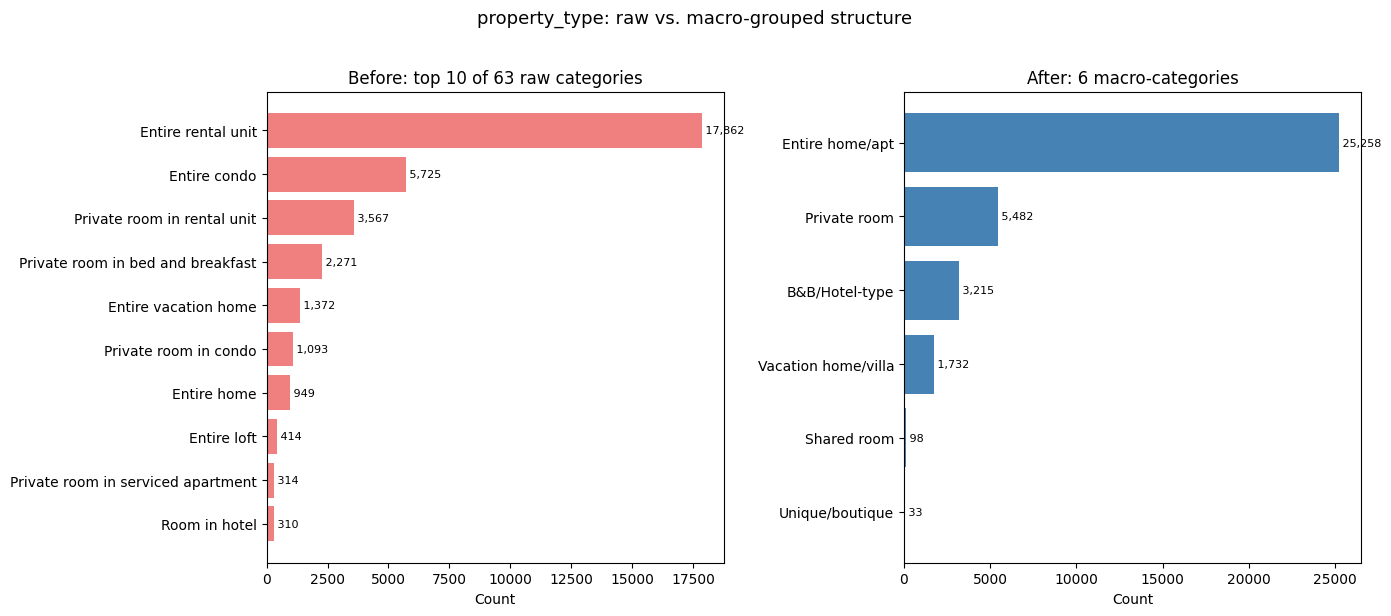

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# before: top 10 raw categories
top_raw = listings_clean['property_type'].value_counts().head(10)
axes[0].barh(top_raw.index[::-1], top_raw.values[::-1], color='lightcoral')
axes[0].set_title(f'Before: top 10 of {listings_clean["property_type"].nunique()} raw categories')
axes[0].set_xlabel('Count')

# after: 6 macro-groups
grouped_counts_sorted = grouped_counts.sort_values()
axes[1].barh(grouped_counts_sorted.index, grouped_counts_sorted.values, color='steelblue')
axes[1].set_title(f'After: {listings_clean["property_type_grouped"].nunique()} macro-categories')
axes[1].set_xlabel('Count')

for ax in axes:
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(v, i, f' {int(v):,}', va='center', fontsize=8)

plt.suptitle('property_type: raw vs. macro-grouped structure', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Shared room** and **Unique/boutique** are very small groups but are deliberately kept separate rather than folded into a larger category: `Shared room` reflects a materially different privacy tier from `Private room`, and `Unique/boutique` groups property styles that are conceptually distinct from standard residential stays.

- `neighbourhood_cleansed`

In [14]:
# inspect distribution
neighbourhood_counts = listings_clean['neighbourhood_cleansed'].value_counts()
neighbourhood_pct = listings_clean['neighbourhood_cleansed'].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({'count': neighbourhood_counts, 'pct': neighbourhood_pct}))

,count,pct
neighbourhood_cleansed,,
I Centro Storico,17537,49.0
VII San Giovanni/Cinecittà,3138,8.8
XIII Aurelia,2560,7.1
II Parioli/Nomentano,2473,6.9
XII Monte Verde,1934,5.4
V Prenestino/Centocelle,1836,5.1
VIII Appia Antica,1155,3.2
X Ostia/Acilia,1020,2.8
XIV Monte Mario,833,2.3


`neighbourhood_cleansed` consists of 15 administrative municipi, each already representing a specific, meaningful area of Rome rather than an arbitrary or overly granular label. The distribution is skewed, as `I Centro Storico` alone accounts for **49.0%** of listings, with the rest spread from 8.8% down to 0.9% across the remaining 14 categories, but since the categories themselves are specific and interpretable, no merging or grouping is applied at this stage and the variable is kept as-is. Whether it should ultimately serve as a clustering input, be replaced by a more granular geographic signal, or be reserved for profiling only is left for the upcoming EDA and feature selection stage, once the full candidate feature set can be compared directly.

### 3.2 Geographic Features

`latitude` and `longitude` are fully populated columns that can derive two useful features:
- `distance_to_center_km` — a continuous haversine distance from each listing to a fixed Rome reference point (Piazza Venezia)
- `geo_sector`, a coarse 8-direction compass sector from the same reference point, kept for interpretability during cluster profiling

In [15]:
# Rome reference point: Piazza Venezia (city center)
REFERENCE_LAT = 41.8955
REFERENCE_LON = 12.4823

def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r_earth_km = 6371
    return r_earth_km * c

listings_clean['distance_to_center_km'] = haversine_distance(
    listings_clean['latitude'], listings_clean['longitude'],
    REFERENCE_LAT, REFERENCE_LON
)

# 8-direction compass sector from the reference point
def compass_sector(lat, lon, ref_lat=REFERENCE_LAT, ref_lon=REFERENCE_LON):
    dlat = lat - ref_lat
    dlon = (lon - ref_lon) * np.cos(np.radians(ref_lat))
    angle = (np.degrees(np.arctan2(dlon, dlat)) + 360) % 360
    sectors = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    idx = int(((angle + 22.5) % 360) // 45)
    return sectors[idx]

listings_clean['geo_sector'] = listings_clean.apply(
    lambda row: compass_sector(row['latitude'], row['longitude']), axis=1
)

display(listings_clean[['latitude', 'longitude', 'distance_to_center_km', 'geo_sector']].describe(include='all'))

,latitude,longitude,distance_to_center_km,geo_sector
count,35818.000000,35818.000000,35818.000000,35818
unique,NaN,NaN,NaN,8
top,NaN,NaN,NaN,E
freq,NaN,NaN,NaN,7015
mean,41.891025,12.480493,3.846244,NaN
std,0.035305,0.049925,4.240249,NaN
min,41.655820,12.242530,0.072973,NaN
25%,41.882890,12.459109,1.556894,NaN
50%,41.896230,12.477656,2.679963,NaN
75%,41.906500,12.505698,4.262451,NaN


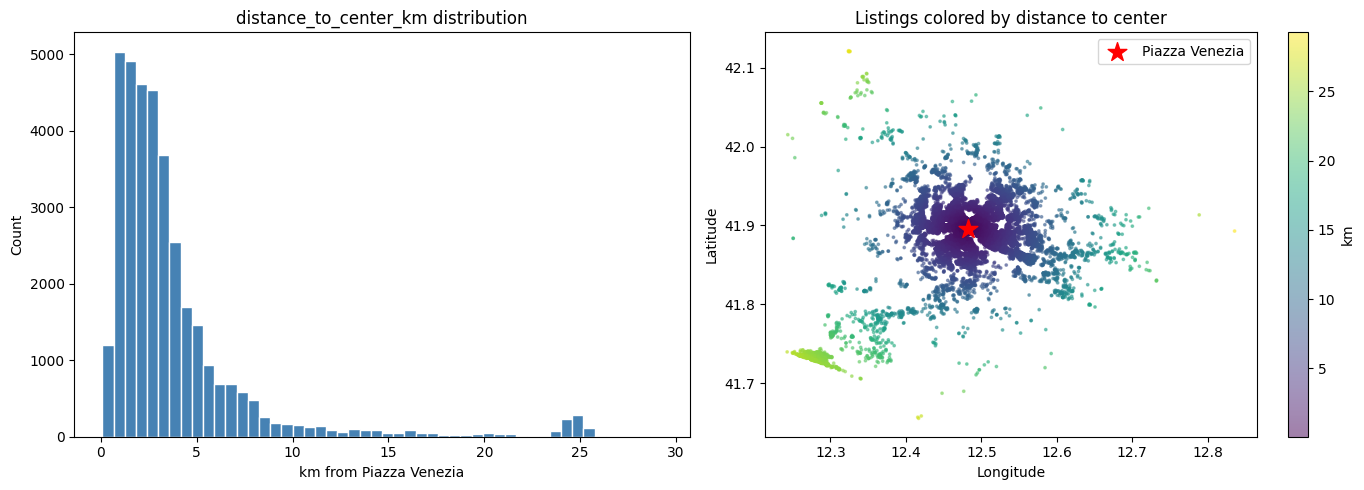

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of distance_to_center_km
axes[0].hist(listings_clean['distance_to_center_km'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('distance_to_center_km distribution')
axes[0].set_xlabel('km from Piazza Venezia')
axes[0].set_ylabel('Count')

# listings colored by distance, to visually sanity-check geography
scatter = axes[1].scatter(
    listings_clean['longitude'], listings_clean['latitude'],
    c=listings_clean['distance_to_center_km'], cmap='viridis', s=3, alpha=0.5
)
axes[1].scatter([REFERENCE_LON], [REFERENCE_LAT], color='red', marker='*', s=200, label='Piazza Venezia')
axes[1].set_title('Listings colored by distance to center')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend()
plt.colorbar(scatter, ax=axes[1], label='km')

plt.tight_layout()
plt.show()

Since `distance_to_center_km` alone only captures *how far* a listing is from the city center and not *in which direction*, `geo_sector`, a 8-direction compass bucket (N/NE/E/SE/S/SW/W/NW) computed from the same reference point, is added alongside it. Together, the two features behave like polar coordinates (radius + angle) rather than raw lat/lon, giving the clustering algorithm both a continuous distance signal and an interpretable directional one, without the granularity or imbalance issues of using coordinates or `neighbourhood_cleansed` directly.

### 3.3 Resolving Multicollinearity

#### 3.3.1 Correlation & VIF Check

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_centered(df, cols):
    """Computes VIF after mean-centering to avoid inflated values."""
    X = df[cols].dropna()
    X_centered = X - X.mean() 
    vif_data = pd.DataFrame({
        'variable': cols,
        'VIF': [variance_inflation_factor(X_centered.values, i) for i in range(len(cols))]
    })
    return vif_data, X_centered

- **Review-score block** - raw, continuous & complete-case only

Review-score block: VIF computed on 30,718 rows with reviews (85.8% of dataset)


,variable,VIF
0,review_scores_rating_raw,5.98
1,review_scores_accuracy_raw,3.79
2,review_scores_cleanliness_raw,2.69
3,review_scores_checkin_raw,2.37
4,review_scores_communication_raw,2.88
5,review_scores_location_raw,1.45
6,review_scores_value_raw,4.03


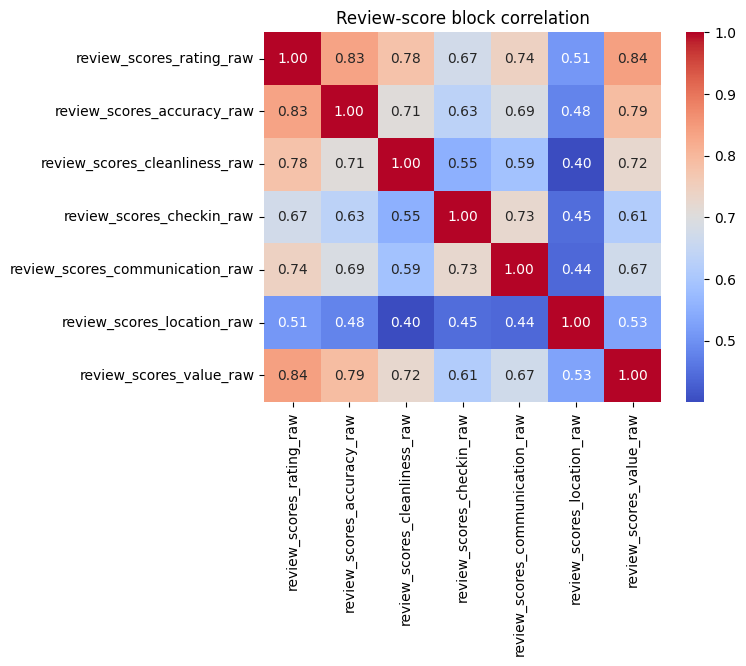

In [18]:
review_score_raw_cols = [
    'review_scores_rating_raw', 'review_scores_accuracy_raw', 'review_scores_cleanliness_raw',
    'review_scores_checkin_raw', 'review_scores_communication_raw', 'review_scores_location_raw',
    'review_scores_value_raw'
]

review_corr = listings_clean[review_score_raw_cols].corr()
review_vif, review_X = compute_vif_centered(listings_clean, review_score_raw_cols)

print(f"Review-score block: VIF computed on {len(review_X):,} rows with reviews "
      f"({len(review_X)/len(listings_clean)*100:.1f}% of dataset)")
display(review_vif.round(2))

# visualize correlations
sns.heatmap(review_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Review-score block correlation');

The correlation matrix confirms strong, systematic pairwise relationships across the entire block, with `review_scores_rating` correlating most strongly with every other variable, which is consistent with it functioning as Airbnb's own composite summary score. `review_scores_location` is the most independent variable in the block, reflecting that a listing's location is conceptually unrelated to its cleanliness or host responsiveness.

Centered VIF values are moderate rather than extreme: `review_scores_rating` and `review_scores_value` exceed the conventional VIF > 5 threshold for meaningful multicollinearity, while the remaining five variables fall between 1.45 and 3.79. No variable reaches the more severe VIF > 10 threshold. This is a more measured picture than the correlation matrix alone suggests. The block is meaningfully but not catastrophically collinear.

Given that seven variables measuring largely overlapping underlying signal would otherwise occupy a disproportionate share of the clustering feature space relative to other conceptual axes. **Dimensionality reduction for this block is still warranted**.

- **Host-portfolio block** - fully populated

Host-portfolio block: VIF computed on 35,818 rows


,variable,VIF
0,host_listings_count,23.09
1,host_total_listings_count,14.49
2,calculated_host_listings_count,4.78
3,host_verifications_count,2.30
4,host_experience_years,1.18
5,host_has_profile_pic,1.12
6,host_identity_verified,1.03
7,no_valid_license,1.03
8,host_verification_work_email,2.27


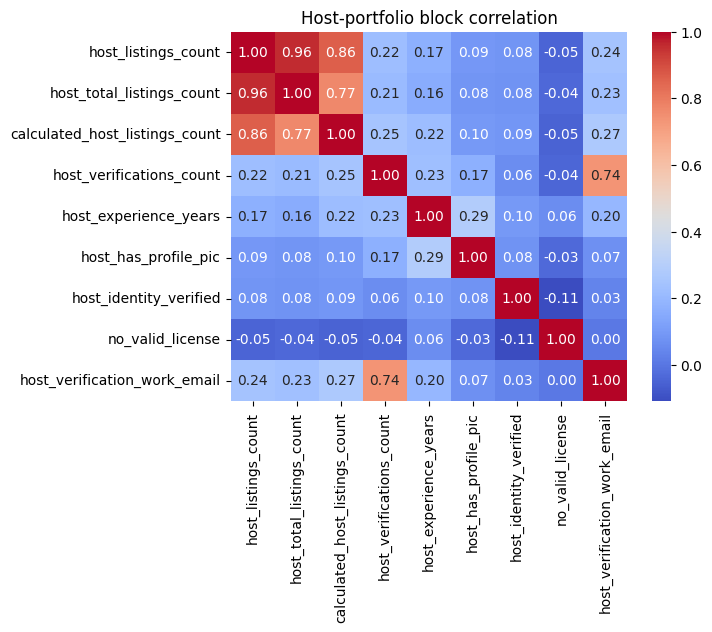

In [19]:
host_prof_cols = [
    'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count',
    'host_verifications_count', 'host_experience_years', 'host_has_profile_pic',
    'host_identity_verified', 'no_valid_license', 'host_verification_work_email'
]

host_corr = listings_clean[host_prof_cols].corr()
host_vif, host_X = compute_vif_centered(listings_clean, host_prof_cols)

print(f"Host-portfolio block: VIF computed on {len(host_X):,} rows")
display(host_vif.round(2))

# visualize correlations
sns.heatmap(host_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Host-portfolio block correlation');

Unlike the review-score block, the host-portfolio block does not behave as a single homogeneous cluster. Two distinct sub-groups emerge:

- **Listings-count trio** (`host_listings_count`, `host_total_listings_count`, `calculated_host_listings_count`): severe multicollinearity, with VIF of 23.09, 14.49, and 4.78 respectively, and pairwise correlations of 0.77–0.96. All three measure essentially the same underlying quantity, a host's portfolio size, via different counting methodologies.
- **Verification/establishment variables** (`host_experience_years`, `host_has_profile_pic`, `host_identity_verified`, `no_valid_license`): VIF of 1.03–1.18, with negligible pairwise correlations (0.03–0.29). These are effectively independent and each capture a distinct dimension of host trustworthiness.
- **`host_verifications_count` and `host_verification_work_email`** correlate moderately with each other (r = 0.74, VIF ≈ 2.3) but not with the rest of the block, and are kept separate rather than folded in with either group.

#### 3.3.2 Dimensionality Reduction

- **Review-score block : PCA** 

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# complete-case subset
review_X = listings_clean[review_score_raw_cols].dropna()

scaler = StandardScaler()
review_X_scaled = scaler.fit_transform(review_X)

pca = PCA()
pca.fit(review_X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

pca_summary = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(explained_var))],
    'explained_variance_%': (explained_var * 100).round(2),
    'cumulative_%': (cumulative_var * 100).round(2)
})
display(pca_summary)

,component,explained_variance_%,cumulative_%
0,PC1,69.66,69.66
1,PC2,9.60,79.26
2,PC3,7.95,87.20
3,PC4,4.36,91.56
4,PC5,3.66,95.22
5,PC6,2.90,98.12
6,PC7,1.88,100.00


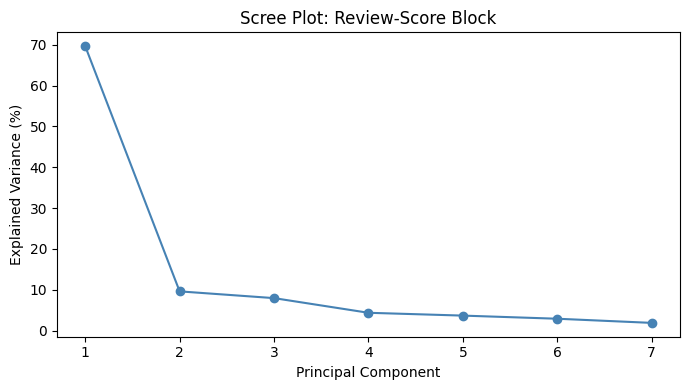

In [21]:
# scree plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(explained_var) + 1), explained_var * 100, marker='o', color='steelblue')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot: Review-Score Block')
ax.set_xticks(range(1, len(explained_var) + 1))
plt.tight_layout()
plt.show()

In [22]:
# how much each raw variable contributes to the first component
pc1_loadings = pd.DataFrame({
    'variable': review_score_raw_cols,
    'PC1_loading': pca.components_[0]
}).sort_values('PC1_loading', key=abs, ascending=False)

display(pc1_loadings.round(3))

,variable,PC1_loading
0,review_scores_rating_raw,0.423
6,review_scores_value_raw,0.406
1,review_scores_accuracy_raw,0.403
4,review_scores_communication_raw,0.380
2,review_scores_cleanliness_raw,0.373
3,review_scores_checkin_raw,0.361
5,review_scores_location_raw,0.284


PC1 explains **69.66%** of the variance in the review-score block on its own, with a sharp drop to PC2 (9.60%), a clear "elbow" in the scree plot indicating one dominant underlying dimension rather than several distinct ones. All seven loadings on PC1 are positive and of similar magnitude, confirming PC1 functions as a general review-quality index rather than being driven by any single variable: `review_scores_rating` (0.423), `review_scores_value` (0.406), and `review_scores_accuracy` (0.403) contribute the most, while `review_scores_location` contributes the least (0.284).

In [23]:
# apply PCA to the full dataset
review_full = listings_clean[review_score_raw_cols]
has_all_scores = review_full.notna().all(axis=1)

review_pc1 = pd.Series(index=listings_clean.index, dtype=float)
review_pc1[has_all_scores] = pca.transform(
    scaler.transform(review_full.loc[has_all_scores])
)[:, 0]

listings_clean['review_quality_pc1'] = review_pc1

print(f"review_quality_pc1: {listings_clean['review_quality_pc1'].isna().sum()} missing "
      f"({listings_clean['review_quality_pc1'].isna().mean()*100:.1f}%)")

review_quality_pc1: 5100 missing (14.2%)


In [24]:
# review_quality_pc1 → categorical bins

# quantile-based split on the observed PC1 scores, since PC1 doesn't have the natural [1,5] ceiling that motivated fixed thresholds
# for the raw review scores in the Missing Values Handling section
pc1_observed = listings_clean['review_quality_pc1'].dropna()
pc1_median = pc1_observed.median()

def bin_binary_threshold_numeric(df, column, threshold, labels=('Below Average', 'Above Average')):
    binned = np.where(df[column] < threshold, labels[0], labels[1])
    binned = pd.Series(binned, index=df.index).where(df[column].notna(), "Unknown")
    return pd.Categorical(binned, categories=list(labels) + ["Unknown"], ordered=False)

listings_clean['review_quality_pc1_binned'] = bin_binary_threshold_numeric(
    listings_clean, 'review_quality_pc1', pc1_median
)

display(listings_clean['review_quality_pc1_binned'].value_counts(normalize=True).mul(100).round(1))

review_quality_pc1_binned
Below Average    42.9
Above Average    42.9
Unknown          14.2
Name: proportion, dtype: float64

Given that PC1 alone captures the majority of the block's variance, the seven raw review-score variables are replaced by a single composite, `review_quality_pc1`, for the feature set. As with the raw variables, the composite is only defined for listings with at least one review and inherits the same 14.2% MNAR missingness, reconciled the same way as the rest of the review block, via categorical binning with an explicit `"Unknown"` category rather than imputation.

- **Host-portfolio block : host listings count trio**

In [25]:
listings_count_dropped = ['host_listings_count', 'host_total_listings_count']

listings_clean = listings_clean.drop(columns=listings_count_dropped)

Since only the listings-count trio shows structural redundancy, there is no need for a PCA composite here. Instead, a single representative variable is selected directly, and the other two are dropped from the clustering feature set entirely: `calculated_host_listings_count` is retained, as it has the lowest VIF of the three (4.78 vs. 14.49/23.09) and is the only one of the three with a transparent, documented calculation: the number of listings a host has in the current scrape, within the local city/region geography.

### 3.4 Domain-Driven Derived Features

- **Space-efficiency ratios**

In [26]:
listings_clean['beds_per_bedroom'] = (
    listings_clean['beds'] / listings_clean['bedrooms_raw'].replace(0, np.nan)
)

listings_clean['accommodates_per_bedroom'] = (
    listings_clean['accommodates'] / listings_clean['bedrooms_raw'].replace(0, np.nan)
)

listings_clean['bathroom_per_bedroom'] = (
    listings_clean['bathroom_count'] / listings_clean['bedrooms_raw'].replace(0, np.nan)
)

display(listings_clean[['beds_per_bedroom', 'accommodates_per_bedroom', 'bathroom_per_bedroom']].describe())

,beds_per_bedroom,accommodates_per_bedroom,bathroom_per_bedroom
count,34494.000000,34494.000000,34494.000000
mean,1.498084,2.682259,0.934629
std,0.662415,0.936896,0.300409
min,0.000000,0.250000,0.000000
25%,1.000000,2.000000,1.000000
50%,1.333333,2.333333,1.000000
75%,2.000000,3.000000,1.000000
max,7.000000,9.000000,4.000000


These ratios inherit missingness from `bedrooms_raw`, calling for the same binning discipline applied during the Missing Values handling section: categorical versions alongside the continuous ratios, with explicit `Studio` and `Unknown` categories rather than dropping or imputing these rows.

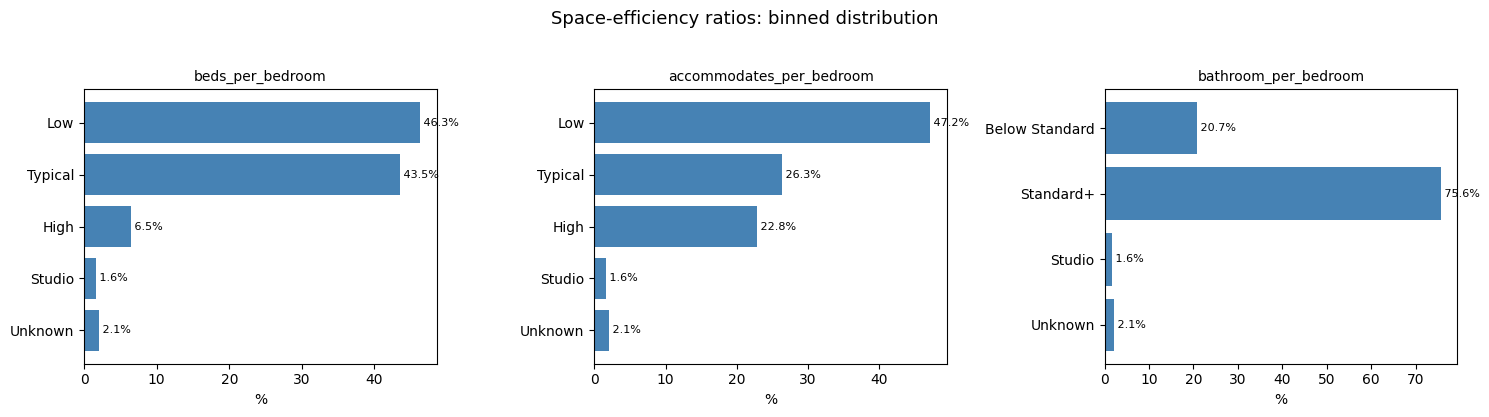

In [27]:
def bin_ratio_with_studio(df, ratio_col, bedroom_col, n_bins=3, labels=None):
    """
    Bins a per-bedroom ratio into quantile categories, with dedicated
    'Studio' (bedroom_col == 0) and 'Unknown' (bedroom_col is NaN) categories
    handled separately from the quantile split on genuine multi-bedroom listings.
    """
    is_studio = df[bedroom_col] == 0
    is_missing = df[bedroom_col].isna()
    valid_mask = ~is_studio & ~is_missing
    observed = df.loc[valid_mask, ratio_col]
    quantile_edges = np.unique(observed.quantile(np.linspace(0, 1, n_bins + 1)).values)
    actual_n_bins = len(quantile_edges) - 1
    bin_labels = labels if (labels and len(labels) == actual_n_bins) else [f"Q{i+1}" for i in range(actual_n_bins)]
    binned = pd.cut(df[ratio_col], bins=quantile_edges, labels=bin_labels, include_lowest=True).astype(object)
    binned = binned.where(valid_mask, np.where(is_studio, "Studio", "Unknown"))
    return pd.Categorical(binned, categories=bin_labels + ["Studio", "Unknown"], ordered=False)


def bin_ratio_ceiling(df, ratio_col, bedroom_col, ceiling=1.0, labels=('Below Standard', 'Standard+')):
    """
    Binary ceiling split for ratios with a heavy point mass at a natural
    'standard' value, where quantile binning collapses due to tied values —
    same logic as host_acceptance_rate / host_response_rate in Section 7.
    """
    is_studio = df[bedroom_col] == 0
    is_missing = df[bedroom_col].isna()
    valid_mask = ~is_studio & ~is_missing
    binned = np.where(df[ratio_col] < ceiling, labels[0], labels[1])
    binned = pd.Series(binned, index=df.index).astype(object)
    binned = binned.where(valid_mask, np.where(is_studio, "Studio", "Unknown"))
    return pd.Categorical(binned, categories=list(labels) + ["Studio", "Unknown"], ordered=False)


listings_clean['beds_per_bedroom_binned'] = bin_ratio_with_studio(
    listings_clean, 'beds_per_bedroom', 'bedrooms_raw', n_bins=3,
    labels=['Low', 'Typical', 'High']
)
listings_clean['accommodates_per_bedroom_binned'] = bin_ratio_with_studio(
    listings_clean, 'accommodates_per_bedroom', 'bedrooms_raw', n_bins=3,
    labels=['Low', 'Typical', 'High']
)
listings_clean['bathroom_per_bedroom_binned'] = bin_ratio_ceiling(
    listings_clean, 'bathroom_per_bedroom', 'bedrooms_raw', ceiling=1.0,
    labels=('Below Standard', 'Standard+')
)

# visualize resulting distributions 
binned_cols = ['beds_per_bedroom_binned', 'accommodates_per_bedroom_binned', 'bathroom_per_bedroom_binned']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, binned_cols):
    pct = listings_clean[col].value_counts(normalize=True).mul(100).round(1)
    pct = pct.reindex(listings_clean[col].cat.categories)
    ax.barh(pct.index[::-1], pct.values[::-1], color='steelblue')
    ax.set_title(col.replace('_binned', ''), fontsize=10)
    ax.set_xlabel('%')
    for i, v in enumerate(pct.values[::-1]):
        ax.text(v, i, f' {v}%', va='center', fontsize=8)

plt.suptitle('Space-efficiency ratios: binned distribution', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

All three ratios show meaningful right-skew, but differ in shape: `beds_per_bedroom` and `accommodates_per_bedroom` have a genuine continuous spread and are split into quantile-based tertiles (Low/Typical/High); `bathroom_per_bedroom` has its median, 25th, and 75th percentiles all tied at exactly 1.0, so quantile binning would collapse, so a ceiling split at 1.0 (Below Standard/Standard+) is used instead.

- **Booking policy signal**

,is_long_term_oriented
count,35818.000000
mean,0.093584
std,0.291253
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


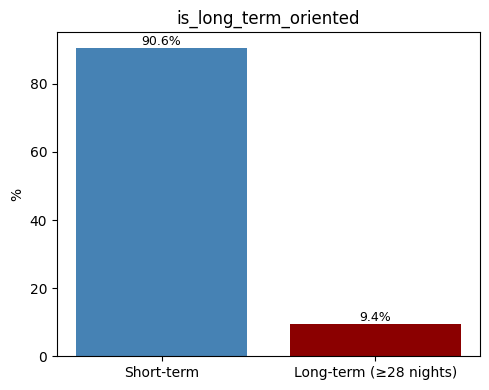

In [28]:
listings_clean['is_long_term_oriented'] = (listings_clean['minimum_nights'] >= 28).astype(int)

display(listings_clean[['is_long_term_oriented']].describe())

# bar chart: is_long_term_oriented proportions
fig, ax = plt.subplots(figsize=(5, 4))

pct = listings_clean['is_long_term_oriented'].value_counts(normalize=True).mul(100).round(1)
pct = pct.reindex([0, 1])
ax.bar(['Short-term', 'Long-term (≥28 nights)'], pct.values, color=['steelblue', 'darkred'])
ax.set_title('is_long_term_oriented')
ax.set_ylabel('%')
for i, v in enumerate(pct.values):
    ax.text(i, v, f'{v}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

`is_long_term_oriented` flags listings with `minimum_nights ≥ 28`, turning the 31-night regulatory ceiling identified during outlier diagnosis into an explicit categorical signal: 9.4% of listings are long-term-oriented, distinct from the typical short-term tourist rental.

- **Availability ratios**

Correlation between availability_ratio (90d) and availability_365_ratio: 0.558


,availability_ratio,availability_365_ratio
count,35818.000000,35818.000000
mean,0.519360,0.595583
std,0.283090,0.317626
min,0.000000,0.000000
25%,0.344444,0.328767
50%,0.555556,0.687671
75%,0.711111,0.873973
max,1.000000,1.000000


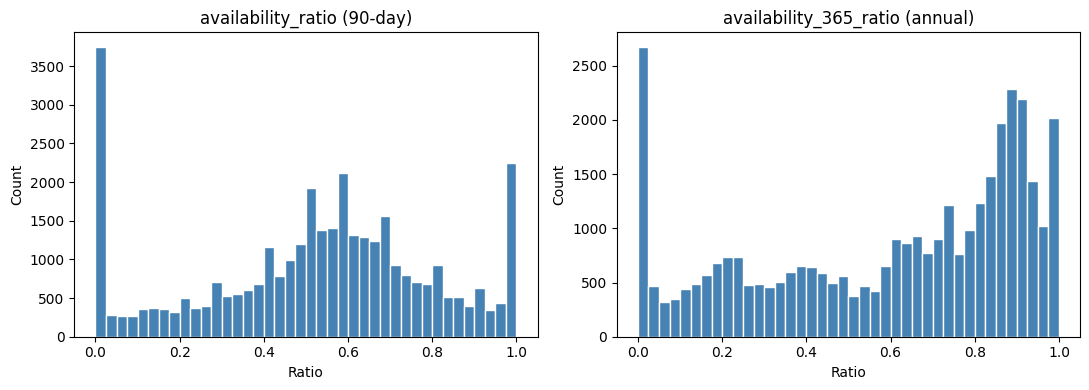

In [29]:
listings_clean['availability_ratio'] = listings_clean['availability_90'] / 90
listings_clean['availability_365_ratio'] = listings_clean['availability_365'] / 365

corr = listings_clean[['availability_ratio', 'availability_365_ratio']].corr().iloc[0, 1]
print(f"Correlation between availability_ratio (90d) and availability_365_ratio: {corr:.3f}")

display(listings_clean[['availability_ratio', 'availability_365_ratio']].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(listings_clean['availability_ratio'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('availability_ratio (90-day)')
axes[0].set_xlabel('Ratio')
axes[0].set_ylabel('Count')

axes[1].hist(listings_clean['availability_365_ratio'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('availability_365_ratio (annual)')
axes[1].set_xlabel('Ratio')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

`availability_90` and `availability_365` record how many of the next 90 and 365 days, respectively, are open on a listing's calendar as of the scrape date (a day counts as unavailable whether it was booked by a guest or simply blocked by the host), so the ratio reflects calendar openness rather than confirmed demand alone. Dividing each by its window length gives `availability_ratio` (`availability_90 / 90`) and `availability_365_ratio` (`availability_365 / 365`). The two horizons correlate moderately (r = 0.558), confirming each captures partially distinct signal about near-term versus longer-term booking pressure, so both are retained.

- **Review engagement score**

count    3.581800e+04
mean     3.808817e-17
std      7.994299e-01
min     -1.288706e+00
25%     -3.948619e-01
50%     -5.722293e-02
75%      4.591306e-01
max      2.772791e+00
Name: review_engagement_score, dtype: float64

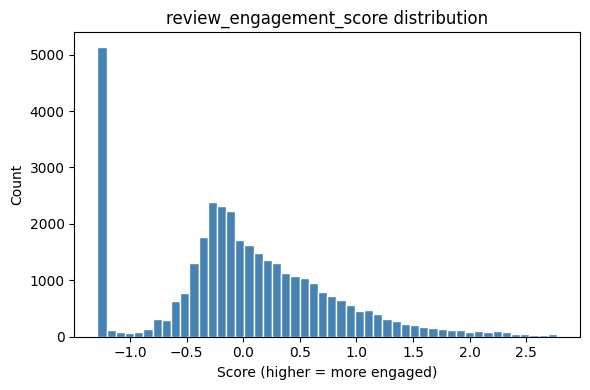

In [30]:
# fill reviews_per_month with 0 
reviews_per_month_filled = listings_clean['reviews_per_month_raw'].fillna(0)

# make last_review_recency as proxy for "never reviewed" as one unit beyond the observed maximum
max_recency = listings_clean['last_review_recency_raw'].max()
last_review_recency_filled = listings_clean['last_review_recency_raw'].fillna(max_recency + 1)

number_of_reviews_filled = listings_clean['number_of_reviews']

engagement_components = pd.DataFrame({
    'reviews_per_month_z': (reviews_per_month_filled - reviews_per_month_filled.mean()) / reviews_per_month_filled.std(),
    'number_of_reviews_z': (number_of_reviews_filled - number_of_reviews_filled.mean()) / number_of_reviews_filled.std(),
    # lower recency (more recent) = higher engagement
    'recency_z': -1 * (last_review_recency_filled - last_review_recency_filled.mean()) / last_review_recency_filled.std()
})

listings_clean['review_engagement_score'] = engagement_components.mean(axis=1)

display(listings_clean['review_engagement_score'].describe())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(listings_clean['review_engagement_score'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('review_engagement_score distribution')
ax.set_xlabel('Score (higher = more engaged)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

`review_engagement_score` aggregates listing-level activity from `reviews_per_month_raw`, `last_review_recency_raw`, and `number_of_reviews`.

Missingness here is not a genuine unknown, as for listings with zero reviews, `number_of_reviews` is already observed as 0, and the natural interpretation of the other two variables is a substantive floor rather than an unresolvable gap. `reviews_per_month` is filled with 0 (zero reviews per month is what "no reviews" means), and `last_review_recency` is filled with a value one unit beyond the observed maximum.

Each variable is standardized using Z-score rather than combined via PCA, since these three measure distinct aspects of activity (frequency, recency, volume) in different units. `last_review_recency` is sign-flipped after standardization so that higher values consistently mean higher engagement across all three components, and the final score is their row-wise mean.

The resulting distribution shows exactly the expected structure: a distinct spike near the minimum (~14.2% of listings with no reviews) where all three components are forced to their floor values, followed by a continuous, moderately right-skewed spread among listings with genuine review activity. This partial overlap with `has_reviews` is expected rather than problematic, so both variables are retained as candidates, with any redundancy resolved at the feature selection stage.

### 3.5 Skew Handling

In [31]:
# check skewness on all numeric columns
from scipy.stats import skew

id_cols = ['id', 'host_id']
numeric_cols_all = [
    col for col in listings_clean.select_dtypes(include=[np.number]).columns
    if col not in id_cols
]

skew_summary = pd.DataFrame({
    'skewness': [skew(listings_clean[col].dropna()) for col in numeric_cols_all]
}, index=numeric_cols_all).sort_values('skewness', key=abs, ascending=False)

display(skew_summary.round(2))

,skewness
review_scores_checkin_raw,-6.47
has_gym,6.41
review_scores_communication_raw,-6.34
has_bbq,6.21
host_response_rate_raw,-5.72
has_hot_tub,5.72
has_fireplace,5.68
review_scores_accuracy_raw,-5.39
review_quality_pc1,-5.34
has_outdoor_leisure,4.97


Skewness is checked across all numeric columns in the dataframe. Binary 0/1 flags, review scores already superseded by `review_quality_pc1`/  `review_engagement_score`, `latitude`/`longitude`, and `bedrooms_raw` are not considered here, since skewness either isn't meaningful for them or they are no longer clustering candidates in their raw form. `price` is not considered here for the same reason it stays out of the feature set entirely, as it is reserved for post-hoc validation.

Among the remaining continuous candidates, variables with |skewness| > 1 are log-transformed: `calculated_host_listings_count` (3.95), `distance_to_center_km` (3.24), `number_of_reviews` (2.47), `median_review_length` (1.36), `beds_per_bedroom` (1.33), `bathroom_per_bedroom` (1.30), and `beds` (1.10).

Two candidates above this threshold are left untransformed:
- **`minimum_nights`** (skew 2.72) stays out of the log-transform list. Its skew stems directly from the 31-night regulatory ceiling identified at the Outliers Handling stage, and the meaningful signal it carries, whether a listing is long-term-oriented, is already captured by the `is_long_term_oriented` flag, making a transformed continuous version redundant alongside it.
- **`bathroom_count`** (skew 1.88) is left as-is despite exceeding the threshold, since it behaves more like a low-cardinality discrete variable than a genuine continuous distribution, so log-transforming a near-categorical variable would add noise rather than normalize meaningful spread.

In [32]:
log_transform_cols = [
    'calculated_host_listings_count', 'distance_to_center_km', 'number_of_reviews',
    'median_review_length', 'beds_per_bedroom', 'bathroom_per_bedroom', 'beds'
]

for col in log_transform_cols:
    listings_clean[f'{col}_log'] = np.log1p(listings_clean[col])

skew_after = pd.DataFrame({
    'skew_before': [skew(listings_clean[col].dropna()) for col in log_transform_cols],
    'skew_after': [skew(listings_clean[f'{col}_log'].dropna()) for col in log_transform_cols]
}, index=log_transform_cols)

display(skew_after.round(2))

,skew_before,skew_after
calculated_host_listings_count,3.95,1.31
distance_to_center_km,3.24,0.94
number_of_reviews,2.47,-0.10
median_review_length,1.36,-1.81
beds_per_bedroom,1.33,0.12
bathroom_per_bedroom,1.30,-0.17
beds,1.10,0.12


In [33]:
listings_clean = listings_clean.drop(columns=['median_review_length_log'])

The log-transform worked as intended for most variables (`number_of_reviews`, `beds_per_bedroom`, `bathroom_per_bedroom`, `beds` all move close to 0), and meaningfully reduced skew for `calculated_host_listings_count` (3.95→1.31) and `distance_to_center_km` (3.24→0.94), even though the former remains above the |1| threshold given its originally extreme, long-tailed distribution.

`median_review_length` is the one exception: log-transforming it *increased* skewness in magnitude (1.36→-1.81), flipping its direction, indicating the variable's shape doesn't fit a log-transform's assumption of a long right tail. The log-transformed version is discarded, and the raw `median_review_length` is retained instead.

### 3.6 Feature Engineering Conclusion

This section transformed `listings_clean` into a broad candidate feature set for clustering, working through four stages:

- **High-cardinality categoricals**: `property_type` reduced from 63 raw labels to 6 interpretable macro-groups via pattern-based rules; `neighbourhood_cleansed` kept as-is, with its inclusion as a clustering input vs. profiling-only deferred to feature selection.
- **Geographic features**: `distance_to_center_km` and `geo_sector` derived from `latitude`/`longitude`, giving a continuous, high-resolution location signal that avoids the imbalance of a 15-category one-hot.
- **Multicollinearity**: VIF and correlation checks confirmed both blocks flagged at the Data Profiling stage. The review-score block was collapsed into a single PCA composite, `review_quality_pc1` (69.66% variance explained), binned alongside it. The host-listings-count trio was resolved by keeping `calculated_host_listings_count` (lowest VIF, transparent methodology) and dropping the other two; the verification/establishment variables were confirmed independent and left untouched.
- **Domain-driven features**: space-efficiency ratios (`beds_per_bedroom`, `accommodates_per_bedroom`, `bathroom_per_bedroom`), a booking-policy flag (`is_long_term_oriented`), two availability ratios (90-day and annual), and a listing-activity composite (`review_engagement_score`), each engineered feature paired with a categorical/binned version where relevant, following the same missingness-preserving discipline established during data cleaning (explicit `Unknown`/`Studio` categories rather than imputation). `night_range` and `premium_amenities_count` were considered and dropped after inspection.
- **Skew & log-transform**: skewness checked across all numeric columns; seven variables with |skew| > 1 log-transformed, with `minimum_nights` (redundant with `is_long_term_oriented`), `bathroom_count` (near-categorical), and `median_review_length` (log-transform worsened its skew) deliberately left untransformed.

The resulting `listings_extended.csv` carries both raw/binned and continuous/log-transformed versions of most engineered variables and no redundancy is resolved here, by design as that decision belongs to the feature selection stage

## 4. NLP Feature Engineering — Part 1: Lexical & Stylistic Signals

This section extends the candidate feature set with signals derived from listing text (`description_cleaned`, `host_about_cleaned`, `neighborhood_overview_cleaned`) and guest reviews (`reviews_clean`), to test whether text adds structure to market segmentation beyond the tabular features already engineered. As with the tabular stage, `price` stays fully outside feature construction and selection.

This section covers the lighter, rule-based methods only, such as text preparation, stylometry, and domain lexicons, all of which run on the full corpus. Heavier, model-based methods (sentiment, topic modeling, embeddings) continue in a separate notebook. Validation, transformation, and feature selection across the complete NLP feature set happens at the end of that later notebook.

### 4.1 Review Volume & Capping Strategy

In [34]:
print(reviews_clean.shape)
print(reviews_clean['listing_id'].nunique())

(2193159, 5)
32255


In [35]:
reviews_per_listing = reviews_clean.groupby('listing_id').size()

print(reviews_per_listing.describe())
print()
for n in [5, 10, 15, 20, 30, 50]:
    total_if_capped = reviews_per_listing.clip(upper=n).sum()
    print(f"Cap at {n}: total reviews to process = {total_if_capped:,} "
          f"({total_if_capped/len(reviews_clean)*100:.1f}% of full corpus)")

count    32255.000000
mean        67.994388
std        103.356786
min          1.000000
25%          7.000000
50%         27.000000
75%         84.000000
max       2817.000000
dtype: float64

Cap at 5: total reviews to process = 143,885 (6.6% of full corpus)
Cap at 10: total reviews to process = 263,179 (12.0% of full corpus)
Cap at 15: total reviews to process = 368,924 (16.8% of full corpus)
Cap at 20: total reviews to process = 464,453 (21.2% of full corpus)
Cap at 30: total reviews to process = 631,725 (28.8% of full corpus)
Cap at 50: total reviews to process = 898,591 (41.0% of full corpus)


The review corpus is large (2.19M rows across 32,255 listings) and heavily right-skewed, with only a small number of "hyper-popular" listings accounting for a disproportionate share of all reviews (max 2,817 reviews for a single listing, vs. a median of 27). Running transformer-based models (sentiment, embeddings) on the full corpus would be computationally infeasible on CPU/MPS within a reasonable timeframe, so a per-listing cap will be applied later, once the pipeline reaches those heavier phases: **no more than 30 reviews per listing will be sampled for downstream NLP processing, reused consistently across all review-level phases (sentiment, topic modeling, embeddings) rather than re-sampled independently in each.** Lighter, rule-based phases do not require this and will run on the full corpus.

A cap of 30 was chosen as a balance point. It would require processing only ~29% of the full corpus, while still providing a large enough sample per listing for statistically stable aggregates (mean/std sentiment, pooled embeddings), and would leave the majority of individual listings (75th percentile = 84 reviews) only partially capped rather than severely truncated.

### 4.2 Missingness Flags & Language Detection

Missing-text flags are built directly from the `_cleaned` columns (`== "unknown"` indicates the original field was empty or pure junk, per `clean_text_light`'s behavior), since the pre-replacement raw text columns were already dropped during data cleaning. Language is then detected for each listing text field and each review using fastText's lid.176 model. This model is small and fast, so it can run on the entire corpus without any capping. Knowing the language of each text is needed for several later steps, including readability scoring, sentiment analysis, and multilingual embeddings.

- **Missing-Text flags**

In [36]:
text_fields = {
    'name_cleaned': 'has_name',
    'description_cleaned': 'has_description',
    'neighborhood_overview_cleaned': 'has_neighborhood_overview',
    'host_about_cleaned': 'has_host_about'
}

for col, flag_name in text_fields.items():
    listings_clean[flag_name] = (listings_clean[col] != 'unknown').astype(int)

reviews_clean['is_substantive_review'] = (reviews_clean['comments_clean'] != 'unknown').astype(int)

display(listings_clean[list(text_fields.values())].mean().mul(100).round(1))
print(f"\nSubstantive reviews: {reviews_clean['is_substantive_review'].mean()*100:.1f}%")

has_name                     100.0
has_description               97.5
has_neighborhood_overview     46.5
has_host_about                45.0
dtype: float64


Substantive reviews: 99.8%


**Observations:**

1. `has_name` and `has_description` are near-universal (100.0% and 97.5%), consistent with these being core fields Airbnb effectively requires to publish a listing.

2. `has_neighborhood_overview` and `has_host_about` are both around 45–46%, meaning slightly more than half of hosts leave these optional fields blank.

3. `is_substantive_review` confirms the review corpus is almost entirely genuine content (99.8%), with only a negligible share of junk placeholders.

- **Language Detection**

In [37]:
# workaround: fasttext incompatible with numpy 2.0 copy semantics
_original_np_array = np.array
def _np_array_compat(*args, **kwargs):
    if kwargs.get('copy', 'unset') is False:
        kwargs['copy'] = None
    return _original_np_array(*args, **kwargs)
np.array = _np_array_compat

In [38]:
import fasttext
import urllib.request
import os

model_path = BASE_PATH / 'models' / 'lid.176.bin'
if not os.path.exists(model_path):
    urllib.request.urlretrieve(
        'https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin',
        model_path
    )

lang_model = fasttext.load_model(str(model_path))

MIN_WORDS_FOR_LANG_DETECT = 5

def detect_language(text):
    if pd.isna(text) or text == 'unknown' or str(text).strip() == '':
        return 'unknown'
    text = str(text).replace('\n', ' ').strip()
    if len(text.split()) < MIN_WORDS_FOR_LANG_DETECT:
        return 'too_short'
    pred = lang_model.predict(text, k=1)
    return pred[0][0].replace('__label__', '')

# listing-level text fields
listings_clean['description_lang'] = listings_clean['description_cleaned'].apply(detect_language)
listings_clean['host_about_lang'] = listings_clean['host_about_cleaned'].apply(detect_language)
listings_clean['neighborhood_overview_lang'] = listings_clean['neighborhood_overview_cleaned'].apply(detect_language)

# review-level (full corpus)
reviews_clean['review_lang'] = reviews_clean['comments_clean'].apply(detect_language)

# combined summary table: top languages across all text fields
lang_cols = {
    'description_lang': listings_clean['description_lang'],
    'host_about_lang': listings_clean['host_about_lang'],
    'neighborhood_overview_lang': listings_clean['neighborhood_overview_lang'],
    'review_lang': reviews_clean['review_lang']
}

lang_summary = pd.DataFrame({
    name: series.value_counts(normalize=True).mul(100).round(1)
    for name, series in lang_cols.items()
})

lang_summary = lang_summary.sort_values('review_lang', ascending=False)

display(lang_summary)

,description_lang,host_about_lang,neighborhood_overview_lang,review_lang
en,97.0,14.8,45.6,58.6
fr,0.0,0.1,0.0,8.6
it,0.3,27.4,0.2,8.5
es,0.0,0.2,0.0,8.4
too_short,0.2,2.2,0.6,5.9
...,...,...,...,...
mk,NaN,NaN,NaN,0.0
mn,NaN,NaN,NaN,0.0
mt,NaN,NaN,NaN,0.0
et,NaN,NaN,NaN,0.0


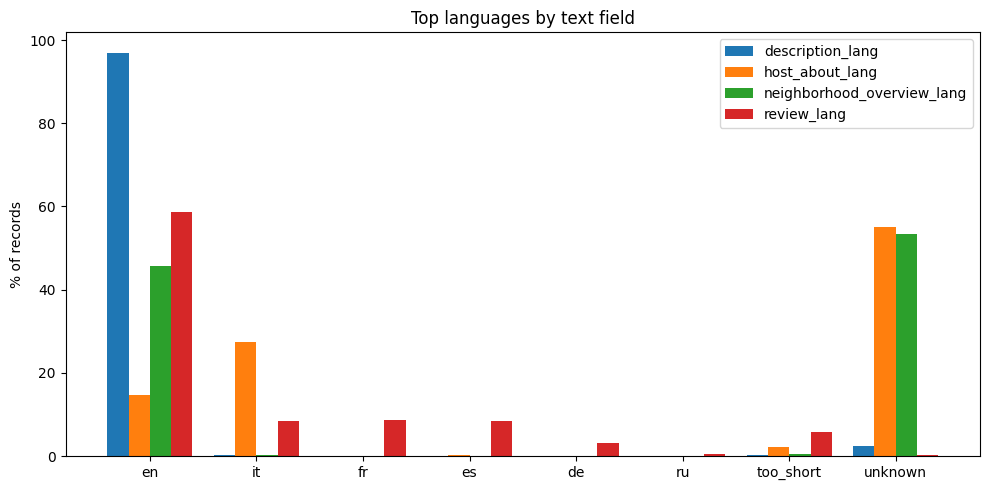

In [39]:
top_langs = ['en', 'it', 'fr', 'es', 'de', 'ru', 'too_short', 'unknown']

lang_chart_data = lang_summary.reindex(top_langs).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(top_langs))
width = 0.2

for i, col in enumerate(lang_cols.keys()):
    ax.bar(x + i * width, lang_chart_data[col], width, label=col)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top_langs)
ax.set_ylabel('% of records')
ax.set_title('Top languages by text field')
ax.legend()

plt.tight_layout()
plt.show()

**Observations:**

- `description` is overwhelmingly English (97.0%), while `host_about` skews the opposite way. Italian (27.4%) outpaces English (14.8%). This makes sense given what each field is for: hosts write the listing description in English to attract international tourists, but tend to write "about me" in their own language, since it might be less directly tied to booking conversion.

- `neighborhood_overview` sits in between (45.6% English), consistent with it being a semi-optional field that isn't always filled in the same register as the description.

- `review_lang` shows by far the widest spread: English still leads (58.6%), but French, Italian, and Spanish each contribute a meaningful share (8.6%, 8.5%, 8.4%), with dozens of other languages making up a long tail. This confirms Rome's guest base is genuinely international, and supports using multilingual embeddings rather than translating everything to English in later phases.

- `too_short` (texts under 5 words, where language detection is unreliable) accounts for a small but non-trivial share across fields. Most notably 5.9% of reviews and 2.2% of `host_about` entries, confirming that a meaningful number of short texts exist that would otherwise have been misclassified into a specific language rather than flagged as unreliable.

### 4.3 Stylometric Features

In this section surface-level stylometric signals will be computed (length, punctuation patterns, emoji usage, readability, vocabulary richness, and personalization markers) across all text fields, capturing how listings and reviews are written before moving to phases that analyze what they say (sentiment, topic modeling, embeddings).

#### 4.3.1 Length & Punctuation

Text length (characters, words), sentence count, punctuation density and exclamation/question mark counts are computed per listing text field (`description`, `host_about`, `neighborhood_overview`) and aggregated per listing for reviews. These are rule-based signals that don't require any model.

In [40]:
_SENTENCE_SPLIT_RE = re.compile(r'[.!?]+(?:\s|$)')
_PUNCT_RE = re.compile(r'[.,;:!?\-]')

def text_stats(text):
    if pd.isna(text) or text == 'unknown':
        return (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    text = str(text)
    word_count = len(text.split())
    char_count = len(text)

    sentence_count = len([s for s in _SENTENCE_SPLIT_RE.split(text) if s.strip()])
    punct_count = len(_PUNCT_RE.findall(text))
    punct_density = round(punct_count / char_count, 4) if char_count > 0 else 0

    exclaim_count = text.count('!')
    question_count = text.count('?')

    return (char_count, word_count, sentence_count, punct_density, exclaim_count, question_count)

In [41]:
# listing text fields
cols = ['char_count', 'word_count', 'sentence_count', 'punct_density', 'exclaim_count', 'question_count']

for field in ['description_cleaned', 'host_about_cleaned', 'neighborhood_overview_cleaned']:
    prefix = field.replace('_cleaned', '')
    results = listings_clean[field].apply(text_stats)
    stats = pd.DataFrame(results.tolist(), columns=[f'{prefix}_{c}' for c in cols], index=results.index)
    for col in stats.columns:
        listings_clean[col] = stats[col]

display(listings_clean[[c for c in listings_clean.columns 
                          if c.startswith(('description_', 'host_about_', 'neighborhood_overview_')) 
                          and c.endswith(('_count', '_density'))]].describe())

,description_char_count,description_word_count,description_sentence_count,description_punct_density,description_exclaim_count,description_question_count,host_about_char_count,host_about_word_count,host_about_sentence_count,host_about_punct_density,host_about_exclaim_count,host_about_question_count,neighborhood_overview_char_count,neighborhood_overview_word_count,neighborhood_overview_sentence_count,neighborhood_overview_punct_density,neighborhood_overview_exclaim_count,neighborhood_overview_question_count
count,34932.000000,34932.000000,34932.00000,34932.000000,34932.000000,34932.000000,16107.000000,16107.000000,16107.000000,16107.000000,16107.000000,16107.000000,16640.000000,16640.000000,16640.000000,16640.000000,16640.000000,16640.000000
mean,374.988148,62.598964,3.57632,0.024326,0.222060,0.010850,350.536475,59.701434,3.617309,0.023984,0.685789,0.026510,484.532752,80.747236,3.783233,0.023069,0.124399,0.009796
std,131.550268,22.255105,1.71341,0.009764,0.618266,0.114866,403.654027,68.417218,3.245789,0.020829,1.270181,0.214592,303.456448,50.602099,2.415830,0.010843,0.458540,0.111107
min,2.000000,1.000000,1.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,292.000000,49.000000,2.00000,0.018000,0.000000,0.000000,127.000000,22.000000,2.000000,0.015200,0.000000,0.000000,232.750000,39.000000,2.000000,0.017200,0.000000,0.000000
50%,425.000000,70.000000,3.00000,0.023100,0.000000,0.000000,284.000000,49.000000,3.000000,0.021200,0.000000,0.000000,416.000000,70.000000,3.000000,0.021700,0.000000,0.000000
75%,474.000000,79.000000,5.00000,0.029600,0.000000,0.000000,432.000000,71.000000,5.000000,0.028600,1.000000,0.000000,737.000000,123.000000,5.000000,0.027500,0.000000,0.000000
max,1000.000000,184.000000,13.00000,0.187500,13.000000,3.000000,9190.000000,1449.000000,76.000000,0.666700,15.000000,12.000000,1000.000000,193.000000,17.000000,0.175500,9.000000,4.000000


In [42]:
# reviews aggregated to listing level
substantive_mask = reviews_clean['is_substantive_review'] == 1
results = reviews_clean.loc[substantive_mask, 'comments_clean'].apply(text_stats)

review_stats = pd.DataFrame(results.tolist(), columns=cols, index=results.index)
review_stats['listing_id'] = reviews_clean.loc[substantive_mask, 'listing_id']

review_agg = review_stats.groupby('listing_id').agg({
    'char_count': 'mean', 'word_count': 'mean', 'sentence_count': 'mean',
    'punct_density': 'mean', 'exclaim_count': 'mean', 'question_count': 'mean'
})
review_agg.columns = [f'review_{col}' for col in review_agg.columns]

existing_review_cols = [c for c in review_agg.columns if c in listings_clean.columns]
if existing_review_cols:
    listings_clean = listings_clean.drop(columns=existing_review_cols)

listings_clean = listings_clean.merge(review_agg, left_on='id', right_index=True, how='left')

display(listings_clean[[c for c in listings_clean.columns if c.startswith('review_') and c.endswith(('_count', '_density'))]].describe())

,review_char_count,review_word_count,review_sentence_count,review_punct_density,review_exclaim_count,review_question_count
count,30713.000000,30713.000000,30713.000000,30713.000000,30713.000000,30713.000000
mean,260.059428,43.996122,3.777511,0.024761,0.660213,0.003948
std,104.589987,18.164263,1.229216,0.007667,0.475033,0.027537
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,202.964912,34.000000,3.086957,0.022443,0.400000,0.000000
50%,252.250000,42.698795,3.735294,0.024533,0.628571,0.000000
75%,304.142857,51.854749,4.354839,0.026533,0.868421,0.000000
max,1516.000000,297.000000,20.000000,0.500000,10.000000,2.000000


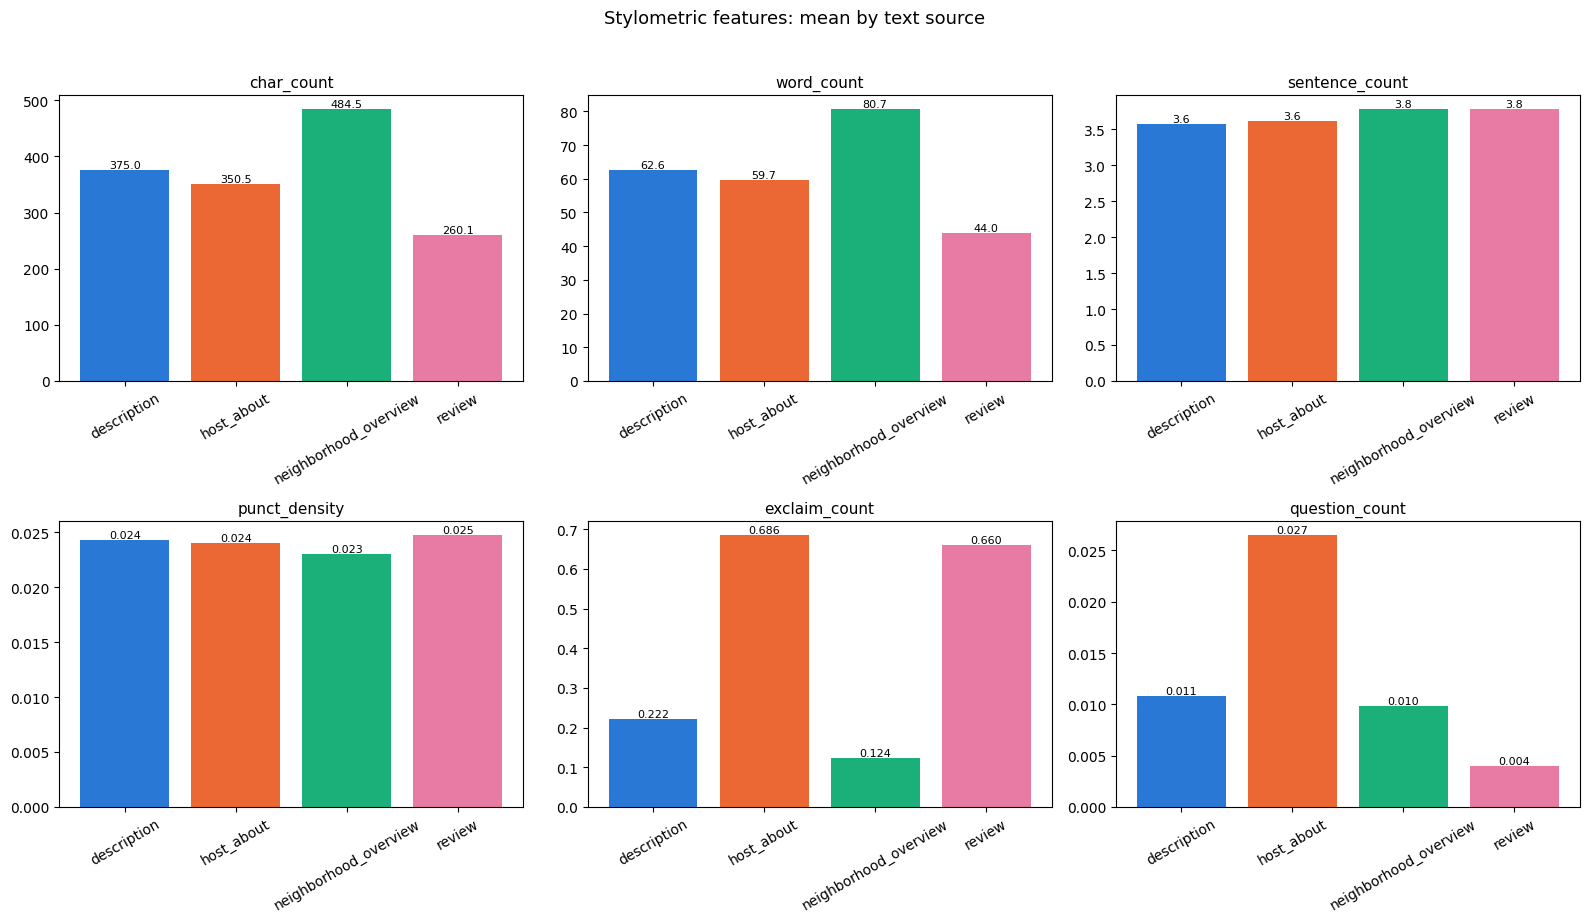

In [43]:
sources = {
    'description': 'description_',
    'host_about': 'host_about_',
    'neighborhood_overview': 'neighborhood_overview_',
    'review': 'review_'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = {'description': '#2a78d6', 'host_about': '#eb6834', 'neighborhood_overview': '#1baf7a', 'review': '#e87ba4'}

for i, metric in enumerate(cols):
    ax = axes[i]
    means = []
    labels = []
    bar_colors = []
    for source_name, prefix in sources.items():
        col = f'{prefix}{metric}'
        if col in listings_clean.columns:
            means.append(listings_clean[col].mean())
            labels.append(source_name)
            bar_colors.append(colors[source_name])

    ax.bar(labels, means, color=bar_colors)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    for j, v in enumerate(means):
        ax.text(j, v, f'{v:.3f}' if v < 1 else f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Stylometric features: mean by text source', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**

- `neighborhood_overview` stands out as the longest field on average (char/word/sentence counts all highest), despite being one of the two optional fields. Hosts who bother filling it in tend to write substantially, not just a token sentence.

- `host_about` and reviews are the most emotionally expressive: both show a noticeably higher `exclaim_count` than `description` and `neighborhood_overview`, suggesting personal, enthusiastic writing rather than the more neutral, functional tone of a property description.

- `question_count` is close to zero across every source, confirming none of these are naturally a question-asking genre, as descriptions, host bios, and reviews are all declarative by nature.

- `punct_density` is remarkably stable across all four sources (roughly 0.02–0.025), suggesting punctuation usage doesn't vary much by genre, unlike length or exclamation frequency.

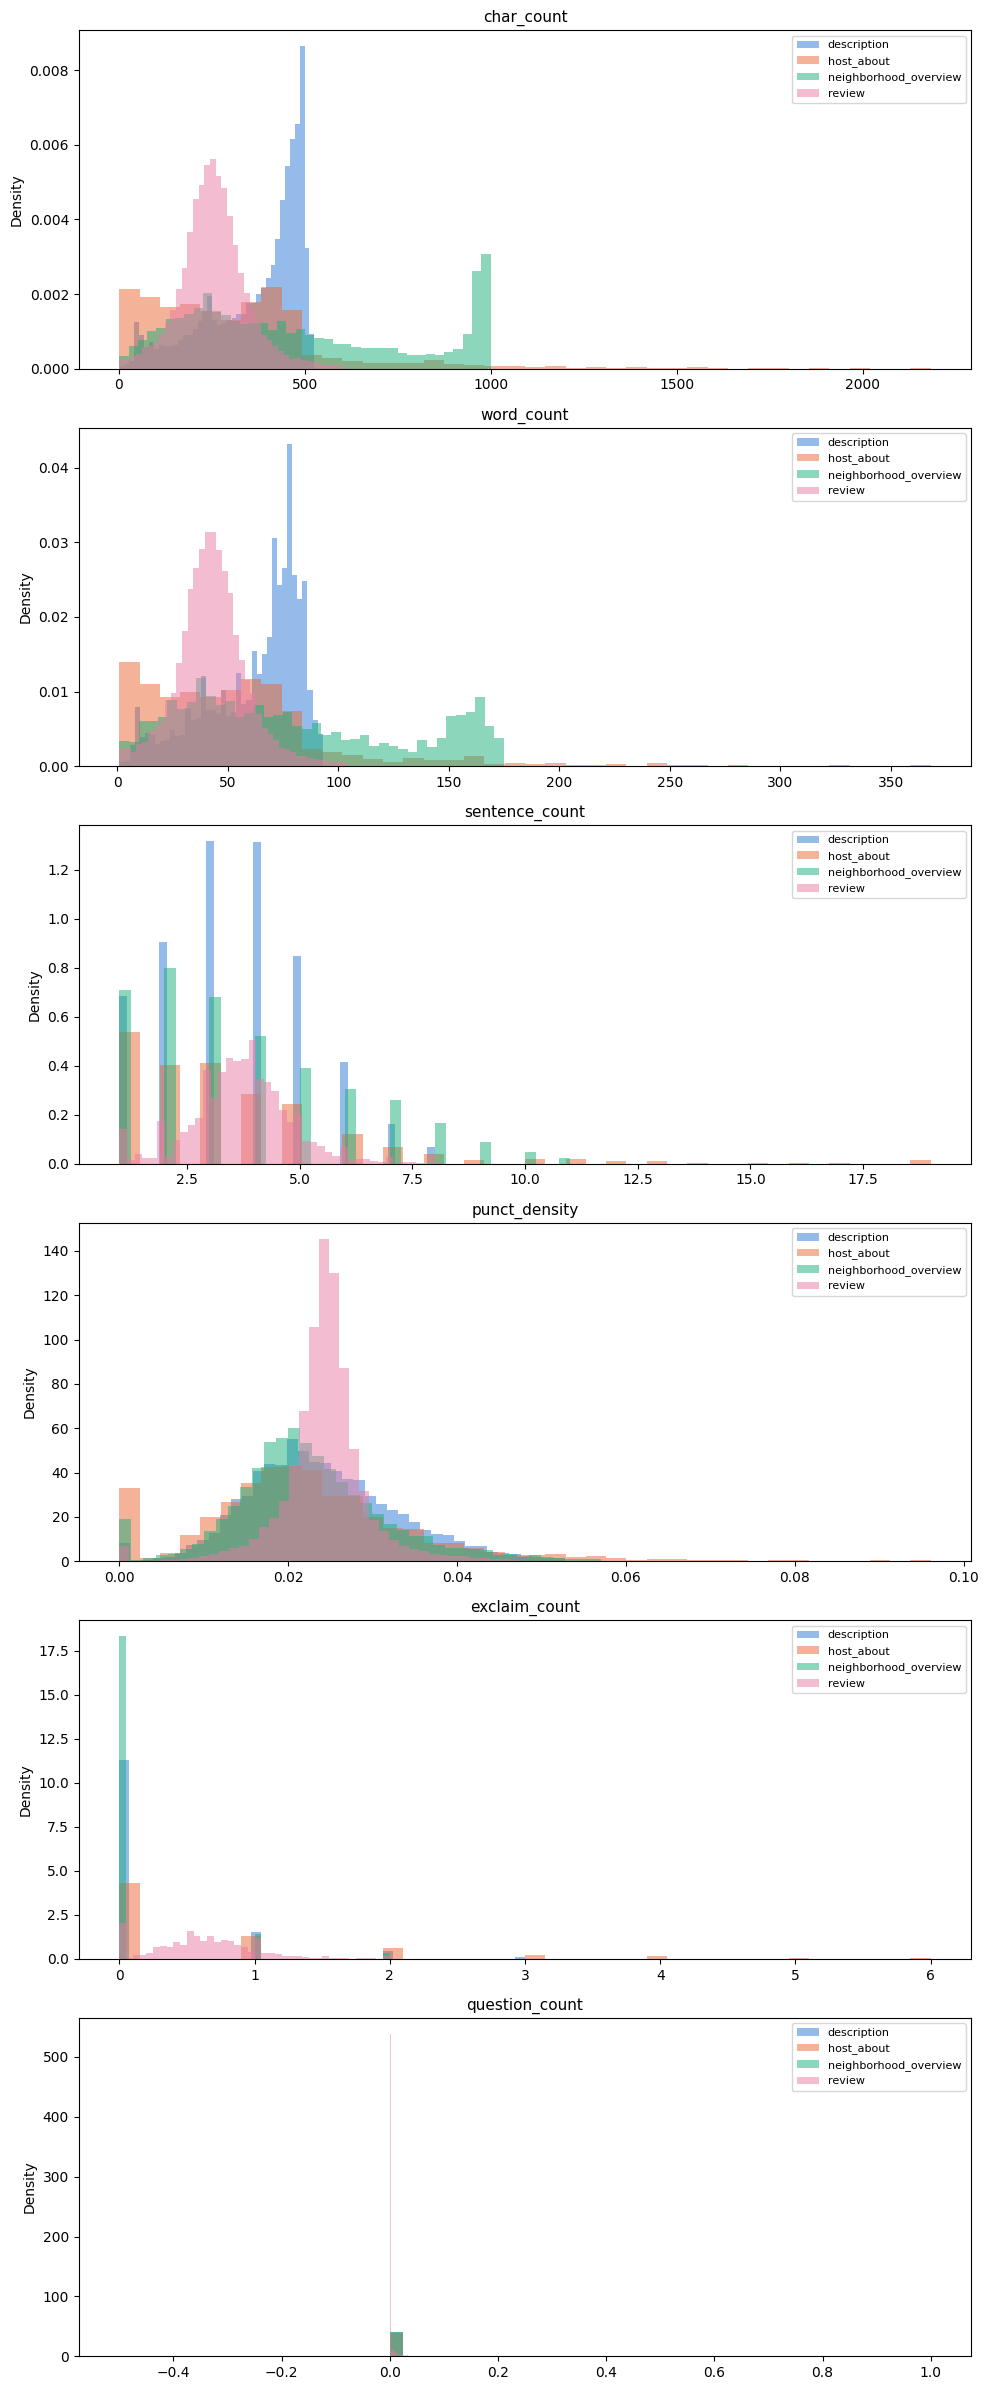

In [44]:
metrics = ['char_count', 'word_count', 'sentence_count', 'punct_density', 'exclaim_count', 'question_count']
sources = {
    'description': 'description_',
    'host_about': 'host_about_',
    'neighborhood_overview': 'neighborhood_overview_',
    'review': 'review_'
}
colors = {'description': '#2a78d6', 'host_about': '#eb6834', 'neighborhood_overview': '#1baf7a', 'review': '#e87ba4'}

fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 4 * len(metrics)))

for i, metric in enumerate(metrics):
    ax = axes[i]
    for source_name, prefix in sources.items():
        col = f'{prefix}{metric}'
        if col in listings_clean.columns:
            data = listings_clean[col].dropna()
            # clip extreme tails for visibility (99th percentile) without altering the underlying data
            upper = data.quantile(0.99)
            ax.hist(data[data <= upper], bins=40, alpha=0.5, label=source_name, color=colors[source_name], density=True)
    ax.set_title(metric, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

In [45]:
summary_rows = []
for source_name, prefix in sources.items():
    for metric in metrics:
        col = f'{prefix}{metric}'
        if col in listings_clean.columns:
            data = listings_clean[col].dropna()
            summary_rows.append({
                'source': source_name,
                'metric': metric,
                'n': len(data),
                'mean': round(data.mean(), 3),
                'median': round(data.median(), 3),
                'std': round(data.std(), 3),
                'min': round(data.min(), 3),
                'p25': round(data.quantile(0.25), 3),
                'p75': round(data.quantile(0.75), 3),
                'p99': round(data.quantile(0.99), 3),
                'max': round(data.max(), 3)
            })

stylometry_summary = pd.DataFrame(summary_rows)
display(stylometry_summary)

,source,metric,n,mean,median,std,min,p25,p75,p99,max
0,description,char_count,34932,374.988,425.000,131.550,2.0,292.000,474.000,525.690,1000.000
1,description,word_count,34932,62.599,70.000,22.255,1.0,49.000,79.000,93.000,184.000
2,description,sentence_count,34932,3.576,3.000,1.713,1.0,2.000,5.000,8.000,13.000
3,description,punct_density,34932,0.024,0.023,0.010,0.0,0.018,0.030,0.053,0.188
4,description,exclaim_count,34932,0.222,0.000,0.618,0.0,0.000,0.000,3.000,13.000
5,description,question_count,34932,0.011,0.000,0.115,0.0,0.000,0.000,0.000,3.000
6,host_about,char_count,16107,350.536,284.000,403.654,1.0,127.000,432.000,2182.000,9190.000
7,host_about,word_count,16107,59.701,49.000,68.417,1.0,22.000,71.000,368.000,1449.000
8,host_about,sentence_count,16107,3.617,3.000,3.246,1.0,2.000,5.000,19.000,76.000
9,host_about,punct_density,16107,0.024,0.021,0.021,0.0,0.015,0.029,0.096,0.667


**Observations:**

- `neighborhood_overview`, `host_about` and `description` are the most variable in length, reflecting that these are free-form, optional fields with no strong convention for length, as some hosts write a sentence, others write several paragraphs.

- `description` and `neighborhood_overview` both show a hard ceiling at 1000 characters, consistent with a platform-imposed character limit on these fields rather than an organic distributional feature, so hosts writing longer text are simply truncated at this point.

- `host_about` shows the heaviest right-skew of any field, which shows that a small number of hosts write extremely long personal bios. 

- `exclaim_count` and `question_count` are heavily zero-inflated across every source, meaning most texts contain no exclamation or question marks at all. As continuous features this carries limited signal for a clustering algorithm, so converting to binary flags (`has_exclaim`, `has_question`) should be considered in further stages.

#### 4.3.2 Readability

Readability will be computed using language-adapted Flesch Reading Ease formulas (via `textstat`) where calibrated coefficients are available, for English, Italian, French, Spanish, German, and Russian. For all other whitespace-tokenized languages, or for text that doesn't follow normal sentence structure (e.g. keyword-style listings with no terminal punctuation), a coarse structural proxy (average word length) is computed instead, but since this lives on an incompatible scale to Flesch, it is not retained in the final numeric `_readability` column, only recorded via a companion `_readability_method` column (`flesch` / `proxy` / `unavailable`). Only languages without whitespace-based word boundaries (e.g. Chinese, Japanese, Thai), where word-splitting itself breaks down, are marked `unavailable` outright.

In [46]:
import textstat

FLESCH_CANDIDATE_LANGS = ['en', 'it', 'fr', 'es', 'de', 'ru']
NO_WHITESPACE_LANGS = {'zh', 'ja', 'ko', 'th', 'yue', 'wuu'}  # scripts without space-delimited words

def has_sentence_structure(text, word_count):
    # Flesch assumes real sentences
    # text with zero sentence-terminating punctuation but many words is likely a keyword/phrase list
    terminal_count = text.count('.') + text.count('!') + text.count('?')
    if terminal_count == 0 and word_count >= 8:
        return False
    return True

def compute_readability(text, lang):
    if pd.isna(text) or text == 'unknown' or lang == 'too_short':
        return np.nan, 'unavailable'

    text = str(text)
    words = text.split()
    word_count = len(words)

    if lang in FLESCH_CANDIDATE_LANGS and has_sentence_structure(text, word_count):
        try:
            textstat.set_lang(lang)
            return round(textstat.flesch_reading_ease(text), 2), 'flesch'
        except Exception:
            pass  # fall through to proxy below

    if lang in NO_WHITESPACE_LANGS:
        return np.nan, 'unavailable'

    # proxy method is recorded, but the score itself is not computed
    return np.nan, 'proxy'

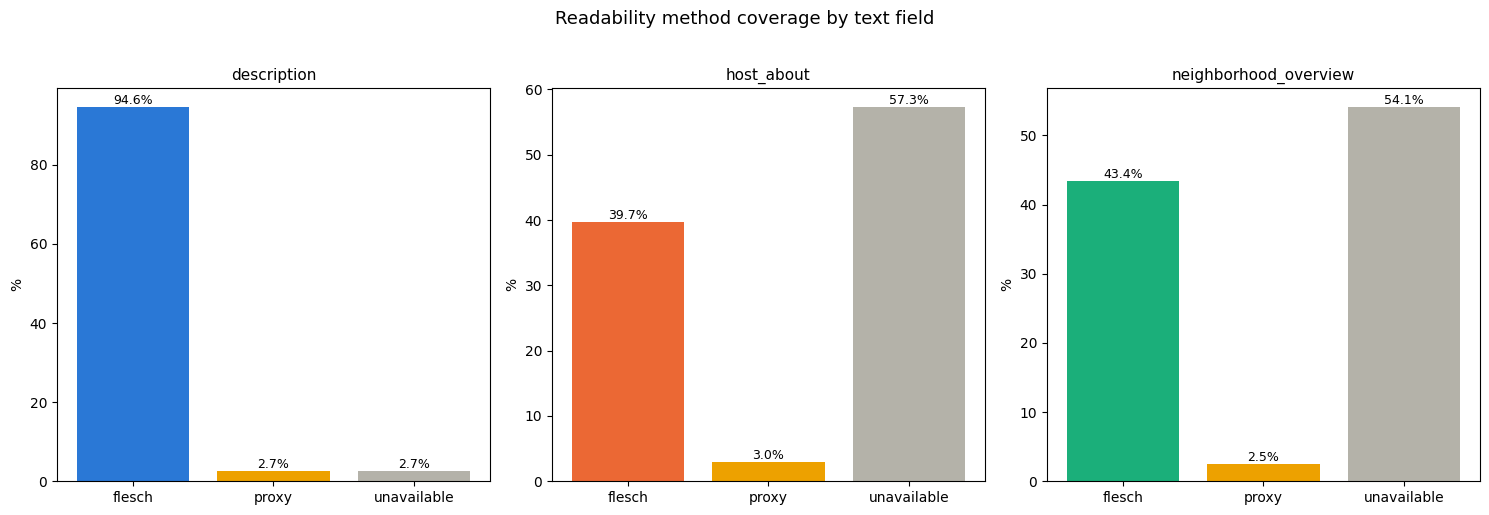

In [48]:
# visualization
readability_method_cols = {
    'description': 'description_readability_method',
    'host_about': 'host_about_readability_method',
    'neighborhood_overview': 'neighborhood_overview_readability_method',
}
colors = {'description': '#2a78d6', 'host_about': '#eb6834', 'neighborhood_overview': '#1baf7a', 'review': '#e87ba4'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (field, method_col) in zip(axes, readability_method_cols.items()):
    pct = listings_clean[method_col].value_counts(normalize=True).mul(100).round(1)
    pct = pct.reindex(['flesch', 'proxy', 'unavailable']).fillna(0)
    ax.bar(pct.index, pct.values, color=[colors[field], '#eda100', '#b4b2a9'])
    ax.set_title(field, fontsize=11)
    ax.set_ylabel('%')
    for i, v in enumerate(pct.values):
        ax.text(i, v, f'{v}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Readability method coverage by text field', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**

- `description` achieve the highest Flesch coverage, consistent with its strong English dominance and near-universal presence in the dataset, so almost every text yields a calibrated readability score.

- `host_about` and `neighborhood_overview` are dominated by `unavailable`, but this largely mirrors their missing-text rates rather than a language-coverage gap, which means that over half of hosts simply don't fill in these optional fields.

- The `proxy` tier stays small across all four fields, confirming that most of the corpus is either genuinely scored via Flesch or genuinely missing.

- The raw `_readability` score is only ever populated for `flesch`-method rows; `proxy` values are excluded from the numeric column since the two scales aren't comparable, but the `_readability_method` column still records where a proxy was computed, in case it's needed later.

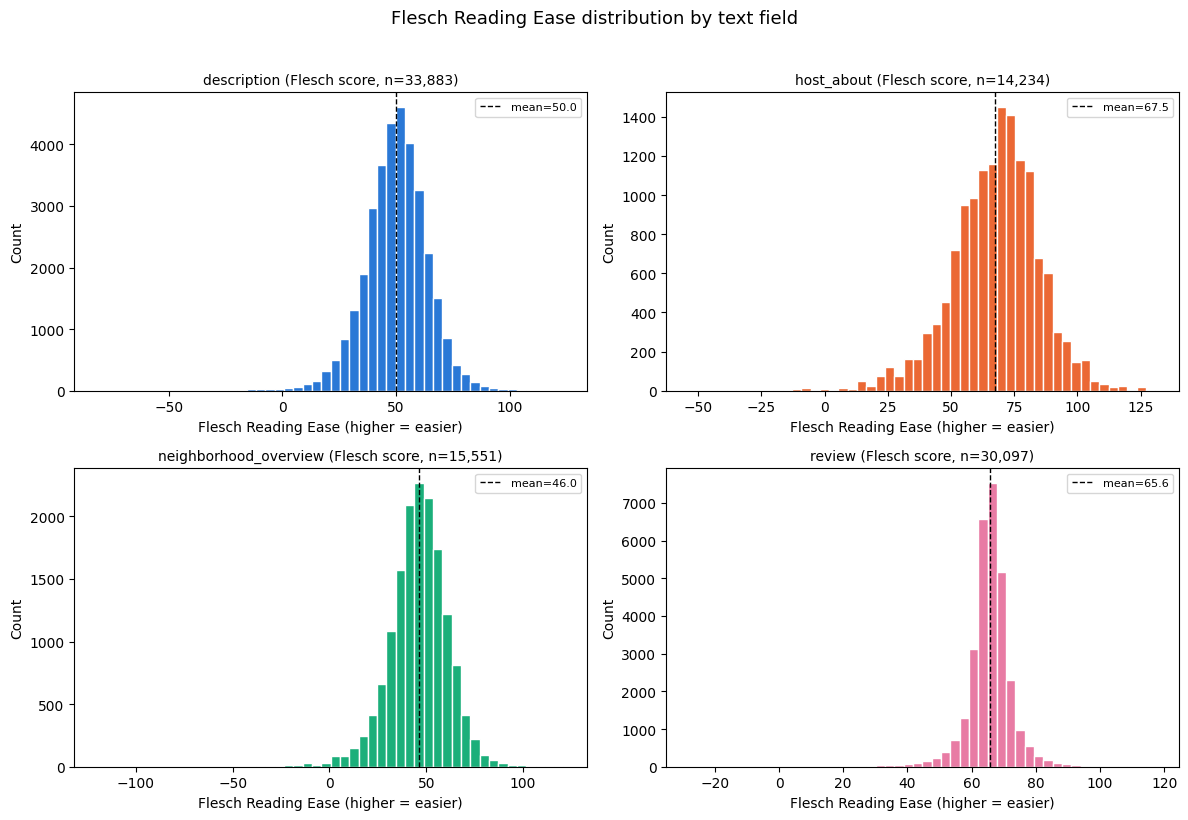

,count,mean,std,min,25%,50%,75%,max
description,33883.0,50.0,13.8,-81.2,41.9,50.4,58.6,123.7
host_about,14234.0,67.5,17.5,-53.5,57.2,68.8,78.9,130.8
neighborhood_overview,15551.0,46.0,15.2,-119.7,37.6,46.6,55.4,120.9
review,30097.0,65.6,7.4,-27.9,62.7,65.8,68.9,117.2


In [49]:
readability_cols_listing = {
    'description': ('description_readability', 'description_readability_method'),
    'host_about': ('host_about_readability', 'host_about_readability_method'),
    'neighborhood_overview': ('neighborhood_overview_readability', 'neighborhood_overview_readability_method'),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (field, (score_col, method_col)) in enumerate(readability_cols_listing.items()):
    flesch_scores = listings_clean.loc[listings_clean[method_col] == 'flesch', score_col]
    axes[i].hist(flesch_scores, bins=50, color=colors[field], edgecolor='white')
    axes[i].set_title(f'{field} (Flesch score, n={len(flesch_scores):,})', fontsize=10)
    axes[i].set_xlabel('Flesch Reading Ease (higher = easier)')
    axes[i].set_ylabel('Count')
    axes[i].axvline(flesch_scores.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={flesch_scores.mean():.1f}')
    axes[i].legend(fontsize=8)

# review: filter by value presence
review_flesch = listings_clean['review_readability'].dropna()
axes[3].hist(review_flesch, bins=50, color=colors['review'], edgecolor='white')
axes[3].set_title(f'review (Flesch score, n={len(review_flesch):,})', fontsize=10)
axes[3].set_xlabel('Flesch Reading Ease (higher = easier)')
axes[3].set_ylabel('Count')
axes[3].axvline(review_flesch.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={review_flesch.mean():.1f}')
axes[3].legend(fontsize=8)

plt.suptitle('Flesch Reading Ease distribution by text field', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    **{field: listings_clean.loc[listings_clean[method_col] == 'flesch', score_col].describe()
       for field, (score_col, method_col) in readability_cols_listing.items()},
    'review': listings_clean['review_readability'].dropna().describe()
}).T
display(summary.round(1))

**Observations:**

All four fields show a roughly bell-shaped distribution around their respective means, but they differ meaningfully in both center and spread. Personal, conversational writing (`host_about`) reads easiest on average, while more descriptive, list-heavy writing (`neighborhood_overview`, and to a lesser extent `description`) reads hardest, reflecting that self-introductions tend toward short, simple sentences, while property and neighborhood descriptions pack in more clauses, proper nouns, and keyword phrases.

`review` stands out as by far the most consistent field, with a much tighter spread than any listing-authored text. Guest reviews are written in a fairly uniform, moderately easy register regardless of who's writing them, unlike the listing fields where writing style varies a lot host to host.

Extreme negative outliers appear across all fields but are most pronounced in `neighborhood_overview`. These reflect Flesch's sentence-length assumption breaking down on keyword-style, comma-separated listings rather than genuine errors, which is a limitation of applying the formula to informal, user-generated text.

#### 4.3.3 Vocabulary Richness

This section calculates vocabulary richness, meaning how varied the word choice is within a text. The simplest way to measure this is the type-token ratio, comparing the number of unique words to the total number of words, but this measure is heavily influenced by text length, since shorter texts naturally reuse fewer words and end up looking artificially more diverse. To correct for this, MTLD is used instead as the main metric, since it produces scores that stay comparable regardless of how long the text is, and it works across all languages in the corpus without needing any language specific calibration, unlike the readability scores computed earlier. The goal here is to capture how varied each host or guest is in their choice of words, as a stylistic signal distinct from what they actually write about, to be checked later for redundancy against the readability features already in place.

In [50]:
# vocabulary richness: language-agnostic word tokenizer (Unicode-aware \w)
_WORD_TOKEN_RE = re.compile(r"\w+", re.UNICODE)

def tokenize_words(text):
    return _WORD_TOKEN_RE.findall(str(text).lower())

MTLD_THRESHOLD = 0.72        # standard factor threshold (McCarthy & Jarvis, 2010)
MIN_WORDS_FOR_MTLD = 20      # below this, TTR-based diversity metrics are unstable/undefined

def _mtld_pass(tokens, threshold=MTLD_THRESHOLD):
    """Single-direction MTLD factor count, with partial credit for the remainder."""
    factors = 0
    types = set()
    token_count = 0
    for token in tokens:
        types.add(token)
        token_count += 1
        if len(types) / token_count <= threshold:
            factors += 1
            types, token_count = set(), 0
    if token_count > 0:
        ttr_remainder = len(types) / token_count
        factors += (1 - ttr_remainder) / (1 - threshold)
    return len(tokens) / factors if factors > 0 else float(len(tokens))

def compute_vocab_richness(text, lang):
    if pd.isna(text) or text == 'unknown' or lang in ('too_short', 'unknown'):
        return np.nan, np.nan, 'unavailable'
    if lang in NO_WHITESPACE_LANGS: 
        return np.nan, np.nan, 'unavailable'

    tokens = tokenize_words(text)
    if len(tokens) == 0:
        return np.nan, np.nan, 'unavailable'

    ttr = round(len(set(tokens)) / len(tokens), 4)  # diagnostic only, not saved as a feature

    if len(tokens) < MIN_WORDS_FOR_MTLD:
        return ttr, np.nan, 'too_short'

    # bidirectional MTLD, averaged forward/backward pass 
    mtld_score = round((_mtld_pass(tokens) + _mtld_pass(tokens[::-1])) / 2, 2)
    return ttr, mtld_score, 'mtld'

In [51]:
# listings text fields
lang_field_map_vocab = {
    'description_cleaned': 'description_lang',
    'host_about_cleaned': 'host_about_lang',
    'neighborhood_overview_cleaned': 'neighborhood_overview_lang'
}

for text_col, lang_col in lang_field_map_vocab.items():
    prefix = text_col.replace('_cleaned', '')
    results = [compute_vocab_richness(t, l) for t, l in zip(listings_clean[text_col], listings_clean[lang_col])]
    listings_clean[f'{prefix}_ttr'] = [r[0] for r in results]        # diagnostic, dropped after validation plot
    listings_clean[f'{prefix}_mtld'] = [r[1] for r in results]
    listings_clean[f'{prefix}_vocab_method'] = [r[2] for r in results]

# reviews aggregated to listing level
substantive_mask = reviews_clean['is_substantive_review'] == 1

review_vocab_results = [
    compute_vocab_richness(t, l) for t, l in zip(
        reviews_clean.loc[substantive_mask, 'comments_clean'],
        reviews_clean.loc[substantive_mask, 'review_lang']
    )
]

review_vocab_df = pd.DataFrame({
    'listing_id': reviews_clean.loc[substantive_mask, 'listing_id'].values,
    'ttr': [r[0] for r in review_vocab_results],
    'mtld': [r[1] for r in review_vocab_results],
    'method': [r[2] for r in review_vocab_results]
})

review_vocab_agg = review_vocab_df.groupby('listing_id').agg(
    review_mtld=('mtld', 'mean'),
)

existing_vocab_cols = [c for c in review_vocab_agg.columns if c in listings_clean.columns]
if existing_vocab_cols:
    listings_clean = listings_clean.drop(columns=existing_vocab_cols)

listings_clean = listings_clean.merge(review_vocab_agg, left_on='id', right_index=True, how='left')

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1860950799.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_clean[f'{prefix}_mtld'] = [r[1] for r in results]
/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1860950799.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_clean[f'{prefix}_vocab_method'] = [r[2] for r in results]


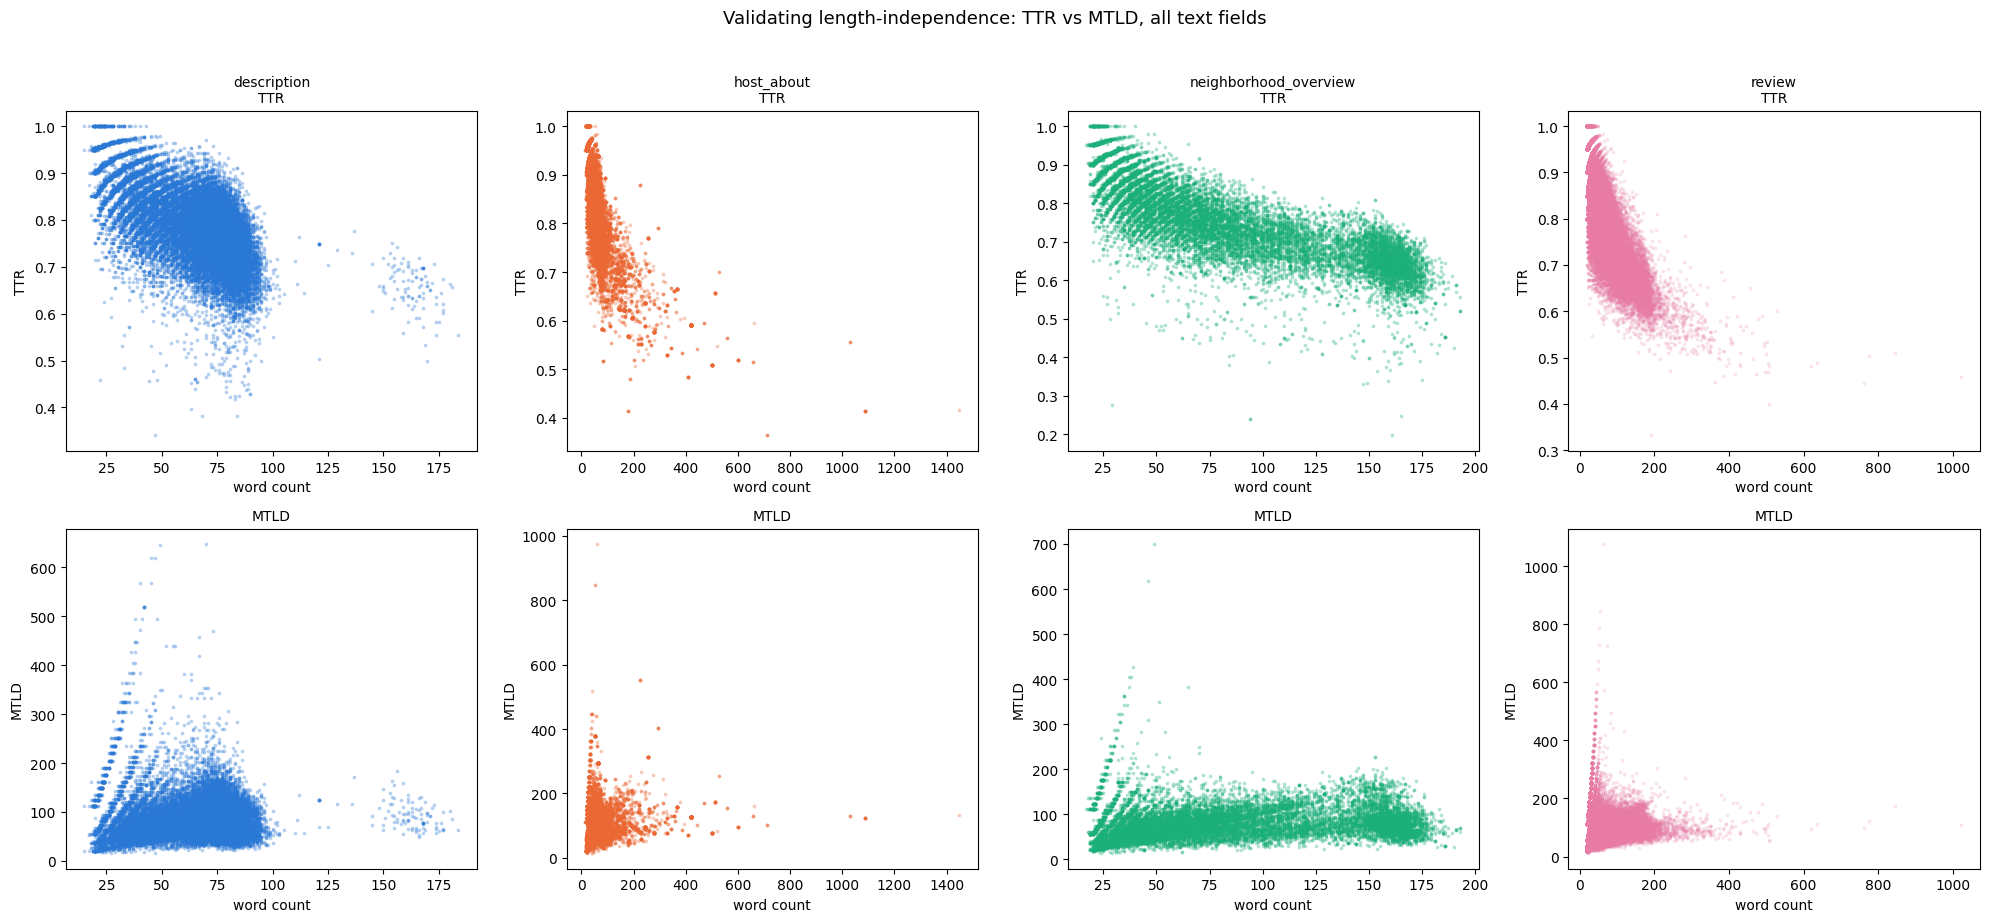

,n,corr_ttr,corr_mtld
field,,,
description,32766,-0.599,0.048
host_about,12498,-0.666,0.114
neighborhood_overview,15195,-0.771,0.158
review,1540121,-0.748,0.149


In [52]:
vocab_fields_listing = {
    'description': ('description_word_count', 'description_ttr', 'description_mtld'),
    'host_about': ('host_about_word_count', 'host_about_ttr', 'host_about_mtld'),
    'neighborhood_overview': ('neighborhood_overview_word_count', 'neighborhood_overview_ttr', 'neighborhood_overview_mtld')
}
colors = {'description': '#2a78d6', 'host_about': '#eb6834', 'neighborhood_overview': '#1baf7a', 'review': '#e87ba4'}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
corr_rows = []

for i, (field, (wc_col, ttr_col, mtld_col)) in enumerate(vocab_fields_listing.items()):
    valid_mask = listings_clean[f'{field}_vocab_method'] == 'mtld'
    wc = listings_clean.loc[valid_mask, wc_col]
    ttr = listings_clean.loc[valid_mask, ttr_col]
    mtld = listings_clean.loc[valid_mask, mtld_col]

    axes[0, i].scatter(wc, ttr, s=3, alpha=0.25, color=colors[field])
    axes[0, i].set_title(f'{field}\nTTR', fontsize=10)
    axes[0, i].set_xlabel('word count'); axes[0, i].set_ylabel('TTR')

    axes[1, i].scatter(wc, mtld, s=3, alpha=0.25, color=colors[field])
    axes[1, i].set_title('MTLD', fontsize=10)
    axes[1, i].set_xlabel('word count'); axes[1, i].set_ylabel('MTLD')

    corr_rows.append({
        'field': field, 'n': len(wc),
        'corr_ttr': round(np.corrcoef(wc, ttr)[0, 1], 3),
        'corr_mtld': round(np.corrcoef(wc, mtld)[0, 1], 3)
    })

# review: individual-review granularity, word_count recomputed here directly (idempotent — no dependency on earlier cell state)
review_vocab_df['word_count'] = reviews_clean.loc[substantive_mask, 'comments_clean'].apply(
    lambda t: len(tokenize_words(t))
).values

review_valid = review_vocab_df[review_vocab_df['method'] == 'mtld']
plot_sample = review_valid.sample(n=min(50_000, len(review_valid)), random_state=42)

axes[0, 3].scatter(plot_sample['word_count'], plot_sample['ttr'], s=3, alpha=0.15, color=colors['review'])
axes[0, 3].set_title('review\nTTR', fontsize=10)
axes[0, 3].set_xlabel('word count'); axes[0, 3].set_ylabel('TTR')

axes[1, 3].scatter(plot_sample['word_count'], plot_sample['mtld'], s=3, alpha=0.15, color=colors['review'])
axes[1, 3].set_title('MTLD', fontsize=10)
axes[1, 3].set_xlabel('word count'); axes[1, 3].set_ylabel('MTLD')

corr_rows.append({
    'field': 'review', 'n': len(review_valid),
    'corr_ttr': round(np.corrcoef(review_valid['word_count'], review_valid['ttr'])[0, 1], 3),
    'corr_mtld': round(np.corrcoef(review_valid['word_count'], review_valid['mtld'])[0, 1], 3)
})

plt.suptitle('Validating length-independence: TTR vs MTLD, all text fields', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

corr_summary = pd.DataFrame(corr_rows).set_index('field')
display(corr_summary)

Across all four text sources, TTR shows the length bias it's known for, with strong negative correlations against word count. MTLD correlations are consistently much weaker, confirming the length-correction works as intended relative to the naive TTR baseline, even though it isn't reduced to exactly zero anywhere. The wedge-shaped pattern of inflated MTLD values at low word counts is visible in every field. 

`host_about`, `neighborhood_overview`, and `review` show somewhat higher residual MTLD-length correlation than `description`, which is consistent with these being more informal, less structured writing overall.

In [53]:
ttr_cols_to_drop = [c for c in listings_clean.columns if c.endswith('_ttr')]
listings_clean = listings_clean.drop(columns=ttr_cols_to_drop)


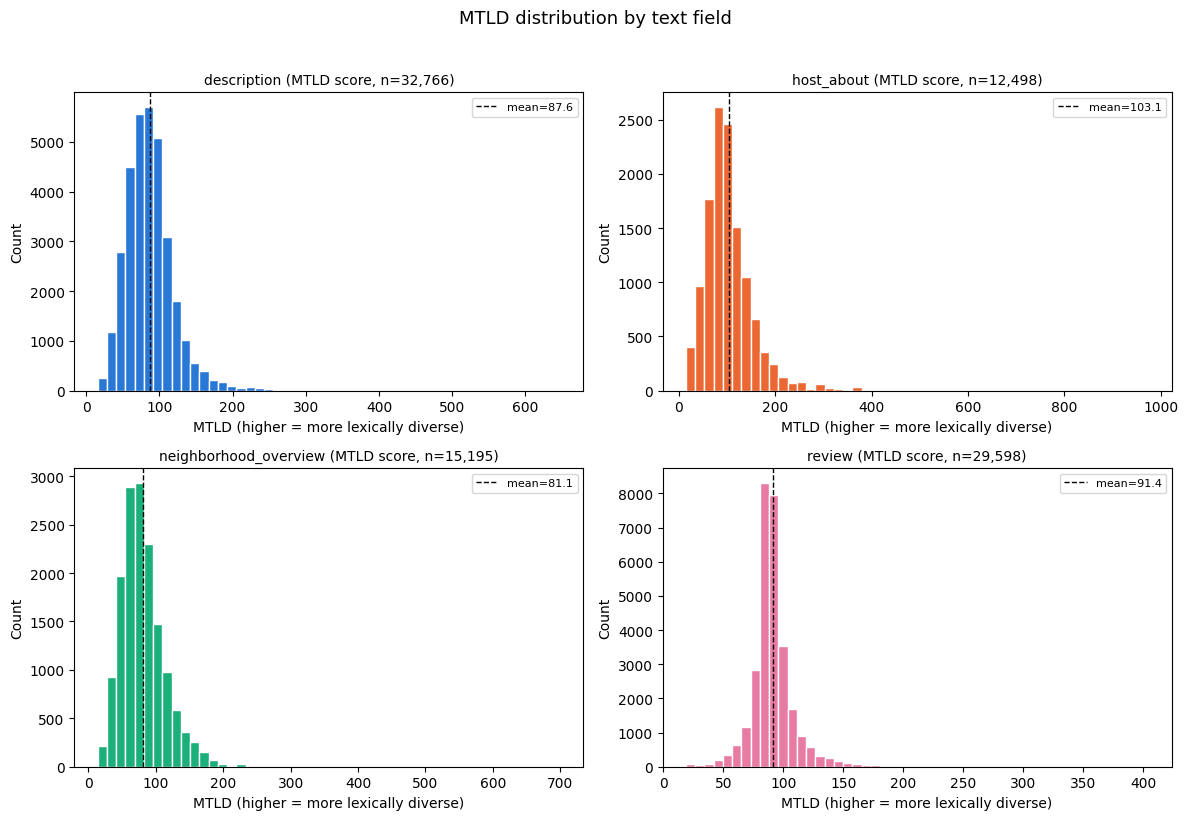

,count,mean,std,min,25%,50%,75%,max
description,32766.0,87.6,36.8,15.7,64.7,83.8,102.8,647.4
host_about,12498.0,103.1,52.8,14.1,71.7,94.1,124.3,974.7
neighborhood_overview,15195.0,81.1,34.5,13.5,58.3,75.8,97.3,700.0
review,29598.0,91.4,20.4,18.8,83.0,89.0,96.7,404.3


In [54]:
mtld_cols = {
    'description': 'description_mtld',
    'host_about': 'host_about_mtld',
    'neighborhood_overview': 'neighborhood_overview_mtld',
    'review': 'review_mtld'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = {'description': '#2a78d6', 'host_about': '#eb6834', 'neighborhood_overview': '#1baf7a', 'review': '#e87ba4'}

for i, (field, score_col) in enumerate(mtld_cols.items()):
    mtld_scores = listings_clean[score_col].dropna()
    axes[i].hist(mtld_scores, bins=50, color=colors[field], edgecolor='white')
    axes[i].set_title(f'{field} (MTLD score, n={len(mtld_scores):,})', fontsize=10)
    axes[i].set_xlabel('MTLD (higher = more lexically diverse)')
    axes[i].set_ylabel('Count')
    axes[i].axvline(mtld_scores.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={mtld_scores.mean():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('MTLD distribution by text field', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# summary stats table
summary = pd.DataFrame({
    field: listings_clean[score_col].dropna().describe()
    for field, score_col in mtld_cols.items()
}).T
display(summary.round(1))

**Observations:**

All four fields show a similar bell-shaped distribution, but with a visible right skew for the three listing-authored fields: in each case the mean sits above the median, pulled up by a long tail of high-MTLD outliers.

`review` stands out as the most symmetric and tightly concentrated of the four, with mean and median almost coinciding and a much smaller standard deviation. This is expected rather than a new finding as `review_mtld` is a per-listing average across all of that listing's substantive reviews.

`host_about` has both the highest mean and the widest spread, suggesting personal host bios vary the most in vocabulary diversity, from very repetitive short bios to long, varied personal narratives.

`neighborhood_overview` sits at the lower end, which confirms that these texts lean more toward repeated, keyword-style phrasing (points of interest, transport links) than genuinely varied prose.

Given the right-skew visible across the three listing fields, all four MTLD variables remain candidates for the unified log-transform check.

#### 4.3.4 Personalization

This section measures personalization markers, meaning how much a text speaks about the author personally or addresses the reader directly, rather than describing something in an impersonal, third-person way. Three pronoun-based densities are computed per 100 words: singular self-reference (I, me, my), plural self-reference (we, us, our), and direct address (you, your), covering the same six languages used for readability (English, Italian, French, Spanish, German, Russian), with all other languages marked as unavailable. For listing text this can hint at whether a host writes as an individual or as part of an agency or management company.

Two **limitations** of this rule-based approach are stated upfront rather than discovered later:
- counting pronouns is a surface-level signal and cannot tell whether a pronoun genuinely personalizes the text or just appears in a generic phrase (for example, "you can see the Colosseum from the balcony" uses "you" without addressing the reader personally), so the density reflects word choice, not confirmed intent.
  
- since all text was lowercased during data cleaning, German loses the capitalization that normally separates the formal "Sie/Ihr" (you) from the lowercase "sie/ihr" (she, they, her), so German's direct-address density will be somewhat inflated by third-person references it cannot filter out. This is accepted as a known method limitation.

In [55]:
PERSONALIZATION_LANGS = FLESCH_CANDIDATE_LANGS  # same six-language coverage

self_singular_pronouns = {
    'en': {'i', 'me', 'my', 'mine', 'myself'},
    'it': {'io', 'mi', 'me', 'mio', 'mia', 'miei', 'mie'},
    'fr': {'je', 'j', 'me', 'moi', 'mon', 'ma', 'mes'},
    'es': {'yo', 'me', 'mi', 'mío', 'mía', 'míos', 'mías'},
    'de': {'ich', 'mir', 'mich', 'mein', 'meine', 'meiner', 'meinem', 'meinen'},
    'ru': {'я', 'меня', 'мне', 'мной', 'мной', 'мой', 'моя', 'моё', 'мои',
           'моего', 'моей', 'моим', 'моих'}
}

self_plural_pronouns = {
    'en': {'we', 'us', 'our', 'ours', 'ourselves'},
    'it': {'noi', 'ci', 'nostro', 'nostra', 'nostri', 'nostre'},
    'fr': {'nous', 'notre', 'nos'},
    'es': {'nosotros', 'nosotras', 'nos', 'nuestro', 'nuestra', 'nuestros', 'nuestras'},
    'de': {'wir', 'uns', 'unser', 'unsere', 'unserem', 'unseren', 'unserer'},
    'ru': {'мы', 'нас', 'нам', 'нами', 'наш', 'наша', 'наше', 'наши',
           'нашего', 'нашей', 'нашим', 'наших'}
}

direct_address_pronouns = {
    'en': {'you', 'your', 'yours', 'yourself', 'yourselves'},
    'it': {'tu', 'ti', 'te', 'tuo', 'tua', 'tuoi', 'tue', 'voi', 'vi', 'vostro', 'vostra'},
    'fr': {'tu', 'te', 'toi', 'ton', 'ta', 'tes', 'vous', 'votre', 'vos'},
    'es': {'tu', 'tú', 'te', 'ti', 'tuyo', 'tuya', 'usted', 'ustedes', 'su', 'sus'},
    'de': {'du', 'dich', 'dir', 'dein', 'deine', 'sie', 'ihnen', 'ihr', 'ihre'},
    'ru': {'ты', 'тебя', 'тебе', 'тобой', 'твой', 'твоя', 'твоё', 'твои',
           'вы', 'вас', 'вам', 'вами', 'ваш', 'ваша', 'ваше', 'ваши'}
}

def compute_personalization(text, lang):
    if pd.isna(text) or text == 'unknown' or lang in ('too_short', 'unknown'):
        return np.nan, np.nan, np.nan, 'unavailable'
    if lang not in PERSONALIZATION_LANGS:
        return np.nan, np.nan, np.nan, 'unavailable'

    tokens = tokenize_words(text)
    word_count = len(tokens)
    if word_count == 0:
        return np.nan, np.nan, np.nan, 'unavailable'

    self_sg = sum(1 for t in tokens if t in self_singular_pronouns[lang])
    self_pl = sum(1 for t in tokens if t in self_plural_pronouns[lang])
    direct = sum(1 for t in tokens if t in direct_address_pronouns[lang])

    self_ref_density = round(self_sg / word_count * 100, 3)
    we_ref_density = round(self_pl / word_count * 100, 3)
    direct_address_density = round(direct / word_count * 100, 3)

    return self_ref_density, we_ref_density, direct_address_density, 'computed'

In [56]:
# listing text fields
personalization_field_map = {
    'description_cleaned': 'description_lang',
    'host_about_cleaned': 'host_about_lang',
    'neighborhood_overview_cleaned': 'neighborhood_overview_lang'
}

for text_col, lang_col in personalization_field_map.items():
    prefix = text_col.replace('_cleaned', '')
    results = [compute_personalization(t, l) for t, l in zip(listings_clean[text_col], listings_clean[lang_col])]
    listings_clean[f'{prefix}_self_ref_density'] = [r[0] for r in results]
    listings_clean[f'{prefix}_we_ref_density'] = [r[1] for r in results]
    listings_clean[f'{prefix}_direct_address_density'] = [r[2] for r in results]
    listings_clean[f'{prefix}_personalization_method'] = [r[3] for r in results]

# reviews aggregated to listing level
review_personalization_results = [
    compute_personalization(t, l) for t, l in zip(
        reviews_clean.loc[substantive_mask, 'comments_clean'],
        reviews_clean.loc[substantive_mask, 'review_lang']
    )
]

review_personalization_df = pd.DataFrame({
    'listing_id': reviews_clean.loc[substantive_mask, 'listing_id'].values,
    'self_ref_density': [r[0] for r in review_personalization_results],
    'we_ref_density': [r[1] for r in review_personalization_results],
    'direct_address_density': [r[2] for r in review_personalization_results]
})

review_personalization_agg = review_personalization_df.groupby('listing_id').agg(
    review_self_ref_density=('self_ref_density', 'mean'),
    review_we_ref_density=('we_ref_density', 'mean'),
    review_direct_address_density=('direct_address_density', 'mean')
)

existing_pers_cols = [c for c in review_personalization_agg.columns if c in listings_clean.columns]
if existing_pers_cols:
    listings_clean = listings_clean.drop(columns=existing_pers_cols)

listings_clean = listings_clean.merge(review_personalization_agg, left_on='id', right_index=True, how='left')

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1327972822.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_clean[f'{prefix}_we_ref_density'] = [r[1] for r in results]
/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1327972822.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_clean[f'{prefix}_direct_address_density'] = [r[2] for r in results]
/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1327972822.py:14: PerformanceWarning: DataFrame is highly fragmen

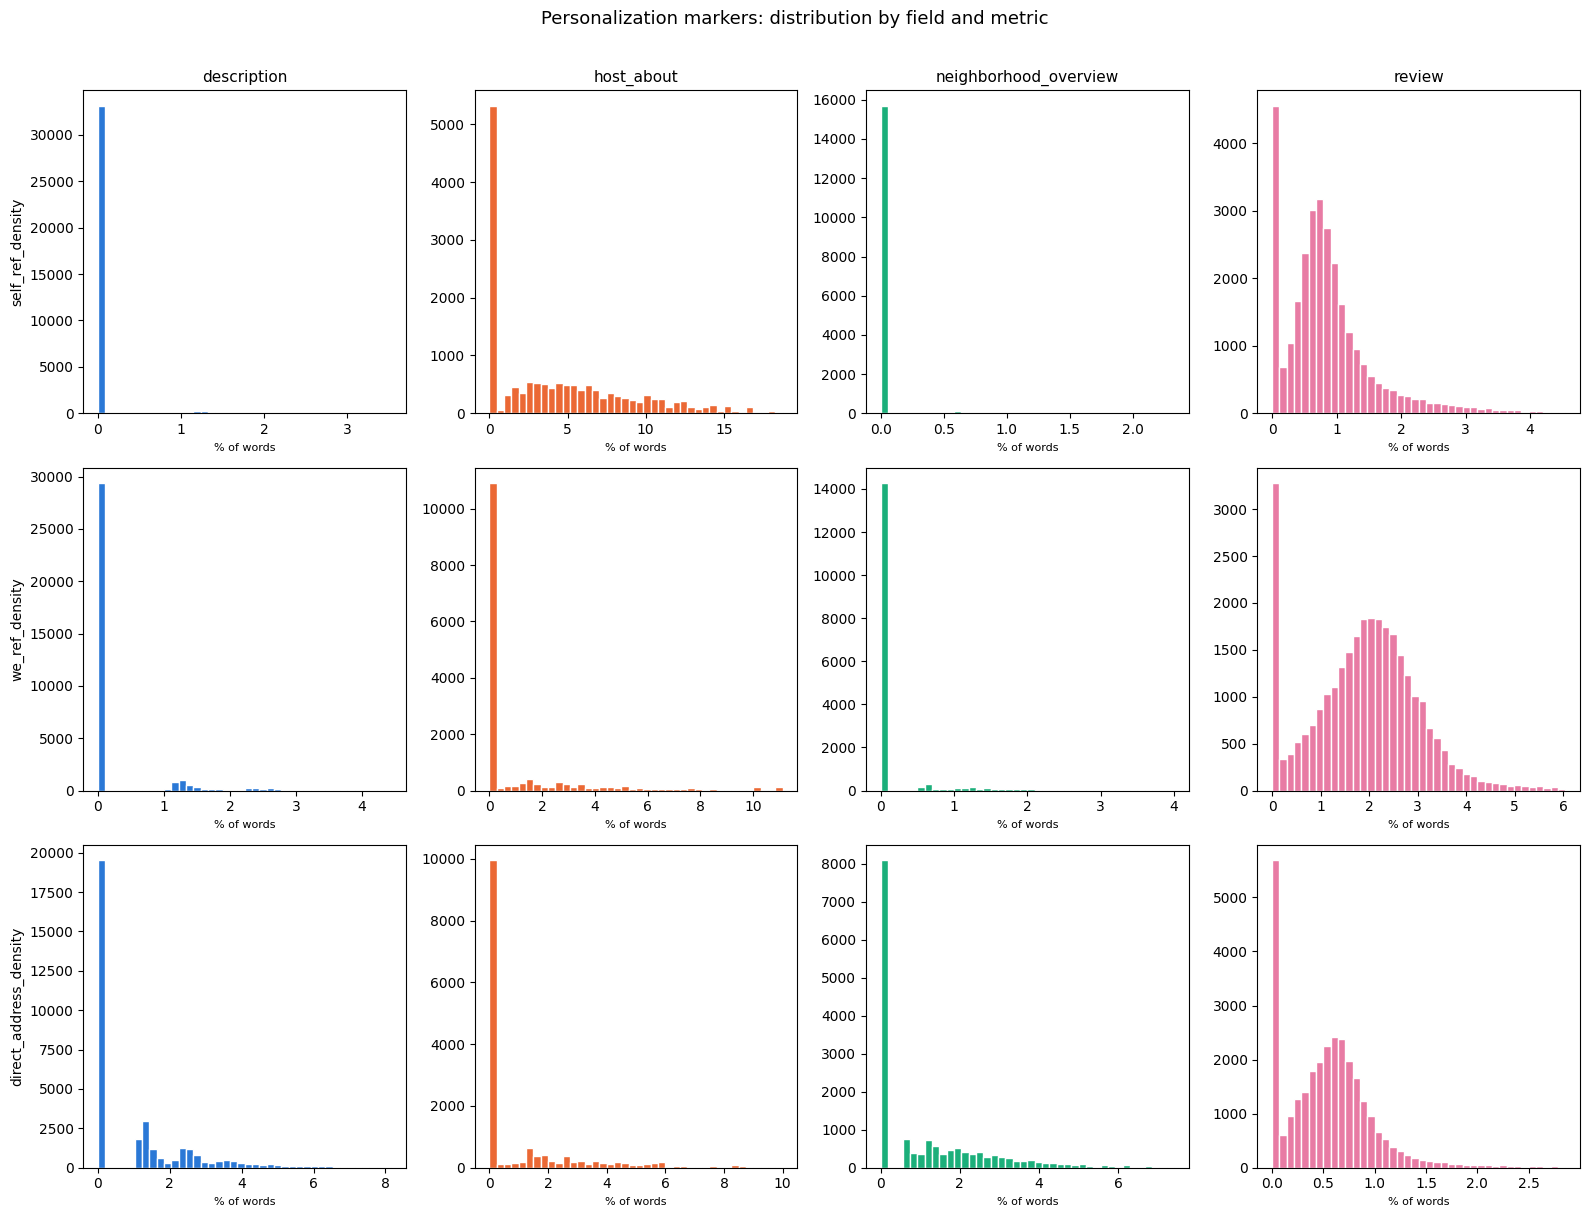

In [57]:
personalization_metrics = ['self_ref_density', 'we_ref_density', 'direct_address_density']
personalization_sources = {
    'description': 'description_',
    'host_about': 'host_about_',
    'neighborhood_overview': 'neighborhood_overview_',
    'review': 'review_'
}
colors = {'description': '#2a78d6', 'host_about': '#eb6834', 'neighborhood_overview': '#1baf7a', 'review': '#e87ba4'}

fig, axes = plt.subplots(len(personalization_metrics), len(personalization_sources), figsize=(16, 4 * len(personalization_metrics)))

for row, metric in enumerate(personalization_metrics):
    for col_idx, (source_name, prefix) in enumerate(personalization_sources.items()):
        ax = axes[row, col_idx]
        col = f'{prefix}{metric}'
        data = listings_clean[col].dropna()
        upper = data.quantile(0.99)
        ax.hist(data[data <= upper], bins=40, color=colors[source_name], edgecolor='white')
        if row == 0:
            ax.set_title(source_name, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(metric, fontsize=10)
        ax.set_xlabel('% of words', fontsize=8)

plt.suptitle('Personalization markers: distribution by field and metric', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [58]:
listings_clean[[c for c in listings_clean.columns if (c.endswith('ref_density') or c.endswith('address_density'))]].describe().T

,count,mean,std,min,25%,50%,75%,max
description_self_ref_density,34854.0,0.128016,0.711391,0.0,0.000000,0.000000,0.000000,14.286
description_we_ref_density,34854.0,0.334960,0.945631,0.0,0.000000,0.000000,0.000000,14.634
description_direct_address_density,34854.0,1.187772,1.843409,0.0,0.000000,0.000000,1.818000,27.273
host_about_self_ref_density,15279.0,4.514745,4.924888,0.0,0.000000,3.378000,7.317000,50.000
host_about_we_ref_density,15279.0,1.210379,2.606235,0.0,0.000000,0.000000,1.235000,22.581
host_about_direct_address_density,15279.0,1.212617,2.284527,0.0,0.000000,0.000000,1.724000,25.000
neighborhood_overview_self_ref_density,16442.0,0.083485,0.543373,0.0,0.000000,0.000000,0.000000,16.667
neighborhood_overview_we_ref_density,16442.0,0.241479,0.832170,0.0,0.000000,0.000000,0.000000,17.391
neighborhood_overview_direct_address_density,16442.0,1.263184,1.754059,0.0,0.000000,0.599000,2.083000,16.667
review_self_ref_density,30286.0,0.908648,0.954683,0.0,0.430206,0.745223,1.104377,25.000


**Observations:**

The direction of personalization differs meaningfully by source, consistent with what each field is for:
- `host_about` shows the highest self-reference by far, confirming hosts write personally about themselves there.
- `review` shows more we-reference than self-reference, suggesting guests often write as a group rather than an individual.
- `description`/`neighborhood_overview` are dominated by direct address rather than self-reference, fitting their role as marketing text aimed at a prospective guest rather than personal narrative.

Zero-inflation is severe but uneven across the twelve variables, not a uniform property of the metric.
- `description_self_ref`, `description_we_ref`, `neighborhood_overview_self_ref`, `neighborhood_overview_we_ref` have a 75th percentile of exactly 0, meaning at least three-quarters of listings never use that pronoun category in that field at all, which mirrors the zero-inflation already flagged for `exclaim_count`/`question_count`, and these are strong candidates for binarization (e.g. `has_self_reference`) rather than a continuous log-transform, which cannot meaningfully reshape a distribution that's mostly a point mass at zero.
- `description_direct_address`, `host_about_we_ref`, `host_about_direct_address` are zero-inflated at the median but carry real signal in the upper half, leaving both binning and log-transform as open options to be decided.
- `neighborhood_overview_direct_address`, `host_about_self_ref` and all three `review_*` variables show smaller zero-inflation and behave as mostly right-skewed continuous variables with a spike near 0. For `review`, this is the same averaging effect already seen with MTLD, while for `host_about_self_ref` it reflects genuine, graded variation in how much individual hosts write about themselves, rather than a binary presence/absence pattern.

### 4.4 Domain Lexicons

This section builds a set of domain-specific lexicons by grouping content into meaningful categories through a rule-based dictionary.

- **Landmark gazetteer** — looks for mentions of specific named places in Rome, such as the Colosseum or the Trevi Fountain. Treated as a set of discrete tags per listing.

- **Luxury / premium tone** — words signaling a high-end, upscale positioning.

- **Family-oriented** — words signaling suitability for children or family travel.

- **Host professionalism** — words distinguishing an individual host's voice from an agency or management company.

- **Budget-framing** — words signaling an affordable, low-cost positioning.

- **Romantic-framing** — words aimed at couples or romantic getaways.

- **Authenticity / local experience** — words framing the stay as genuinely local rather than touristy.

- **Atmosphere** — words describing the character of the surroundings, from quiet and peaceful to lively and social.

- **Transport / accessibility** — words about proximity to transport links. Cross-checked against `distance_to_center_km`, the same way the landmark gazetteer is.

All eight tone categories above are measured the same way: word density relative to text length.

#### 4.4.1 Landmark gazetteer

Landmark candidates are sourced automatically from Wikipedia's [List of ancient sites in Rome](https://en.wikipedia.org/wiki/List_of_ancient_sites_in_Rome). This is an archaeological reference list rather than a tourism list, so most of its ~200 entries would never realistically appear in listing or review text; rather than hand-picking which ones matter, the full set of linked pages is pulled programmatically, then narrowed down empirically by checking which candidates actually occur in the corpus. Only the survivors are translated via a two-step Wikidata lookup (Wikipedia article → Wikidata item ID → item labels in five additional languages).

Landmark tagging is applied only to listing text (`description`, `host_about`, `neighborhood_overview`), not to reviews. A mention in listing text is a location claim made by the host about the property itself, while a mention in a review reflects what the guest did during their stay in Rome more broadly, which the city's metro network makes largely decoupled from how close the listing actually is to that landmark.

In [59]:
# Candidate extraction: pull every linked article title from the source page
import requests
import re
import time

session = requests.Session()
session.headers.update({"User-Agent": "AirbnbRomeThesis/1.0 (student research project; your.email@example.com)"})

WIKI_API = "https://en.wikipedia.org/w/api.php"
WIKIDATA_REST = "https://www.wikidata.org/w/rest.php/wikibase/v1"

def get_all_links(title):
    """Fetch all main-namespace wikilinks from a page, handling pagination."""
    links = []
    params = {
        "action": "query", "titles": title,
        "prop": "links", "plnamespace": 0, "pllimit": "max",
        "format": "json"
    }
    while True:
        r = session.get(WIKI_API, params=params, timeout=15)
        if r.status_code != 200:
            print(f"HTTP {r.status_code}: {r.text[:300]}")
            r.raise_for_status()
        data = r.json()
        page = next(iter(data["query"]["pages"].values()))
        links.extend(link["title"] for link in page.get("links", []))
        if "continue" in data:
            params.update(data["continue"])
        else:
            break
    return links

raw_links = get_all_links("List of ancient sites in Rome")
print(f"{len(raw_links)} raw links found (main namespace only)")

# general concepts pulled in from the intro paragraph or list/category pages
non_site_terms = {
    "Classical antiquity", "Roman Kingdom", "Roman Republic", "Roman Empire",
    "Late antiquity", "Archaeology", "Roman historiography", "LacusCurtius",
    "Rodolfo Lanciani",
}

def clean_title_for_matching(title):
    """Strip Wikipedia disambiguation suffixes, e.g. 'Arch of Claudius (British victory)' -> 'Arch of Claudius'."""
    return re.sub(r'\s*\([^)]*\)\s*$', '', title).strip()

candidate_patterns = {}
for title in raw_links:
    if title in non_site_terms:
        continue
    clean = clean_title_for_matching(title)
    if len(clean) < 4:  # drop overly short/generic titles
        continue
    candidate_patterns[title] = r'\b' + re.escape(clean.lower()) + r'\b'

print(f"{len(candidate_patterns)} candidate patterns ready for prevalence check (from {len(raw_links)} raw links)")

773 raw links found (main namespace only)
763 candidate patterns ready for prevalence check (from 773 raw links)


Since the raw candidate list is an archaeological reference set, most entries never actually appear in listing or review text. Instead of deciding by hand which ones matter, prevalence is checked directly against the corpus (English text only at this stage). A small number of clearly generic false positives are removed by name, such as disambiguation remnants that collapse into everyday words once cleaned (e.g. "Forum (Roman)" → "Forum", "Circus (building)" → "Circus"), or mythological/abstract concepts rather than physical sites ("Mars (mythology)", "Roman roads"). Only candidates occurring at least 10 times survive to translation, which is low enough to keep locally specific landmarks and high enough that a hit can't plausibly be coincidence.

In [60]:
# Prevalence check on the real corpus 
text_fields = ['description_cleaned', 'host_about_cleaned', 'neighborhood_overview_cleaned']
combined_text = listings_clean[text_fields].fillna('').agg(' '.join, axis=1).str.lower()

prevalence_counts = {}
for title, pattern in candidate_patterns.items():
    count = combined_text.str.contains(pattern, regex=True, na=False).sum()
    if count > 0:
        prevalence_counts[title] = count

prevalence_series = pd.Series(prevalence_counts).sort_values(ascending=False)
print(f"{len(prevalence_series)} of {len(candidate_patterns)} candidates occur at least once\n")

# titles that collapse into generic non-landmark words after cleanup
drop_explicit = {
    'Forum (Roman)', 'Domus', 'Circus (building)', 'Mars (mythology)',
    'Roman roads', 'Regia', 'Insula (building)', 'Portus', 'Nasone',
    'Pietà (Michelangelo)',  # real landmark, but 'pietà' is also an ordinary Italian word
    'Churches of Rome',      # list/category page, not a specific site
}
prevalence_clean = prevalence_series.drop(index=drop_explicit, errors='ignore')
print(f"{len(prevalence_clean)} remain after removing explicit noise")

PREVALENCE_THRESHOLD = 10
final_titles = prevalence_clean[prevalence_clean >= PREVALENCE_THRESHOLD].index.tolist()
print(f"{len(final_titles)} landmarks clear the >= {PREVALENCE_THRESHOLD} threshold and proceed to translation\n")

display(prevalence_clean[prevalence_clean >= PREVALENCE_THRESHOLD])

278 of 763 candidates occur at least once

267 remain after removing explicit noise
131 landmarks clear the >= 10 threshold and proceed to translation



Colosseum               6556
Piazza Navona           3192
Trevi Fountain          2678
Piazza di Spagna        2367
Spanish Steps           1609
                        ... 
Porta Latina              10
Porta del Popolo          10
Piazza della Minerva      10
Galleria Spada            10
Castra Praetoria          10
Length: 131, dtype: int64

Each surviving title is translated into five additional languages (Italian, French, Spanish, German, Russian) via a two-step Wikidata lookup: the Wikipedia article title is resolved to its Wikidata item ID through the MediaWiki API's `pageprops`, then that ID is used to fetch the item's labels directly from the Wikidata REST API.

In [63]:
def get_wikidata_qid(wiki_title):
    """Resolve a Wikipedia article title to its Wikidata item ID (QID). Follows redirects."""
    params = {"action": "query", "titles": wiki_title, "redirects": 1,
              "prop": "pageprops", "ppprop": "wikibase_item", "format": "json"}
    try:
        r = session.get(WIKI_API, params=params, timeout=10)
        r.raise_for_status()
        page = next(iter(r.json().get("query", {}).get("pages", {}).values()))
        return page.get("pageprops", {}).get("wikibase_item")
    except Exception as e:
        print(f"  [QID lookup failed for '{wiki_title}': {e}]")
        return None

def get_wikidata_labels(qid, target_langs=("en", "it", "fr", "es", "de", "ru")):
    """Fetch an item's labels in the target languages from the Wikidata REST API."""
    try:
        r = session.get(f"{WIKIDATA_REST}/entities/items/{qid}/labels", timeout=10)
        r.raise_for_status()
        labels = r.json()
        return {lang: labels[lang] for lang in target_langs if lang in labels}
    except Exception as e:
        print(f"  [labels lookup failed for '{qid}': {e}]")
        return {}

landmark_translations = {}
failed = []

for i, wiki_title in enumerate(final_titles):
    tag = re.sub(r'[^a-z0-9]+', '_', wiki_title.lower()).strip('_')  # auto-generate a slug tag
    qid = get_wikidata_qid(wiki_title)
    if qid is None:
        time.sleep(2)
        qid = get_wikidata_qid(wiki_title)  # one retry on transient failure
    if qid is None:
        failed.append(wiki_title)
        time.sleep(1)
        continue
    labels = get_wikidata_labels(qid)
    landmark_translations[tag] = {'qid': qid, 'en_title': wiki_title, **labels}
    if (i + 1) % 20 == 0:
        print(f"  ...{i + 1}/{len(final_titles)} done")
    time.sleep(1)

print(f"\nDone: {len(landmark_translations)} translated, {len(failed)} failed")
if failed:
    print("Failed titles (needs manual follow-up):", failed)

# merge the two Temple of Minerva entries, which cannot be disambiguated from text alone
if 'temple_of_minerva_aventine' in landmark_translations and 'temple_of_minerva_forum_of_nerva' in landmark_translations:
    landmark_translations['temple_of_minerva'] = landmark_translations.pop('temple_of_minerva_aventine')
    landmark_translations['temple_of_minerva']['note'] = 'merged: cannot disambiguate Aventine vs Forum of Nerva site from text'
    del landmark_translations['temple_of_minerva_forum_of_nerva']
    print(f"\nMerged Temple of Minerva duplicates -> {len(landmark_translations)} landmarks total")

  ...20/131 done
  ...40/131 done
  ...60/131 done
  ...80/131 done
  ...100/131 done
  ...120/131 done

Done: 130 translated, 1 failed
Failed titles (needs manual follow-up): ['Via Tuscolana']

Merged Temple of Minerva duplicates -> 129 landmarks total


The translated titles are converted into regex patterns and used to tag listing text and reviews with landmark mentions. Discrete tags, rather than a density, are used since a mention either happens or it doesn't. Reviews are aggregated to listing level on the full corpus, consistent with how the rest of this phase has treated review text.

In [64]:
def title_to_pattern(name):
    """Turn a landmark name into a case-insensitive regex pattern."""
    return r'\b' + re.escape(name.lower()) + r'\b'

landmark_gazetteer = {}
for tag, data in landmark_translations.items():
    patterns = sorted({title_to_pattern(name) for lang, name in data.items() if lang not in ('qid', 'en_title', 'note')})
    landmark_gazetteer[tag] = patterns

# sanity check if there are any identical pattern shared by two different landmarks?
seen = {}
collisions = []
for tag, patterns in landmark_gazetteer.items():
    for p in patterns:
        if p in seen and seen[p] != tag:
            collisions.append((p, seen[p], tag))
        seen[p] = tag

if collisions:
    print(f"{len(collisions)} pattern collisions found:")
    for p, tag1, tag2 in collisions:
        print(f"  {p!r} shared by '{tag1}' and '{tag2}'")
else:
    print(f"No collisions — all {len(seen)} patterns are unique across {len(landmark_gazetteer)} landmarks")

compiled_gazetteer = {tag: re.compile('|'.join(patterns)) for tag, patterns in landmark_gazetteer.items()}

def match_landmarks(text):
    """Return the list of landmark tags mentioned in a piece of text."""
    if pd.isna(text) or text == 'unknown':
        return []
    text = str(text).lower()
    return [tag for tag, pattern in compiled_gazetteer.items() if pattern.search(text)]

No collisions — all 509 patterns are unique across 129 landmarks


In [65]:
# listing text fields
for text_col in ['description_cleaned', 'host_about_cleaned', 'neighborhood_overview_cleaned']:
    prefix = text_col.replace('_cleaned', '')
    listings_clean[f'{prefix}_landmark_tags'] = listings_clean[text_col].apply(match_landmarks)
    listings_clean[f'{prefix}_landmark_count'] = listings_clean[f'{prefix}_landmark_tags'].apply(len)

listings_clean = listings_clean.copy()  # defragment after adding several new columns in a loop

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1844383986.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_clean[f'{prefix}_landmark_tags'] = listings_clean[text_col].apply(match_landmarks)
/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1844383986.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_clean[f'{prefix}_landmark_count'] = listings_clean[f'{prefix}_landmark_tags'].apply(len)
/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_75756/1844383986.py:4: Perfor

In [66]:
# per-landmark prevalence with full multilingual matching applied
for text_col in ['description', 'host_about', 'neighborhood_overview']:
    all_tags = listings_clean[f'{text_col}_landmark_tags'].explode().dropna()
    prevalence = (all_tags.value_counts() / len(listings_clean) * 100).round(2)
    print(f"\n--- {text_col}: landmark mention prevalence (top 15, %) ---")
    print(prevalence.head(15))


--- description: landmark mention prevalence (top 15, %) ---
description_landmark_tags
vatican_city              14.89
colosseum                 14.07
piazza_navona              5.35
trevi_fountain             4.97
piazza_di_spagna           3.97
spanish_steps              2.56
piazza_del_popolo          2.40
st_peter_s_basilica        2.29
piazza_venezia             2.27
castel_sant_angelo         2.21
ostia_antica               1.72
villa_borghese_gardens     1.68
santa_maria_maggiore       1.49
campo_de_fiori             1.45
roman_forum                1.38
Name: count, dtype: float64

--- host_about: landmark mention prevalence (top 15, %) ---
host_about_landmark_tags
colosseum                 0.60
vatican_city              0.38
trevi_fountain            0.32
piazza_navona             0.31
piazza_di_spagna          0.20
spanish_steps             0.19
piazza_del_popolo         0.13
ostia_antica              0.12
piazza_venezia            0.10
roman_forum               0.09
villa_bo

corr(distance_to_center_km, listing-text landmark mentions) = -0.219


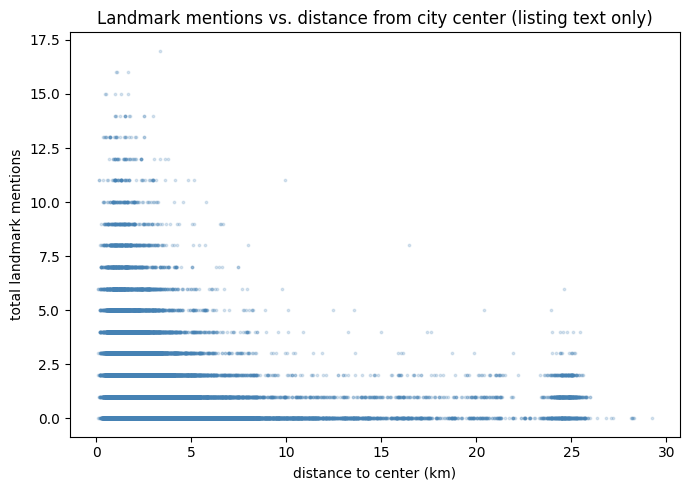

In [67]:
landmark_total = (
    listings_clean['description_landmark_count']
    + listings_clean['host_about_landmark_count']
    + listings_clean['neighborhood_overview_landmark_count']
)

corr_listing_text = listings_clean['distance_to_center_km'].corr(landmark_total)
print(f"corr(distance_to_center_km, listing-text landmark mentions) = {corr_listing_text:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(listings_clean['distance_to_center_km'], landmark_total, s=3, alpha=0.2, color='steelblue')
ax.set_xlabel('distance to center (km)')
ax.set_ylabel('total landmark mentions')
ax.set_title('Landmark mentions vs. distance from city center (listing text only)')
plt.tight_layout()
plt.show()

Landmark mentions correlate negatively with `distance_to_center_km`, giving a content-plausibility check on the gazetteer beyond the earlier prevalence numbers: listings genuinely closer to the reference point mention more landmarks in their own text. The correlation is real but moderate rather than strong, partly because some landmarks in the gazetteer function as day-trip recommendations rather than proximity claims, visible as a secondary cluster of non-zero mentions around 24-26km on the scatter plot. This is treated as an expected property of the corpus rather than noise to remove.

`host_about` prevalence is an order of magnitude lower than `description` or `neighborhood_overview`, consistent with it being personal host biography rather than property marketing text, as landmark mentions there are incidental rather than the field's purpose.

In [68]:
# top-5 landmarks per field, by empirical prevalence
top5_landmarks = {}
for text_col in ['description', 'host_about', 'neighborhood_overview']:
    all_tags = listings_clean[f'{text_col}_landmark_tags'].explode().dropna()
    top5_landmarks[text_col] = all_tags.value_counts().head(5).index.tolist()
    print(f"{text_col} top 5: {top5_landmarks[text_col]}")

description top 5: ['vatican_city', 'colosseum', 'piazza_navona', 'trevi_fountain', 'piazza_di_spagna']
host_about top 5: ['colosseum', 'vatican_city', 'trevi_fountain', 'piazza_navona', 'piazza_di_spagna']
neighborhood_overview top 5: ['colosseum', 'vatican_city', 'piazza_navona', 'trevi_fountain', 'piazza_di_spagna']


In [69]:
for text_col in ['description', 'host_about', 'neighborhood_overview']:
    top5_set = set(top5_landmarks[text_col])
    listings_clean[f'{text_col}_has_top5_landmark'] = listings_clean[f'{text_col}_landmark_tags'].apply(
        lambda tags: int(any(t in top5_set for t in tags))
    )

listings_clean = listings_clean.copy()  # defragment after the column changes above

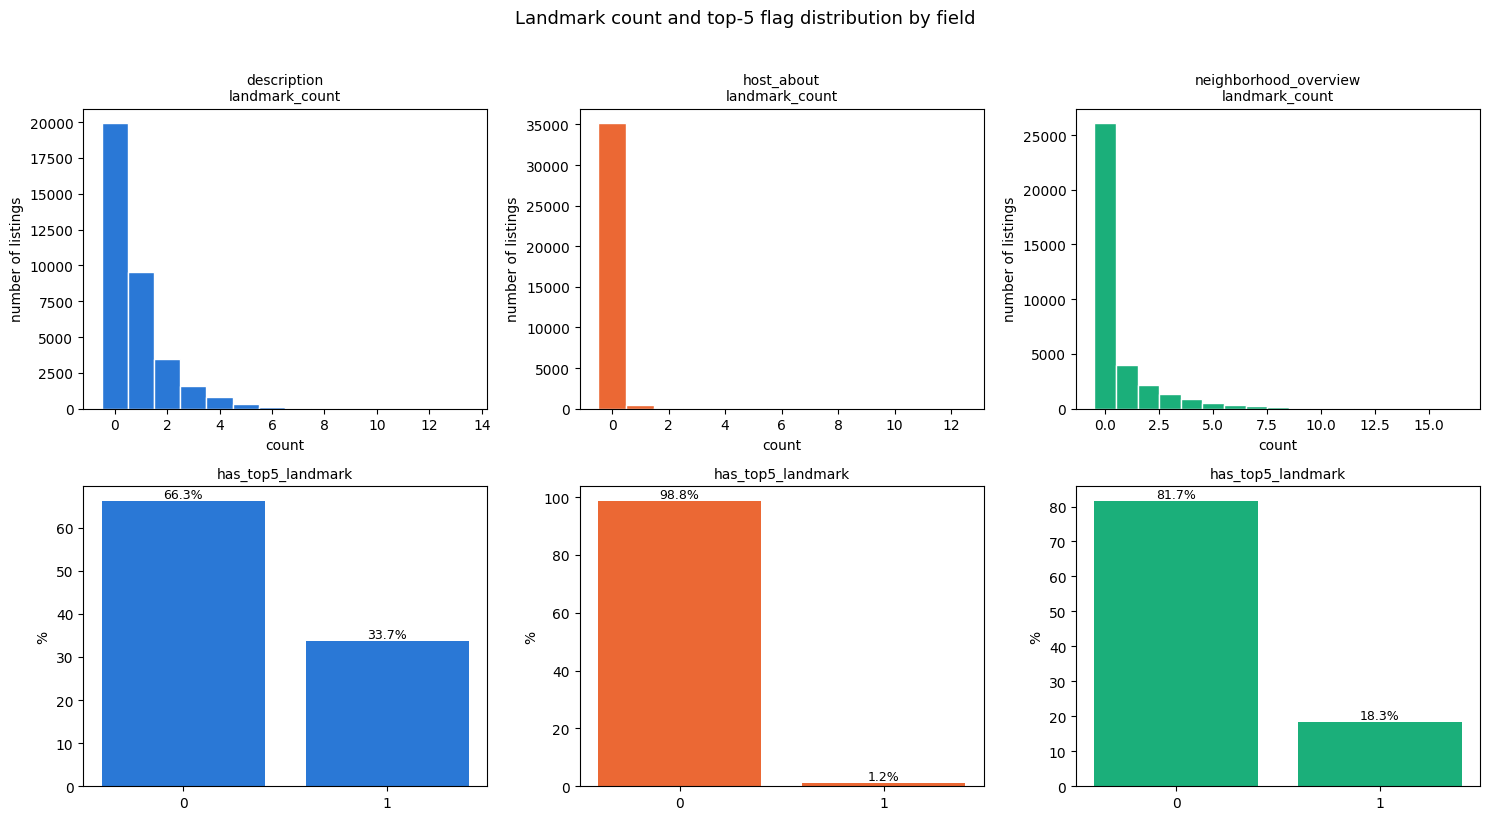

,count,mean,std,min,25%,50%,75%,max
description,35818.0,0.76,1.13,0.0,0.0,0.0,1.0,13.0
host_about,35818.0,0.04,0.35,0.0,0.0,0.0,0.0,12.0
neighborhood_overview,35818.0,0.68,1.47,0.0,0.0,0.0,1.0,16.0


In [70]:
count_binary_fields = ['description', 'host_about', 'neighborhood_overview']
colors = {'description': '#2a78d6', 'host_about': '#eb6834', 'neighborhood_overview': '#1baf7a'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, field in enumerate(count_binary_fields):
    # top row: landmark_count distribution
    counts = listings_clean[f'{field}_landmark_count']
    max_count = int(counts.max())
    axes[0, i].hist(counts, bins=range(0, max_count + 2), align='left', color=colors[field], edgecolor='white')
    axes[0, i].set_title(f'{field}\nlandmark_count', fontsize=10)
    axes[0, i].set_xlabel('count')
    axes[0, i].set_ylabel('number of listings')

    # bottom row: has_top5_landmark binary flag
    pct = listings_clean[f'{field}_has_top5_landmark'].value_counts(normalize=True).mul(100).round(1)
    pct = pct.reindex([0, 1]).fillna(0)
    axes[1, i].bar(['0', '1'], pct.values, color=colors[field])
    axes[1, i].set_title('has_top5_landmark', fontsize=10)
    axes[1, i].set_ylabel('%')
    for j, v in enumerate(pct.values):
        axes[1, i].text(j, v, f'{v}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Landmark count and top-5 flag distribution by field', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    field: listings_clean[f'{field}_landmark_count'].describe()
    for field in count_binary_fields
}).T
display(summary.round(2))

**Observations:**

The `has_top5_landmark` flag mirrors the prevalence pattern already seen for raw landmark tags: present in a third of listings for `description` (33.7%), close to a fifth for `neighborhood_overview` (18.3%), and only 1.2% for `host_about`, which is consistent with the earlier conclusion that landmark mentions in host bios are incidental rather than the field's purpose, this flag carries little separating signal there and is a weak candidate feature for that field specifically.

All three `landmark_count` distributions are heavily right-skewed, with most listings sitting at zero. These are small integer counts, not continuous values, so a log-transform would just compress the tail without fixing the real issue, which is that most of the mass sits at zero. Treating the variable as binary or as a small set of bins is likely to capture the signal better than treating it as continuous.

#### 4.4.2 Corpus-Bootstrapped Tone Lexicons

Six remaining tone categories are word-based lexicons, each describing a single tone:

- **luxury/premium**
- **family-oriented**
- **budget-framing**
- **romantic-framing**
- **authenticity/local-experience**
- **atmosphere**, split into two opposing directions (quiet and lively) since it isn't one tone but a spectrum between two, so each direction needs its own seed set and its own PMI run.

Each lexicon is built from this project's own corpus using 5–8 hand-picked seed words, then expanded with PMI to find words that frequently co-occur with the seeds. Candidate generation is done on English text, with stopwords and Rome place names removed automatically. The final word list for each topic is the seed words plus everything that survives this filter, with any further topic-specific exclusion made explicit in code. The final English lists are then translated into the other five languages rather than running PMI separately for each language.

In [71]:
# NLTK multilingual stopwords
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

LEXICON_LANGS = {'en': 'english', 'it': 'italian', 'fr': 'french', 'es': 'spanish', 'de': 'german', 'ru': 'russian'}
stopword_sets = {code: set(stopwords.words(name)) for code, name in LEXICON_LANGS.items()}

for code, words in stopword_sets.items():
    print(f"{code}: {len(words)} stopwords")

en: 198 stopwords
it: 279 stopwords
fr: 157 stopwords
es: 313 stopwords
de: 232 stopwords
ru: 151 stopwords


In [72]:
# Corpus co-occurrence
from collections import Counter, defaultdict
import math

WINDOW = 5  # words counted as "co-occurring" on each side

def build_cooccurrence(texts, window=WINDOW):
    """Build word frequency + co-occurrence counts over a window, across the corpus."""
    word_counts = Counter()
    cooc_counts = defaultdict(Counter)
    total_tokens = 0
    for text in texts:
        if pd.isna(text) or text == 'unknown':
            continue
        tokens = tokenize_words(text) 
        total_tokens += len(tokens)
        word_counts.update(tokens)
        for i, w in enumerate(tokens):
            start, end = max(0, i - window), min(len(tokens), i + window + 1)
            for j in range(start, end):
                if j != i:
                    cooc_counts[w][tokens[j]] += 1
    return word_counts, cooc_counts, total_tokens

listing_texts = pd.concat([
    listings_clean['description_cleaned'],
    listings_clean['host_about_cleaned'],
    listings_clean['neighborhood_overview_cleaned']
])

word_counts, cooc_counts, total_tokens = build_cooccurrence(listing_texts)
print(f"{total_tokens:,} total tokens, {len(word_counts):,} unique words in corpus")

4,558,289 total tokens, 42,173 unique words in corpus


In [73]:
# PMI candidate generation & filtering
def pmi_candidates(seed_words, word_counts, cooc_counts, total_tokens, min_cooc=5, top_n=50):
    """Rank candidate words by aggregated PMI with the seed set. Words that
    co-occur with the seeds far more than chance, within this specific corpus."""
    scores = Counter()
    for seed in seed_words:
        if seed not in cooc_counts:
            print(f"  warning: seed '{seed}' not found in corpus")
            continue
        p_seed = word_counts[seed] / total_tokens
        for other, cooc in cooc_counts[seed].items():
            if cooc < min_cooc or other in seed_words:
                continue
            p_other = word_counts[other] / total_tokens
            p_joint = cooc / total_tokens
            pmi = math.log(p_joint / (p_seed * p_other))
            scores[other] += pmi
    return scores.most_common(top_n)

# Rome place names
LOCATION_LIKE = {
    'rome', 'roman', 'street', 'streets', 'district', 'heart', 'prati', 'magenta', 'spagna',
    'via', 'piazza', 'trastevere', 'termini', 'vaticano',
}

def filter_candidates(candidates, lang='en', extra_exclude=frozenset()):
    """Drop stopwords (via NLTK) and likely place names from a PMI candidate list."""
    sw = stopword_sets.get(lang, set())
    return [(w, s) for w, s in candidates
            if w not in sw and w not in LOCATION_LIKE and w not in extra_exclude]

Seed words are chosen to be small and unambiguous, rather than large or borderline sets, since the PMI expansion does the work of finding related vocabulary.

In [74]:
# Generate candidates for all seven PMI runs (six topics, atmosphere split into two)
seed_sets = {
    'luxury': {'luxury', 'luxurious', 'upscale', 'elegant', 'premium', 'exquisite'},
    'family': {'family', 'kids', 'children', 'crib'},
    'budget': {'affordable', 'budget', 'cheap', 'inexpensive'},
    'romantic': {'romantic', 'romance', 'honeymoon', 'couples'},
    'authenticity': {'authentic', 'local', 'genuine', 'hidden'},
    'atmosphere_quiet': {'quiet', 'peaceful', 'tranquil', 'calm'},
    'atmosphere_lively': {'lively', 'vibrant', 'bustling', 'nightlife'},
}

pmi_results = {}
for topic, seeds in seed_sets.items():
    candidates = pmi_candidates(seeds, word_counts, cooc_counts, total_tokens)
    filtered = filter_candidates(candidates, lang='en')
    pmi_results[topic] = filtered
    print(f"\n=== {topic} (seeds: {seeds}) ===")
    for word, score in filtered[:30]:
        print(f"  {word}: {score:.2f}")


=== luxury (seeds: {'upscale', 'luxurious', 'exquisite', 'luxury', 'elegant', 'premium'}) ===
  suites: 21.45
  boutiques: 20.14
  rooms: 19.50
  exclusive: 16.76
  apartment: 16.76
  located: 15.81
  hotels: 14.60
  offers: 14.06
  amenities: 13.99
  shopping: 13.87
  jacuzzi: 13.59
  comfort: 13.45
  marble: 13.30
  penthouse: 13.14
  welcome: 12.75
  home: 12.74
  furnishings: 12.68
  stay: 12.38
  suite: 12.35
  like: 12.15
  fabrics: 12.13
  refined: 12.13
  private: 11.57
  retreat: 11.52
  newly: 11.32
  ceilings: 11.14
  sizable: 11.10
  offering: 10.82
  high: 10.76
  modern: 10.70

=== family (seeds: {'kids', 'family', 'crib', 'children'}) ===
  adults: 18.09
  families: 17.22
  group: 15.76
  furry: 15.59
  business: 15.48
  playground: 15.22
  friends: 15.18
  cot: 14.36
  couples: 14.20
  baby: 14.05
  groups: 13.79
  travelers: 13.78
  request: 13.75
  chair: 13.64
  2: 13.42
  upon: 13.07
  adventurers: 13.05
  ideal: 12.48
  add: 12.33
  love: 11.28
  high: 10.83
  two

The final list for each topic is assembled directly from the code's output: seed words plus everything that survived the filter above. If a surviving candidate is clearly off-topic for that specific theme, it is removed through a topic-specific exclusion.

In [75]:
# second-pass filter applied to the candidate lists already generated in pmi_results 
GENERIC_MARKETING_TERMS = {
    'offers', 'offering', 'welcome', 'stay', 'stays', 'located', 'like', 'high', 'home',
    'ideal', 'perfect', 'great', 'suitable', 'designed', 'particularly',
    'provides', 'choices', 'option', 'range', 'accommodation', 'accommodations',
    'available', 'add', 'also', 'upon', 'possibility', 'people', 'little', 'chair',
    'two', '2', 'request', 'something', 'true', 'quick', 'hoping', 'wider', 'face',
    'curious', 'want', 'looking', 'seeking', 'collective', 'imagination', 'known',
    'seek', 'life', 'plenty', 'mass', 'aspects', 'live', 'roman', 'atmosphere',
    'bed', 'love', 'private',
    'yet', 'central', 'area', 'back', 'well', 'quite', 'situated',
    'enjoy', 'space', 'setting', 'neighborhood', 'neighbourhood', 'full',
    'des', 
}

AUDIENCE_ENUMERATION_TERMS = {
    'adults', 'group', 'groups', 'friends', 'travelers', 'solo', 'business',
    'singles', 'adventurers', 'wife',
}

LOCATION_LIKE |= {'nuova', 'luzzi', 'pigneto', 'lorenzo', 'villafranca', 'fiori',}  # Rome street/neighborhood fragments

def second_pass_filter(candidates, extra_exclude=frozenset()):
    """Drop generic marketing filler, audience-enumeration words, extended
    place names, and short tokens from an already-generated candidate list."""
    exclude = GENERIC_MARKETING_TERMS | AUDIENCE_ENUMERATION_TERMS | LOCATION_LIKE | extra_exclude
    return [(w, s) for w, s in candidates if len(w) >= 3 and w not in exclude]

pmi_results_filtered = {topic: second_pass_filter(cands) for topic, cands in pmi_results.items()}

for topic, filtered in pmi_results_filtered.items():
    print(f"\n=== {topic} ({len(filtered)} candidates remain) ===")
    for word, score in filtered[:30]:
        print(f"  {word}: {score:.2f}")


=== luxury (21 candidates remain) ===
  suites: 21.45
  boutiques: 20.14
  rooms: 19.50
  exclusive: 16.76
  apartment: 16.76
  hotels: 14.60
  amenities: 13.99
  shopping: 13.87
  jacuzzi: 13.59
  comfort: 13.45
  marble: 13.30
  penthouse: 13.14
  furnishings: 12.68
  suite: 12.35
  fabrics: 12.13
  refined: 12.13
  retreat: 11.52
  newly: 11.32
  ceilings: 11.14
  sizable: 11.10
  modern: 10.70

=== family (11 candidates remain) ===
  families: 17.22
  furry: 15.59
  playground: 15.22
  cot: 14.36
  couples: 14.20
  baby: 14.05
  couple: 10.60
  single: 9.38
  husband: 9.11
  fun: 9.06
  large: 8.99

=== budget (17 candidates remain) ===
  comfortable: 13.00
  restaurants: 11.74
  artistes: 11.11
  rooms: 9.17
  prices: 9.14
  suburb: 8.27
  dance: 7.87
  hotels: 7.33
  shops: 6.85
  sunday: 6.39
  pubs: 5.86
  drink: 5.79
  price: 5.63
  rent: 5.55
  markets: 5.51
  eat: 5.24
  quality: 5.22

=== romantic (18 candidates remain) ===
  longing: 20.56
  warm: 15.43
  getaway: 11.92
 

In [76]:
def finalize_lexicon(topic, seeds, filtered_candidates, extra_drop=frozenset(), extra_add=frozenset()):
    """Final word set = seeds + second-pass candidates + explicit transplants
    from another topic's drop list, minus explicit topic-specific drops.
    Set union throughout, so a transplanted word already present causes no duplicate."""
    candidate_words = {w for w, score in filtered_candidates}
    final_words = (seeds | candidate_words | extra_add) - extra_drop
    if extra_drop:
        print(f"{topic}: dropped: {extra_drop}")
    if extra_add:
        print(f"{topic}: transplanted in: {extra_add}")
    return final_words

topic_extra_drop = {
    'luxury': {
        # generic accommodation nouns
        'rooms', 'apartment', 'hotels', 'amenities', 'shopping',
        # freshness/size claims
        'newly', 'sizable', 'modern',
        # too generic, also present in romantic and atmosphere_quiet
        'retreat',
    },
    'family': {
        # anti-signal
        'couples', 'couple',
        # marital status, not about child-friendliness
        'husband',
        # highly ambiguous
        'single',
        # false positive (pet-related)
        'furry',
        # too generic
        'fun', 'large',
    },
    'budget': {
        # generic amenity/location nouns
        'restaurants', 'rooms', 'hotels', 'shops', 'suburb',
        # one-off noise
        'artistes', 'dance', 'sunday', 'pubs', 'drink',
        # too generic / conceptually in tension with budget positioning
        'eat', 'quality',
        # reserved for 'authenticity', where it's a much stronger signal
        'markets',
    },
    'romantic': {
        # reserved for 'family' / 'authenticity'
        'family', 'families', 'experience',
        # too generic on their own
        'trips', 'spend', 'forests', 'represents', 'total', 'small', 'young', 'vacation',
        # synonym of 'solo'
        'lone',
        # too generic to discriminate
        'retreat',
    },
    'authenticity': {
        # generic filler
        'still',
        # too generic / high false-positive risk
        'real', 'side',
        # already atmosphere_lively's own seed word
        'vibrant',
        # leans social-scene rather than authenticity specifically
        'cafes',
        # generic commerce noun, not distinctly "authentic"
        'restaurants',
    },
    'atmosphere_quiet': {
        # doesn't refer to the atmosphere
        'secure', 'safe', 'crime',
        # belongs to luxury tone, not calmness
        'stylish',
        # belongs to authenticity tone
        'elegant', 'charming',
        # generic accommodation noun, not a calmness signal
        'apartment',
        # conceptually backwards for "quiet"
        'centrally',
        # appears in both quiet and lively & doesn't discriminate between the two
        'night',
    },
    'atmosphere_lively': {
        # authentic/local are literally authenticity's own seed words
        'authentic', 'local', 'traditional', 'history',
        # conceptually a quiet/cozy word
        'nestled',
        # word fragment, not a real token
        'multi',
        # too generic on their own
        'day', 'part', 'famous',
        # ambiguous with wealth/luxury tone
        'rich',
        # reserved for 'authenticity'
        'food', 'trattorias', 'cobblestone', 'markets',
    },
}

topic_extra_add = {
    # transplanted from atmosphere_quiet's drop list
    'luxury': {'stylish'},
    # transplanted from atmosphere_lively's drop list
    'authenticity': {'traditional', 'history'},
}

lexicons_en = {}
for topic, seeds in seed_sets.items():
    lexicons_en[topic] = finalize_lexicon(
        topic, seeds, pmi_results_filtered[topic],
        extra_drop=topic_extra_drop.get(topic, frozenset()),
        extra_add=topic_extra_add.get(topic, frozenset())
    )

for topic, words in lexicons_en.items():
    print(f"\n{topic} ({len(words)} words): {sorted(words)}")

luxury: dropped: {'modern', 'shopping', 'amenities', 'sizable', 'hotels', 'retreat', 'apartment', 'newly', 'rooms'}
luxury: transplanted in: {'stylish'}
family: dropped: {'large', 'fun', 'husband', 'couple', 'couples', 'furry', 'single'}
budget: dropped: {'drink', 'quality', 'shops', 'markets', 'hotels', 'suburb', 'restaurants', 'dance', 'eat', 'pubs', 'artistes', 'sunday', 'rooms'}
romantic: dropped: {'spend', 'small', 'represents', 'vacation', 'experience', 'families', 'trips', 'forests', 'retreat', 'young', 'family', 'lone', 'total'}
authenticity: dropped: {'vibrant', 'real', 'still', 'cafes', 'side', 'restaurants'}
authenticity: transplanted in: {'history', 'traditional'}
atmosphere_quiet: dropped: {'safe', 'charming', 'night', 'stylish', 'centrally', 'crime', 'elegant', 'apartment', 'secure'}
atmosphere_lively: dropped: {'food', 'trattorias', 'history', 'cobblestone', 'authentic', 'famous', 'rich', 'markets', 'traditional', 'nestled', 'local', 'part', 'multi', 'day'}

luxury (19 w

In [77]:
summary_rows = []
for topic in seed_sets:
    summary_rows.append({
        'topic': topic,
        'seed_words': len(seed_sets[topic]),
        'pmi_candidates_survived': len(pmi_results_filtered[topic]),
        'dropped_as_off_topic': len(topic_extra_drop.get(topic, set())),
        'transplanted_in': len(topic_extra_add.get(topic, set())),
        'final_lexicon_size': len(lexicons_en[topic]),
    })

lexicon_summary = pd.DataFrame(summary_rows).set_index('topic')
display(lexicon_summary)

,seed_words,pmi_candidates_survived,dropped_as_off_topic,transplanted_in,final_lexicon_size
topic,,,,,
luxury,6,21,9,1,19
family,4,11,7,0,8
budget,4,17,13,0,8
romantic,4,18,13,0,9
authenticity,4,30,6,2,30
atmosphere_quiet,4,21,9,0,16
atmosphere_lively,4,31,14,0,21


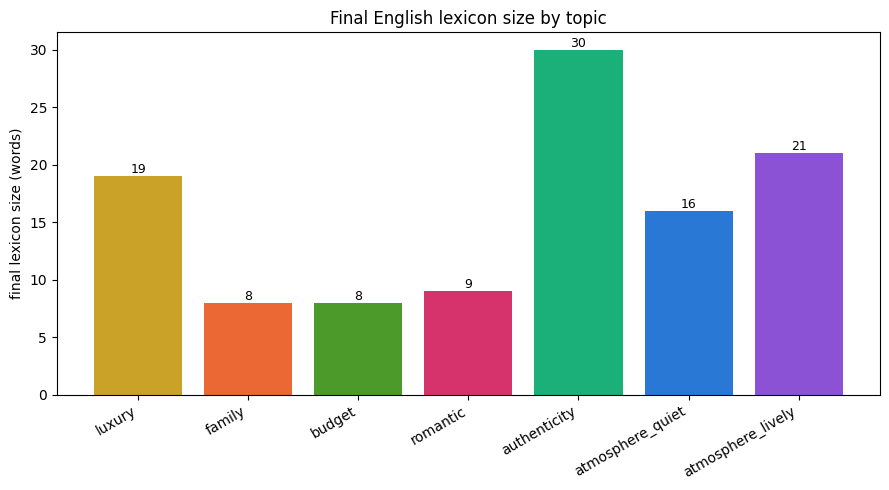

In [78]:
colors_topics = {
    'luxury': '#c9a227', 'family': '#eb6834', 'budget': '#4c9a2a', 'romantic': '#d6336c',
    'authenticity': '#1baf7a', 'atmosphere_quiet': '#2a78d6', 'atmosphere_lively': '#8c52d6',
}

fig, ax = plt.subplots(figsize=(9, 5))
topics_order = list(lexicons_en.keys())
sizes = [len(lexicons_en[t]) for t in topics_order]
bars = ax.bar(topics_order, sizes, color=[colors_topics[t] for t in topics_order])
ax.set_ylabel('final lexicon size (words)')
ax.set_title('Final English lexicon size by topic')
plt.xticks(rotation=30, ha='right')
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, size, str(size), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Observations:**

Lexicon size varies a lot across topics, and this variation is informative.
- `authenticity` (30 words) and `atmosphere_lively` (21 words) yield rich vocabularies, consistent with these being themes hosts elaborate on at length.
- `budget` and `family` are the thinnest (8 words each). For budget, this is a plausible property of the corpus as price is already a separate structured field, so hosts may have little reason to restate affordability in prose the way they elaborate on style or neighborhood character. Thin lexicons are accepted as a finding.

A small number of words are deliberately kept in more than one lexicon:
- `boutiques` in both `luxury` and `atmosphere_lively`
- `getaway` in both `romantic` and `atmosphere_quiet`
- `restaurants` kept natively in `atmosphere_lively` while dropped elsewhere as too generic.

These reflect genuine shared vocabulary between related but distinct tones.

Translation of the seven finalized English lexicons into Italian, French, Spanish, German, and Russian is done via a single structured LLM prompt rather than manual translation, made because the tone lexicons cover idiomatic sensitive vocabulary.

In [79]:
# API key loaded from config/.env, never hardcoded or committed — see config/.env.example
from dotenv import load_dotenv
from openai import OpenAI, OpenAIError, RateLimitError, AuthenticationError, APIError
import os
import json

load_dotenv('../config/.env')
api_key = os.environ.get('OPENAI_API_KEY')

if api_key is None:
    raise ValueError("OPENAI_API_KEY not found — check config/.env in the project root")

client = OpenAI(api_key=api_key)

Client initialized


In [80]:
api_exceptions = {
    RateLimitError: "Quota exceeded.",
    AuthenticationError: "Invalid API key.",
    APIError: "Problem with OpenAI server.",
    OpenAIError: "OpenAI returned an error.",
}

TRANSLATION_TEMPERATURE = 0   # deterministic sampling — no creative variation wanted for a lexicon translation

def build_translation_prompt(lexicons):
    """Build the translation prompt directly from the finalized lexicons_en dict,
    rather than pasting word lists by hand — avoids transcription drift if the
    lexicons change upstream."""
    header = (
        "Translate the following English word lists into Italian, French, Spanish, "
        "German, and Russian. Each list groups words expressing a specific tone in "
        "Airbnb listing marketing copy (descriptions written by hosts to attract "
        "guests) — translate for natural equivalent tone/register in real estate "
        "marketing, not literal dictionary translation.\n"
        "Rules:\n"
        "- Use only real, standard dictionary words for each language — never invent "
        "or approximate a spelling.\n"
        "- Return every word in lowercase, even where standard orthography would "
        "capitalize it (e.g. German nouns).\n"
        "- Preserve the same word order as the English input list for each topic.\n"
        "Return ONLY valid JSON, no commentary, in this exact structure:\n"
        '{"topic_name": {"it": [...], "fr": [...], "es": [...], "de": [...], "ru": [...]}, ...}\n\n'
    )
    body = "\n".join(f"{topic}: {sorted(words)}" for topic, words in lexicons.items())
    return header + body


def strip_json_fences(text):
    """Strip a ```json ... ``` markdown wrapper if the model added one,
    despite being asked for raw JSON."""
    text = text.strip()
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text.strip()

def translate_lexicons(client, lexicons, model="gpt-3.5-turbo"):
    prompt = build_translation_prompt(lexicons)
    raw_text = None
    try:
        response = client.responses.create(model=model, input=prompt, temperature=TRANSLATION_TEMPERATURE)
        raw_text = strip_json_fences(response.output_text)
        return json.loads(raw_text)
    except tuple(api_exceptions.keys()) as e:
        print(api_exceptions[type(e)])
        return None
    except json.JSONDecodeError as e:
        print(f"Response wasn't valid JSON: {e}")
        if raw_text:
            print(raw_text)
        return None

In [81]:
lexicons_multilingual = translate_lexicons(client, lexicons_en)

if lexicons_multilingual:
    for topic, langs in lexicons_multilingual.items():
        print(f"\n{topic}:")
        for lang, words in langs.items():
            print(f"  {lang}: {words}")


luxury:
  it: ['boutique', 'soffitti', 'comfort', 'elegante', 'esclusivo', 'squisto', 'stoffe', 'arredamento', 'jacuzzi', 'lusso', 'lusso', 'marmo', 'attico', 'premium', 'raffinato', 'di stile', 'suite', 'suite', 'di lusso']
  fr: ['boutiques', 'plafonds', 'confort', 'élégant', 'exclusif', 'exquis', 'tissus', 'ameublement', 'jacuzzi', 'luxueux', 'luxe', 'marbre', 'penthouse', 'premium', 'raffiné', 'élégant', 'suite', 'suites', 'haut de gamme']
  es: ['boutiques', 'techos', 'comodidad', 'elegante', 'exclusivo', 'exquisito', 'telas', 'mobiliario', 'jacuzzi', 'lujoso', 'lujo', 'mármol', 'ático', 'premium', 'refinado', 'elegante', 'suite', 'suites', 'de lujo']
  de: ['boutiquen', 'decken', 'komfort', 'elegant', 'exklusiv', 'exquisit', 'stoffe', 'einrichtung', 'jacuzzi', 'luxuriös', 'luxus', 'marmor', 'dachgeschoss', 'premium', 'raffiniert', 'stilvoll', 'suite', 'suiten', 'gehoben']
  ru: ['бутики', 'потолки', 'комфорт', 'элегантный', 'эксклюзивный', 'изысканный', 'ткани', 'обстановка', 'д

Raw API output is deduplicated per language via set conversion and applied the same way personalization markers were: word density per 100 words, per text field. `unavailable` is used whenever the language isn't covered by a lexicon, the field has no text, or the source language itself is undetermined, so a listing that genuinely scores zero on a tone stays distinguishable from one where the metric couldn't be computed at all.

In [82]:
def build_multilingual_lexicon_set(lexicons_multilingual, lexicons_en):
    """Convert raw (possibly duplicated) API translation lists into deduplicated,
    lowercased sets per language, plus the English list itself for consistency."""
    result = {}
    for topic, lang_dict in lexicons_multilingual.items():
        result[topic] = {'en': {w.lower() for w in lexicons_en[topic]}}
        for lang, words in lang_dict.items():
            result[topic][lang] = {w.lower() for w in words}
    return result

tone_lexicons_multilingual = build_multilingual_lexicon_set(lexicons_multilingual, lexicons_en)

for topic, langs in tone_lexicons_multilingual.items():
    print(f"{topic}: " + ", ".join(f"{lang}={len(words)}" for lang, words in langs.items()))

luxury: en=19, it=17, fr=18, es=18, de=19, ru=16
family: en=8, it=7, fr=7, es=6, de=7, ru=6
budget: en=8, it=6, fr=6, es=7, de=7, ru=7
romantic: en=9, it=8, fr=8, es=9, de=8, ru=9
authenticity: en=30, it=30, fr=29, es=30, de=29, ru=30
atmosphere_quiet: en=16, it=14, fr=14, es=15, de=13, ru=12
atmosphere_lively: en=21, it=19, fr=18, es=17, de=17, ru=17


In [83]:
LEXICON_LANGS_COVERED = set(LEXICON_LANGS.keys())  # en, it, fr, es, de, ru

def compute_all_tone_densities(text, lang, lexicons, covered_langs=LEXICON_LANGS_COVERED):
    """Compute density for every tone topic in a single pass — tokenizes the
    text once instead of once per topic, which matters given the review corpus
    is large and uncapped in this phase. Returns {topic: (density, method)}."""
    unavailable = {topic: (np.nan, 'unavailable') for topic in lexicons}
    if pd.isna(text) or text == 'unknown' or lang in ('too_short', 'unknown') or lang not in covered_langs:
        return unavailable

    tokens = tokenize_words(text)
    word_count = len(tokens)
    if word_count == 0:
        return unavailable

    results = {}
    for topic, lexicon in lexicons.items():
        if lang not in lexicon:
            results[topic] = (np.nan, 'unavailable')
            continue
        match_count = sum(1 for t in tokens if t in lexicon[lang])
        results[topic] = (round(match_count / word_count * 100, 3), 'computed')
    return results

In [84]:
# listing text fields
tone_field_lang_map = {
    'description_cleaned': 'description_lang',
    'host_about_cleaned': 'host_about_lang',
    'neighborhood_overview_cleaned': 'neighborhood_overview_lang',
}

for text_col, lang_col in tone_field_lang_map.items():
    prefix = text_col.replace('_cleaned', '')
    all_results = [
        compute_all_tone_densities(t, l, tone_lexicons_multilingual)
        for t, l in zip(listings_clean[text_col], listings_clean[lang_col])
    ]
    for topic in tone_lexicons_multilingual:
        listings_clean[f'{prefix}_{topic}_density'] = [r[topic][0] for r in all_results]
        listings_clean[f'{prefix}_{topic}_method'] = [r[topic][1] for r in all_results]

listings_clean = listings_clean.copy()  # defragment after many column insertions

In [85]:
# reviews over the full corpus
review_all_results = [
    compute_all_tone_densities(t, l, tone_lexicons_multilingual)
    for t, l in zip(
        reviews_clean.loc[substantive_mask, 'comments_clean'],
        reviews_clean.loc[substantive_mask, 'review_lang']
    )
]

review_tone_df = pd.DataFrame({'listing_id': reviews_clean.loc[substantive_mask, 'listing_id'].values})
for topic in tone_lexicons_multilingual:
    review_tone_df[f'{topic}_density'] = [r[topic][0] for r in review_all_results]

review_tone_agg = review_tone_df.groupby('listing_id').mean()
review_tone_agg.columns = [f'review_{c}' for c in review_tone_agg.columns]

existing_cols = [c for c in review_tone_agg.columns if c in listings_clean.columns]
if existing_cols:
    listings_clean = listings_clean.drop(columns=existing_cols)
listings_clean = listings_clean.merge(review_tone_agg, left_on='id', right_index=True, how='left')

In [86]:
# summary table — coverage + distribution stats, one row per (topic, field)
tone_topics = list(tone_lexicons_multilingual.keys())
tone_fields = ['description', 'host_about', 'neighborhood_overview', 'review']
n_total = len(listings_clean)

summary_rows = []
for topic in tone_topics:
    for field in tone_fields:
        data = listings_clean[f'{field}_{topic}_density'].dropna()
        summary_rows.append({
            'topic': topic, 'field': field,
            'n_computed': len(data),
            'coverage_pct': round(len(data) / n_total * 100, 1),
            'mean': round(data.mean(), 3) if len(data) else np.nan,
            'median': round(data.median(), 3) if len(data) else np.nan,
            'std': round(data.std(), 3) if len(data) else np.nan,
            'max': round(data.max(), 3) if len(data) else np.nan,
        })

tone_density_summary = pd.DataFrame(summary_rows)
display(tone_density_summary)

,topic,field,n_computed,coverage_pct,mean,median,std,max
0,luxury,description,34854,97.3,1.076,0.000,1.911,33.333
1,luxury,host_about,15279,42.7,0.180,0.000,0.945,20.000
2,luxury,neighborhood_overview,16442,45.9,0.314,0.000,1.002,25.000
3,luxury,review,30286,84.6,0.100,0.021,0.310,14.286
4,family,description,34854,97.3,0.343,0.000,1.140,20.000
5,family,host_about,15279,42.7,0.225,0.000,0.929,20.000
6,family,neighborhood_overview,16442,45.9,0.068,0.000,0.378,11.765
7,family,review,30286,84.6,0.133,0.011,0.306,8.333
8,budget,description,34854,97.3,0.330,0.000,0.876,25.000
9,budget,host_about,15279,42.7,0.101,0.000,0.479,14.286


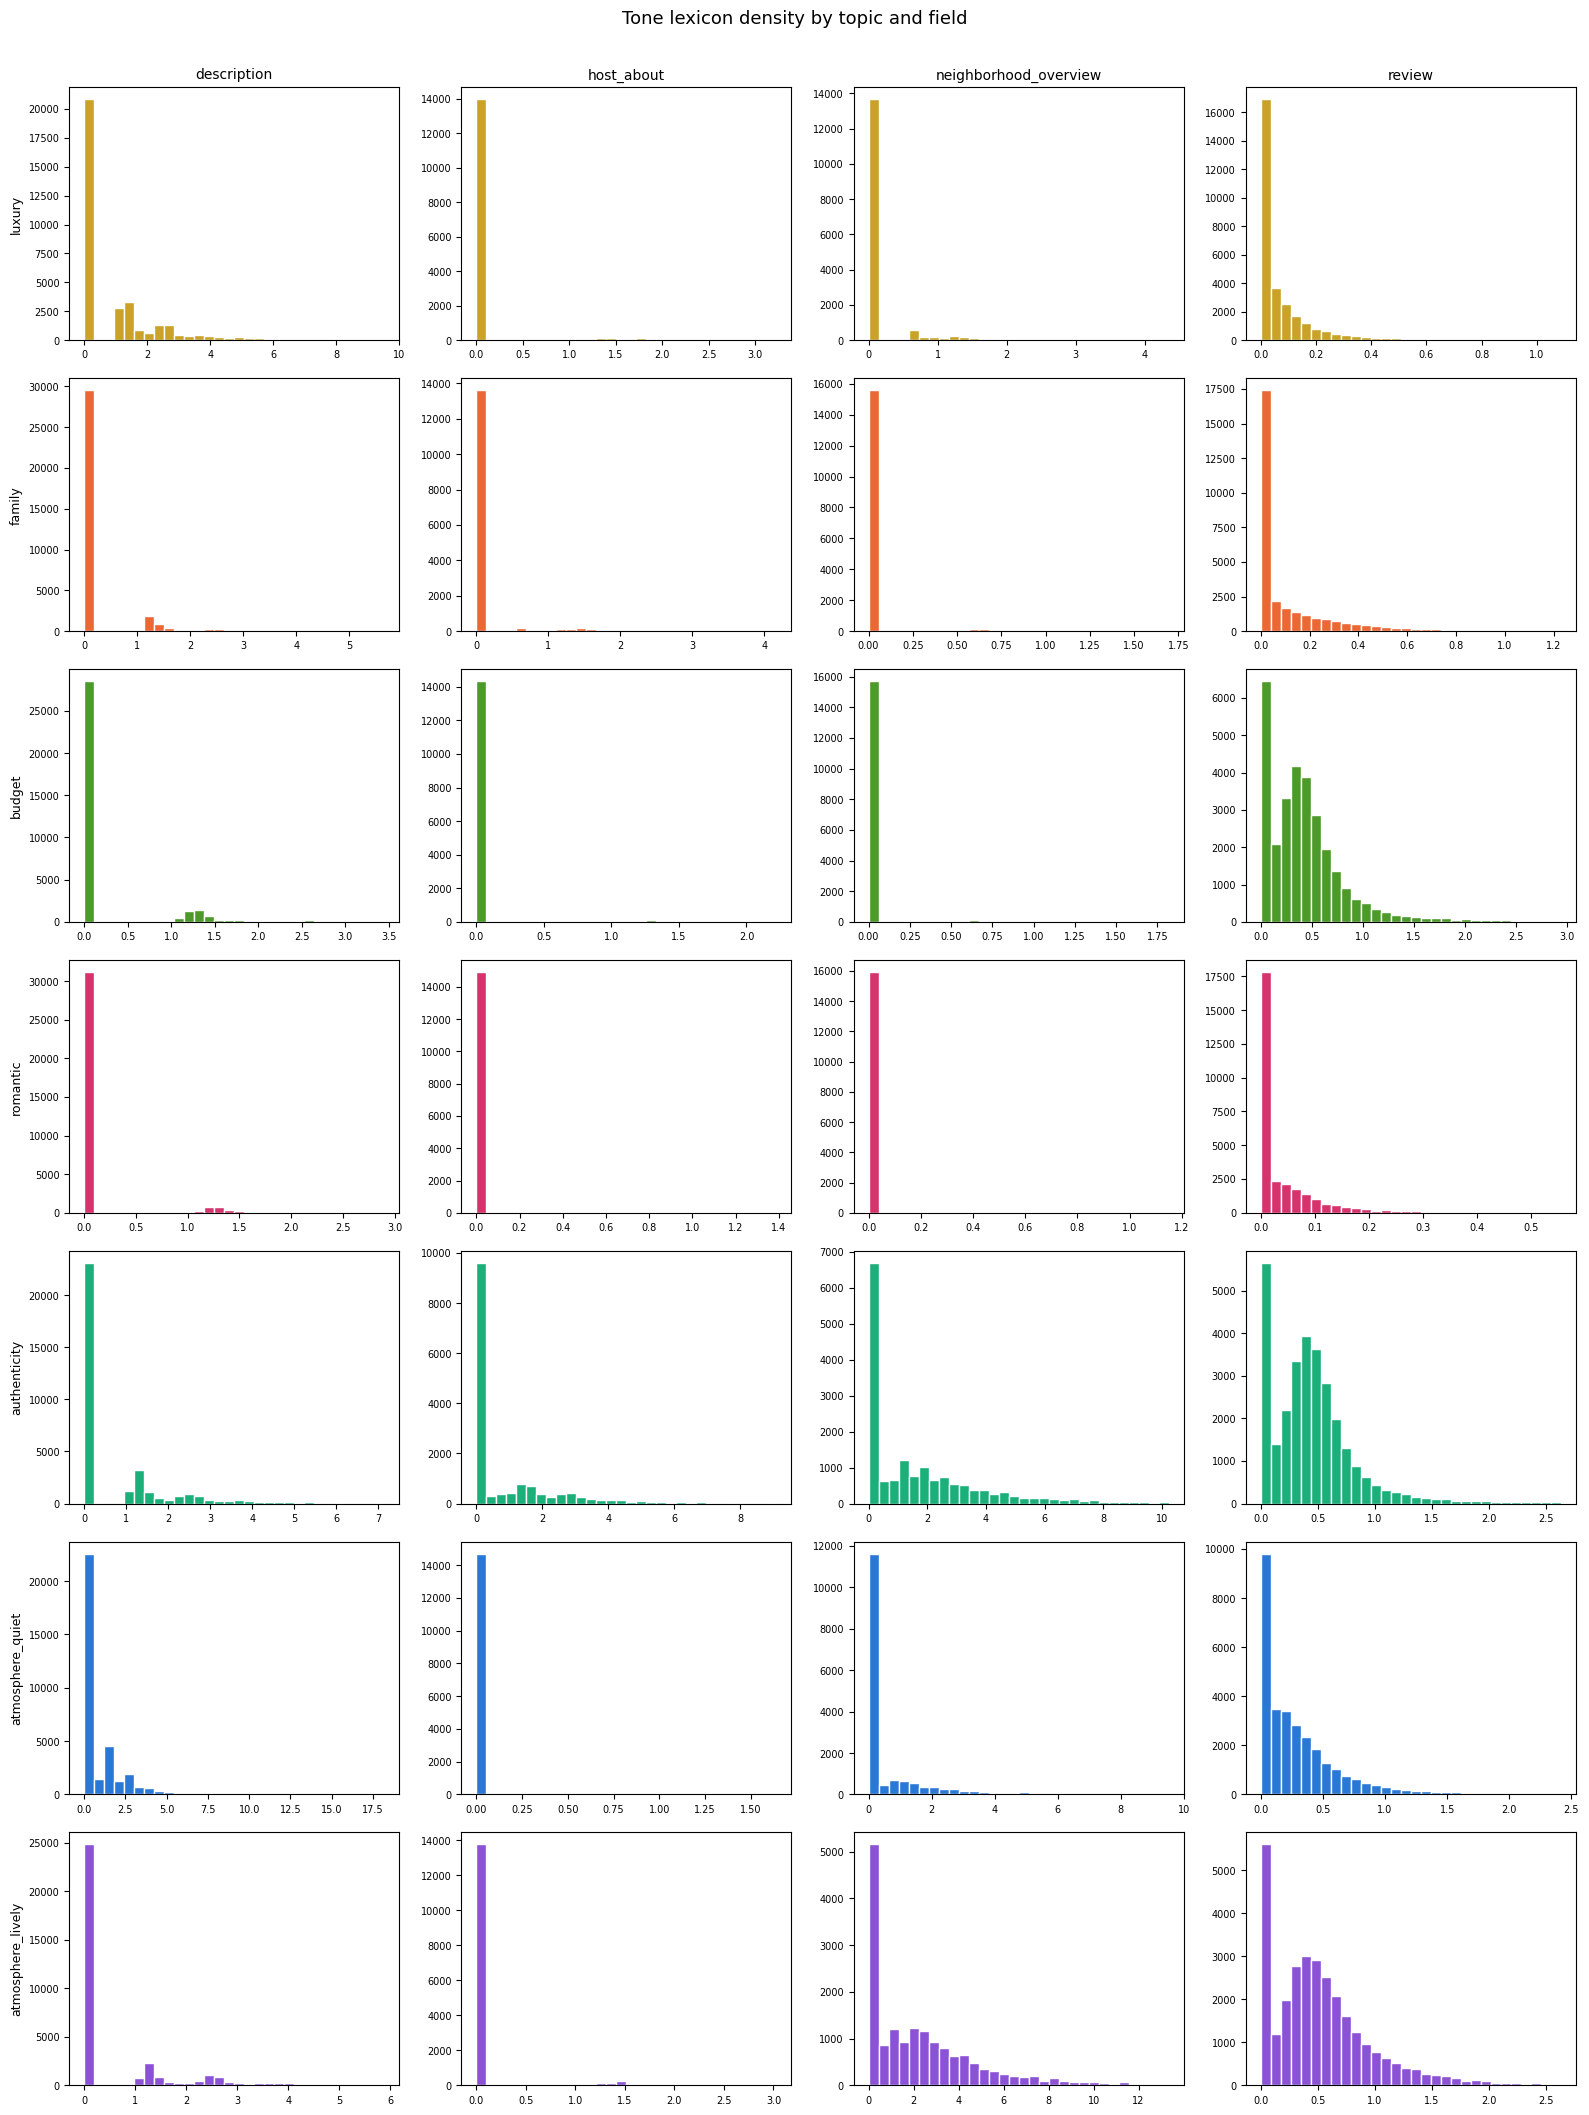

In [87]:
# distributions 
fig, axes = plt.subplots(len(tone_topics), len(tone_fields), figsize=(16, 3 * len(tone_topics)))

for row, topic in enumerate(tone_topics):
    for col, field in enumerate(tone_fields):
        ax = axes[row, col]
        data = listings_clean[f'{field}_{topic}_density'].dropna()
        if len(data) == 0:
            ax.set_visible(False)
            continue
        upper = data.quantile(0.99)
        ax.hist(data[data <= upper], bins=30, color=colors_topics[topic], edgecolor='white')
        if row == 0:
            ax.set_title(field, fontsize=10)
        if col == 0:
            ax.set_ylabel(topic, fontsize=9)
        ax.tick_params(labelsize=7)

plt.suptitle('Tone lexicon density by topic and field', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

**Observations:**
Zero-inflation dominates almost every cell, with one clear and consistent exception: `review` densities have non-zero medians for most topics, which is the averaging-over-many-reviews effect. `neighborhood_overview` for `authenticity` and `atmosphere_lively` are the only listing-text fields with a non-zero median, meaning this vocabulary is the norm rather than the exception when hosts describe their neighborhood.

Relative topic strength differs meaningfully by field. In `description`, `atmosphere_quiet` and `luxury` lead, with `family`, `budget`, and `romantic` an order of magnitude lower, which is consistent with descriptions being primarily about the property's character and style rather than who it suits. `neighborhood_overview` is dominated by `atmosphere_lively` and `authenticity`, matching their role as the two largest lexicons. `host_about` stands out for a different reason: `authenticity` is higher there than in `description` itself, and clearly higher than `luxury`/`family`/`budget`/`romantic` in the same field, so hosts appear more likely to describe themselves personally as passionate about "authentic" local life than to make bio-level luxury or family-friendly claims.

The most notable asymmetry is `budget`: density in `review` is roughly 1.5-5x higher than in any host-authored field. Hosts rarely frame affordability explicitly in their own text, plausibly because price is already a separate, visible structured field, but guests comment on value and comfort more freely in retrospect. `romantic` is the weakest signal across every field without exception, consistent with it having the thinnest finalized lexicon of the six tone topics.

Extreme max values for `atmosphere_quiet` & `authenticity` in `description` reflect the same short-text density artifact already documented for MTLD and personalization markers, as a handful of matches in a very short text inflate the ratio.

#### 4.4.3 Host Professionalism and Transport Accessibility

**Host professionalism**

Unlike the six tone lexicons, this one isn't built from hand-picked seed words expanded via PMI. This section instead lets the corpus itself surface the vocabulary, rather than guessing it in advance.

The method is differential frequency analysis: contrasting word usage between listings with many host listings (`calculated_host_listings_count >= 10`) and single-listing hosts (`== 1`). The threshold is a subjective choice and 10 was picked to keep the "multi-host" group clearly distinct from the ambiguous middle zone without shrinking it too far into the sparse tail. Differential frequency already ranks every word in the vocabulary by how strongly it distinguishes the two groups, which is a stronger starting point than co-occurrence with a handful of chosen seeds.

In [88]:
def differential_word_frequency(texts_a, texts_b, min_count=10, top_n=50):
    """Rank words by how disproportionately they appear in corpus A vs corpus B —
    fully automatic, no seed words: lets the data surface distinguishing
    vocabulary rather than guessing it in advance."""
    counts_a, counts_b = Counter(), Counter()
    total_a = total_b = 0
    for text in texts_a:
        if pd.isna(text) or text == 'unknown':
            continue
        tokens = tokenize_words(text)
        counts_a.update(tokens)
        total_a += len(tokens)
    for text in texts_b:
        if pd.isna(text) or text == 'unknown':
            continue
        tokens = tokenize_words(text)
        counts_b.update(tokens)
        total_b += len(tokens)

    scores = {}
    for word, count_a in counts_a.items():
        if count_a < min_count:
            continue
        freq_a = count_a / total_a
        freq_b = (counts_b.get(word, 0) + 1) / total_b  # +1 smoothing, avoids div-by-zero
        scores[word] = math.log(freq_a / freq_b)

    return sorted(scores.items(), key=lambda x: -x[1])[:top_n]

THRESHOLD = 10
multi_host_mask = listings_clean['calculated_host_listings_count'] >= THRESHOLD
single_host_mask = listings_clean['calculated_host_listings_count'] == 1

print(f"multi-host group: {multi_host_mask.sum():,} listings")
print(f"single-host group: {single_host_mask.sum():,} listings")

multi-host group: 5,848 listings
single-host group: 14,720 listings


In [89]:
for field in ['host_about_cleaned', 'description_cleaned', 'neighborhood_overview_cleaned']:
    print(f"\n{'='*20} {field} {'='*20}")
    candidates = differential_word_frequency(
        listings_clean.loc[multi_host_mask, field],
        listings_clean.loc[single_host_mask, field]
    )
    filtered = second_pass_filter(candidates)
    for word, score in filtered[:30]:
        print(f"{word}: {score:.2f}")


==================== host_about_cleaned ====================
lerede: 4.77
youcomehere: 4.77
importo: 4.52
canone: 4.52
contratto: 4.52
documenti: 4.52
versa: 4.43
cranny: 4.43
confined: 4.43
lamp: 4.43
shape: 4.43
ricomprende: 4.33
corrispettivo: 4.33
tali: 4.33
importi: 4.33
dettagliati: 4.33
genereranno: 4.33
distinti: 4.33
contabili: 4.33
regions: 4.24
nostromondo: 4.07
flavours: 4.07
recharge: 4.07
pray: 4.07
regioni: 4.07
lughi: 4.07
convissuto: 4.07
cervo: 4.07
prega: 4.07
flatinrome: 4.06

==================== description_cleaned ====================
residency: 4.73
particularity: 4.36
bedline: 4.32
buddyrent: 4.29
prompt: 4.03
1br: 3.99
coils: 3.93
textiles: 3.82
crew: 3.76
ahead: 3.73
chain: 3.70
modernism: 3.63
cunabu: 3.63
unlock: 3.63
hoteliers: 3.47
minibars: 3.47
crispi: 3.39
stuck: 3.39
corsini: 3.39
bang: 3.39
poles: 3.29
suityrhome: 3.29
rituals: 3.29
mechanical: 3.29
favorites: 3.26
liter: 3.19
housekeeping: 3.07
hop: 2.86
mineral: 2.86
virtual: 2.84

===============

The signal turned out to be field-specific rather than a single unified tone, so each field is treated on its own merits rather than forced into one lexicon:

- **`host_about` — kept.** Surfaces Italian legal/rental-contract vocabulary and general corporate/operational Italian. A genuine, interpretable professionalism signal.
- **`description` — kept, different register.** Surfaces English hospitality-operational vocabulary ("hoteliers", "housekeeping", "minibars"), self-check-in language, which is distinct from `host_about`'s legal framing, but clearly on-topic.
- **`neighborhood_overview` — dropped.** What distinguished multi-host listings here was ornate marketing prose ("wanderlust", "mesmerized", "unveil", "meander"), not professionalism. It is a different phenomenon, not the tone this section is trying to capture. Forcing a lexicon out of this field would mean measuring the wrong thing.

Within the two kept fields, Rome street/place names that leaked into the raw candidates are removed by the existing `LOCATION_LIKE` filter (already applied via `second_pass_filter` before the candidates are sent to the API), while company brand names are left for the model to discard during selection, per the prompt's explicit instruction to treat brand names as noise.

In [90]:
def build_select_translate_prompt(field_candidates):
    header = (
        "For each candidate word list below, select ONLY the words that plausibly signal HOST PROFESSIONALISM / AGENCY-STYLE FRAMING in an Airbnb host bio or listing description "
        "— legal/rental-contract language, corporate/operational vocabulary, or hospitality-operational terms (housekeeping, check-in systems, hotel-style amenities). Discard words that are noise: decor nouns, "
        "place names, brand names, or otherwise unrelated to professionalism/agency framing.\n"
        "Then translate the selected words into English, Italian, French, Spanish, German, and Russian as appropriate (skip the source language itself, since it's already given).\n"
        "When the task or inputs are ambiguous, ask targeted clarification questions before proceeding rather than guessing.\n"
        "Return ONLY valid JSON, no commentary, structured as:\n"
        '{"field_label": {"en": [...], "it": [...], "fr": [...], "es": [...], "de": [...], "ru": [...]}}\n'
        "Ensure the response exactly matches this JSON shape, uses only the listed language keys, and contains arrays of strings only. If no words qualify for a field_label, "
        "return an empty array for each language key under that field_label.\n\n"
    )
    body = ""
    for field_label, (source_lang, words) in field_candidates.items():
        body += f"{field_label} (source language: {source_lang}): {words}\n"
    return header + body

def select_and_translate(client, field_candidates, model="gpt-3.5-turbo"):
    prompt = build_select_translate_prompt(field_candidates)
    raw_text = None
    try:
        response = client.responses.create(model=model, input=prompt, temperature=0)
        raw_text = strip_json_fences(response.output_text)
        parsed = json.loads(raw_text)
        missing_fields = set(field_candidates.keys()) - set(parsed.keys())
        if missing_fields:
            print(f"WARNING: model dropped expected field(s): {missing_fields}")
        return parsed
    except tuple(api_exceptions.keys()) as e:
        print(api_exceptions[type(e)])
        return None
    except json.JSONDecodeError as e:
        print(f"Response wasn't valid JSON: {e}")
        if raw_text:
            print(raw_text)
        return None

In [91]:
# same raw candidates we already looked at manually
host_about_raw = [w for w, s in second_pass_filter(
    differential_word_frequency(listings_clean.loc[multi_host_mask, 'host_about_cleaned'],
                                  listings_clean.loc[single_host_mask, 'host_about_cleaned'])
)][:40]
description_raw = [w for w, s in second_pass_filter(
    differential_word_frequency(listings_clean.loc[multi_host_mask, 'description_cleaned'],
                                  listings_clean.loc[single_host_mask, 'description_cleaned'])
)][:40]

print("host_about candidates sent:", host_about_raw)
print("description candidates sent:", description_raw)

field_candidates = {
    'host_about': ('Italian', host_about_raw),
    'description': ('English', description_raw),
}

prof_results = select_and_translate(client, field_candidates)
prof_results

host_about candidates sent: ['lerede', 'youcomehere', 'importo', 'canone', 'contratto', 'documenti', 'versa', 'cranny', 'confined', 'lamp', 'shape', 'ricomprende', 'corrispettivo', 'tali', 'importi', 'dettagliati', 'genereranno', 'distinti', 'contabili', 'regions', 'nostromondo', 'flavours', 'recharge', 'pray', 'regioni', 'lughi', 'convissuto', 'cervo', 'prega', 'flatinrome', 'mybnb', 'halldis', 'strategici', 'pianificazione', 'guidandoli', 'elfaro', 'unità', 'distinguerci', 'innovativi', 'patrizio']
description candidates sent: ['residency', 'particularity', 'bedline', 'buddyrent', 'prompt', '1br', 'coils', 'textiles', 'crew', 'ahead', 'chain', 'modernism', 'cunabu', 'unlock', 'hoteliers', 'minibars', 'crispi', 'stuck', 'corsini', 'bang', 'poles', 'suityrhome', 'rituals', 'mechanical', 'favorites', 'liter', 'housekeeping', 'hop', 'mineral', 'virtual', 'thermostat', 'list', '328', 'ludus', 'magnus', 'rave', 'consoli', 'guesthouse', 'paint', 'informations']


{'host_about': {'en': ['amount',
   'rental',
   'contract',
   'documents',
   'pay',
   'compensation',
   'details',
   'accountable',
   'strategic',
   'planning',
   'innovative'],
  'it': ['importo',
   'canone',
   'contratto',
   'documenti',
   'versa',
   'corrispettivo',
   'dettagliati',
   'contabili',
   'strategici',
   'innovativi'],
  'fr': ['montant',
   'location',
   'contrat',
   'documents',
   'payer',
   'compensation',
   'détails',
   'responsable',
   'stratégique',
   'innovant'],
  'es': ['cantidad',
   'alquiler',
   'contrato',
   'documentos',
   'pago',
   'compensación',
   'detalles',
   'responsable',
   'estratégico',
   'innovador'],
  'de': ['Betrag',
   'Miete',
   'Vertrag',
   'Dokumente',
   'zahlen',
   'Vergütung',
   'Details',
   'verantwortlich',
   'strategisch',
   'innovativ'],
  'ru': ['сумма',
   'аренда',
   'контракт',
   'документы',
   'оплата',
   'компенсация',
   'детали',
   'ответственный',
   'стратегический',
   'инноваци

Selection and translation are done in a single LLM call: for each field's candidate word list, the model selects only words that plausibly signal host professionalism / agency-style framing, then translates the selected words into the other five languages. The prompt requires the output to preserve both field labels exactly, with an empty array rather than omission if no words qualify for a field, which this keeps `host_about` and `description` as two distinct lexicons rather than letting them collapse into one.

In [92]:
professionalism_lexicons = {
    field: {lang: {w.lower() for w in words} for lang, words in lang_dict.items()}
    for field, lang_dict in prof_results.items()
}

Because the API call isn't perfectly deterministic even at `temperature=0`, a defensive check removes two specific words (`modernism`, `thermostat`) from the `description` lexicon if a re-run reintroduces them. This is treated as a deliberate, bounded exception to "accept the model's output as-is": a known risk of re-running a non-deterministic API call is mitigated explicitly, rather than left to chance on whether the same words happen to reappear.

In [93]:
DESCRIPTION_EXCLUDE_EN = {'modernism', 'thermostat'}

en_words = prof_results['description']['en']
exclude_indices = {i for i, w in enumerate(en_words) if w in DESCRIPTION_EXCLUDE_EN}

if exclude_indices:
    print(f"removing words at positions {exclude_indices} across all languages: "
          f"{[en_words[i] for i in exclude_indices]}")

professionalism_lexicons['description'] = {
    lang: {w.lower() for i, w in enumerate(words) if i not in exclude_indices}
    for lang, words in prof_results['description'].items()
}

for lang, words in professionalism_lexicons['description'].items():
    print(f"description/{lang}: {sorted(words)}")

removing words at positions {2} across all languages: ['modernism']
description/en: ['hoteliers', 'housekeeping', 'minibars', 'prompt', 'residency']
description/it: ['albergatori', 'minibar', 'pronto', 'pulizia', 'residenza']
description/fr: ['hôteliers', 'minibars', 'ménage', 'rapide', 'résidence']
description/es: ['hoteleros', 'limpieza', 'minibares', 'residencia', 'rápido']
description/de: ['hoteliers', 'housekeeping', 'minibars', 'prompt', 'residenz']
description/ru: ['prompt', 'гостиничные', 'минибары', 'резиденция', 'уборка']


In [94]:
# apply density per field, using its own dedicated lexicon
for field, lang_col in [('host_about', 'host_about_lang'), ('description', 'description_lang')]:
    single_lexicon = {'professionalism': professionalism_lexicons[field]}
    results = [
        compute_all_tone_densities(t, l, single_lexicon)['professionalism']
        for t, l in zip(listings_clean[f'{field}_cleaned'], listings_clean[lang_col])
    ]
    listings_clean[f'{field}_professionalism_density'] = [r[0] for r in results]

listings_clean = listings_clean.copy()

In [95]:
# independent cross-check against pronoun-based signal
corr_self = listings_clean['host_about_professionalism_density'].corr(listings_clean['host_about_self_ref_density'])
corr_we = listings_clean['host_about_professionalism_density'].corr(listings_clean['host_about_we_ref_density'])
print(f"corr(professionalism, self_ref) = {corr_self:.3f}")
print(f"corr(professionalism, we_ref)   = {corr_we:.3f}")

corr(professionalism, self_ref) = -0.091
corr(professionalism, we_ref)   = -0.032


In [96]:
# summary table 
prof_fields = ['host_about', 'description']
n_total = len(listings_clean)

summary_rows = []
for field in prof_fields:
    data = listings_clean[f'{field}_professionalism_density'].dropna()
    summary_rows.append({
        'field': field,
        'n_computed': len(data),
        'coverage_pct': round(len(data) / n_total * 100, 1),
        'mean': round(data.mean(), 3) if len(data) else np.nan,
        'median': round(data.median(), 3) if len(data) else np.nan,
        'std': round(data.std(), 3) if len(data) else np.nan,
        'max': round(data.max(), 3) if len(data) else np.nan,
    })

professionalism_summary = pd.DataFrame(summary_rows)
display(professionalism_summary)

,field,n_computed,coverage_pct,mean,median,std,max
0,host_about,15279,42.7,0.126,0.0,1.013,14.286
1,description,34854,97.3,0.005,0.0,0.116,4.478


bucket sizes:
host_listings_bucket
1        14720
2         4817
3-4       5563
5-6       2865
7-9       2005
10-16     2069
17-34     2199
35+       1580
Name: id, dtype: int64


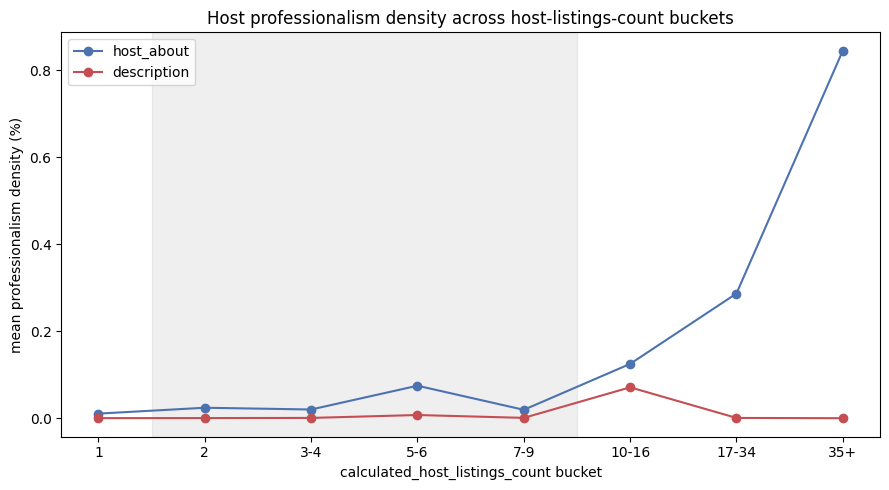

In [97]:
listing_bins = [1, 2, 3, 5, 7, 10, 17, 35, 200]
bin_labels = ['1', '2', '3-4', '5-6', '7-9', '10-16', '17-34', '35+']
listings_clean['host_listings_bucket'] = pd.cut(
    listings_clean['calculated_host_listings_count'], bins=listing_bins, labels=bin_labels, right=False
)

bucket_means = listings_clean.groupby('host_listings_bucket', observed=True)[
    ['host_about_professionalism_density', 'description_professionalism_density']
].mean()
bucket_counts = listings_clean.groupby('host_listings_bucket', observed=True)['id'].count()

print("bucket sizes:")
print(bucket_counts)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(bucket_means))
ax.plot(x, bucket_means['host_about_professionalism_density'], marker='o', label='host_about', color='#4c72b0')
ax.plot(x, bucket_means['description_professionalism_density'], marker='o', label='description', color='#c44e52')
ax.set_xticks(x)
ax.set_xticklabels(bucket_means.index)
ax.set_xlabel('calculated_host_listings_count bucket')
ax.set_ylabel('mean professionalism density (%)')
ax.set_title('Host professionalism density across host-listings-count buckets')
ax.axvspan(0.5, 4.5, color='gray', alpha=0.12)  # 2-9 listings: untouched by lexicon construction
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**

- `host_about` trend is directionally consistent with the hypothesis: mean density rises from 0.011% at single-host listings to 0.845% at 35+ listings — but not monotonic through the untouched middle zone (2-9 listings, shaded on the visualization). Dips at "3-4" and "7-9" sit below their neighboring buckets. These buckets are reasonably large (5,563 and 2,005 listings respectively), so the dips reflect genuine noise in the middle of the distribution rather than a handful of outliers, and the overall upward trend from the low single digits to nearly 1% only becomes clearly visible in the upper buckets (10-16 and above), where corporate/legal vocabulary is presumably more consistently present.

- `description` trend does not hold up under the same scrutiny. Its one visible peak at "10-16" sits between two buckets at essentially zero, which is not a trend but an isolated spike, most likely driven by a small number of listings using words like "hoteliers" or "housekeeping" within an otherwise very rare vocabulary. The bucket-level check does not support treating `description_professionalism_density` as a reliable multi-host signal on its own.

The independent cross-check against the pronoun-based signal is weak in both directions: `self_ref_density` shows the expected negative correlation but only weakly, and `we_ref_density` shows the opposite sign from what was hypothesized, also weakly (-0.032, expected positive). Unlike the landmark gazetteer's cross-check against `distance_to_center_km`, which confirmed the method cleanly, this validation does not provide confident independent support.

Taken together, `host_about_professionalism_density` is kept as a candidate feature with a directionally plausible but noisy validation, consistent with its higher coverage and stronger mean (0.126% vs. 0.006%), as this may be the field where the underlying signal (Italian legal/rental-contract vocabulary) is more distinctive and more consistently present. `description_professionalism_density` is kept as a candidate as well, but its validation gives no real evidence it behaves as intended; it is flagged as a weak, unconfirmed feature to be reassessed at validation stage.

**Transport/Accessibility**

Unlike the corpus-bootstrapped tone lexicons, transport accessibility is expressed through short phrases ("walking distance", "steps to the metro") rather than single words, so it is closer in mechanism to the landmark gazetteer (regex phrase matching) though there is no external authoritative source comparable to Wikidata for this theme, so the candidate phrase list is hand-written rather than sourced. As with every hand-written or externally-sourced input in this project, candidates are checked against actual corpus prevalence before being finalized, rather than trusted on the strength of intuition alone.

`review` is included alongside `description` and `neighborhood_overview`. A guest confirming ease of access is validating the same underlying claim a host makes in listing text, not a different phenomenon. `host_about` is excluded, as personal host biography, off-topic for a proximity claim, the same reasoning that excluded it from the landmark gazetteer.

In [98]:
transport_candidates_en = [
    'walking distance', 'steps from', 'steps to', 'minutes from', 'minutes to',
    'well connected', 'easily reachable', 'close to the metro', 'metro station',
    'bus stop', 'train station', 'tram stop', 'public transport', 'public transportation',
    'easy access to', 'short walk',
]
print(f"{len(transport_candidates_en)} candidate phrases")

16 candidate phrases


In [99]:
def check_phrase_prevalence(phrases, texts):
    """English-only prevalence check before spending a translation call —
    same discipline used for the landmark gazetteer candidates."""
    combined = texts.fillna('').str.lower()
    counts = {}
    for phrase in phrases:
        pattern = r'\b' + re.escape(phrase) + r'\b'
        counts[phrase] = combined.str.contains(pattern, regex=True, na=False).sum()
    return pd.Series(counts).sort_values(ascending=False)

transport_fields = ['description_cleaned', 'neighborhood_overview_cleaned']
combined_listing_text = listings_clean[transport_fields].fillna('').agg(' '.join, axis=1)

prevalence = check_phrase_prevalence(transport_candidates_en, combined_listing_text)
print(f"prevalence in listing text ({len(listings_clean):,} listings):")
display(prevalence)

prevalence in listing text (35,818 listings):


steps from               3744
walking distance         3497
well connected           3238
minutes from             2990
public transport         2490
short walk               2490
metro station            2082
train station            1566
bus stop                 1042
easy access to            911
public transportation     572
minutes to                429
easily reachable          377
tram stop                 189
close to the metro        160
steps to                   99
dtype: int64

In [100]:
def build_transport_translation_prompt(phrases):
    header = (
        "Translate the following English phrases into Italian, French, Spanish, German, "
        "and Russian. Each phrase describes proximity/accessibility to transport in Airbnb "
        "listing marketing copy (descriptions and neighborhood overviews written by hosts, "
        "and guest reviews confirming ease of access). Translate for natural equivalent "
        "phrasing as it would actually appear in real estate listings or reviews in each "
        "language — not literal word-for-word translation.\n"
        "Rules:\n"
        "- Return every phrase in lowercase.\n"
        "- Preserve the same phrase order as the English input list.\n"
        "- Each phrase may translate to a short natural phrase, not necessarily the same word count.\n"
        "Return ONLY valid JSON, no commentary, in this exact structure:\n"
        '{"it": [...], "fr": [...], "es": [...], "de": [...], "ru": [...]}\n\n'
    )
    body = f"phrases: {phrases}"
    return header + body

def translate_transport_phrases(client, phrases, model="gpt-3.5-turbo"):
    prompt = build_transport_translation_prompt(phrases)
    raw_text = None
    try:
        response = client.responses.create(model=model, input=prompt, temperature=0)
        raw_text = strip_json_fences(response.output_text)
        parsed = json.loads(raw_text)
        expected_langs = {'it', 'fr', 'es', 'de', 'ru'}
        missing_langs = expected_langs - set(parsed.keys())
        if missing_langs:
            print(f"WARNING: missing language(s) in response: {missing_langs}")
        for lang, translated in parsed.items():
            if len(translated) != len(phrases):
                print(f"WARNING: {lang} has {len(translated)} phrases, expected {len(phrases)} — check ordering")
        return parsed
    except tuple(api_exceptions.keys()) as e:
        print(api_exceptions[type(e)])
        return None
    except json.JSONDecodeError as e:
        print(f"Response wasn't valid JSON: {e}")
        if raw_text:
            print(raw_text)
        return None

In [101]:
transport_translated = translate_transport_phrases(client, transport_candidates_en)
transport_translated

{'it': ['a pochi passi',
  'a due passi',
  'a pochi minuti',
  'a pochi minuti',
  'a pochi minuti',
  'ben collegato',
  'facilmente raggiungibile',
  'vicino alla metro',
  'stazione della metro',
  "fermata dell'autobus",
  'stazione ferroviaria',
  'fermata del tram',
  'trasporto pubblico',
  'trasporti pubblici',
  'facile accesso a',
  'passeggiata breve'],
 'fr': ['à distance de marche',
  'à quelques pas de',
  'à quelques pas de',
  'à quelques minutes de',
  'à quelques minutes de',
  'bien desservi',
  'facilement accessible',
  'proche du métro',
  'station de métro',
  'arrêt de bus',
  'gare',
  'arrêt de tram',
  'transport en commun',
  'transports en commun',
  'accès facile à',
  'courte marche'],
 'es': ['a poca distancia',
  'a unos pasos de',
  'a unos pasos de',
  'a pocos minutos de',
  'a pocos minutos de',
  'bien conectado',
  'fácilmente accesible',
  'cerca del metro',
  'estación de metro',
  'parada de autobús',
  'estación de tren',
  'parada de tranvía

In [102]:
transport_lexicon = {'en': transport_candidates_en}
for lang, phrases in transport_translated.items():
    transport_lexicon[lang] = phrases

for lang, phrases in transport_lexicon.items():
    print(f"{lang}: {len(phrases)} phrases")

en: 16 phrases
it: 16 phrases
fr: 16 phrases
es: 16 phrases
de: 16 phrases
ru: 16 phrases


Several phrases translate identically across languages, e.g. "minutes from"/"minutes to" collapse to the same wording in every target language, and "public transport"/"public transportation" do the same in Spanish and Russian (though Italian, French, and German keep them distinct). This is expected rather than a translation error: these English pairs don't have a natural distinct equivalent in most of these languages, so duplicating rather than inventing an artificial difference is the more faithful translation.

One exception was found on manual review: Italian's translation of "steps to" drifted into the "minutes" category instead of "steps". Since "steps from" already covers the same concept correctly in Italian, this is left uncorrected rather than patched by hand.

In [103]:
def compute_phrase_density(text, lang, phrase_lexicon, covered_langs=LEXICON_LANGS_COVERED):
    """Density of phrase matches per 100 words — same unavailable/NaN convention
    as compute_all_tone_densities, but matching multi-word phrases via regex
    instead of single-token set membership."""
    if pd.isna(text) or text == 'unknown' or lang in ('too_short', 'unknown') or lang not in covered_langs or lang not in phrase_lexicon:
        return np.nan, 'unavailable'

    text_lower = str(text).lower()
    tokens = tokenize_words(text)
    word_count = len(tokens)
    if word_count == 0:
        return np.nan, 'unavailable'

    match_count = sum(
        len(re.findall(r'\b' + re.escape(phrase) + r'\b', text_lower))
        for phrase in phrase_lexicon[lang]
    )
    return round(match_count / word_count * 100, 3), 'computed'

In [104]:
# listing fields
for field, lang_col in [('description', 'description_lang'), ('neighborhood_overview', 'neighborhood_overview_lang')]:
    results = [
        compute_phrase_density(t, l, transport_lexicon)
        for t, l in zip(listings_clean[f'{field}_cleaned'], listings_clean[lang_col])
    ]
    listings_clean[f'{field}_transport_density'] = [r[0] for r in results]

listings_clean = listings_clean.copy()

In [105]:
# reviews aggregated to listing level
review_transport_density = reviews_clean.loc[substantive_mask, 'comments_clean'].combine(
    reviews_clean.loc[substantive_mask, 'review_lang'],
    lambda t, l: compute_phrase_density(t, l, transport_lexicon)[0]
)

review_transport_df = pd.DataFrame({
    'listing_id': reviews_clean.loc[substantive_mask, 'listing_id'].values,
    'transport_density': review_transport_density
})
review_transport_agg = review_transport_df.groupby('listing_id')['transport_density'].mean()
review_transport_agg.name = 'review_transport_density'

existing_col = 'review_transport_density' in listings_clean.columns
if existing_col:
    listings_clean = listings_clean.drop(columns='review_transport_density')
listings_clean = listings_clean.merge(review_transport_agg, left_on='id', right_index=True, how='left')

In [106]:
# summary table
transport_fields = ['description', 'neighborhood_overview', 'review']
n_total = len(listings_clean)

summary_rows = []
for field in transport_fields:
    data = listings_clean[f'{field}_transport_density'].dropna()
    summary_rows.append({
        'field': field,
        'n_computed': len(data),
        'coverage_pct': round(len(data) / n_total * 100, 1),
        'mean': round(data.mean(), 3) if len(data) else np.nan,
        'median': round(data.median(), 3) if len(data) else np.nan,
        'std': round(data.std(), 3) if len(data) else np.nan,
        'max': round(data.max(), 3) if len(data) else np.nan,
    })

transport_summary = pd.DataFrame(summary_rows)
display(transport_summary)

,field,n_computed,coverage_pct,mean,median,std,max
0,description,34854,97.3,0.892,0.000,1.375,16.667
1,neighborhood_overview,16442,45.9,0.814,0.000,1.572,21.053
2,review,30286,84.6,0.438,0.341,0.554,12.879


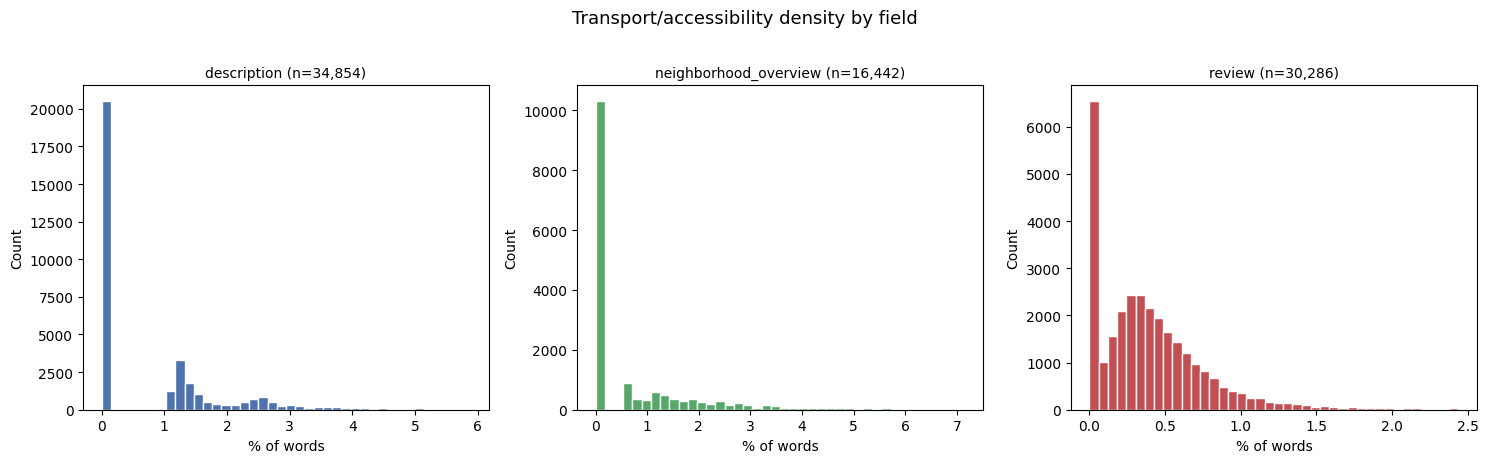

In [107]:
# distribution visualization
colors_transport = {'description': '#4c72b0', 'neighborhood_overview': '#55a868', 'review': '#c44e52'}

fig, axes = plt.subplots(1, len(transport_fields), figsize=(15, 4.5))

for ax, field in zip(axes, transport_fields):
    data = listings_clean[f'{field}_transport_density'].dropna()
    upper = data.quantile(0.99)
    ax.hist(data[data <= upper], bins=40, color=colors_transport[field], edgecolor='white')
    ax.set_title(f'{field} (n={len(data):,})', fontsize=10)
    ax.set_xlabel('% of words')
    ax.set_ylabel('Count')

plt.suptitle('Transport/accessibility density by field', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

bucket sizes:
distance_bucket
0-1      3888
1-2      8664
2-3      7801
3-5      8553
5-8      4001
8-12     1235
12-20     795
20+       881
Name: id, dtype: int64


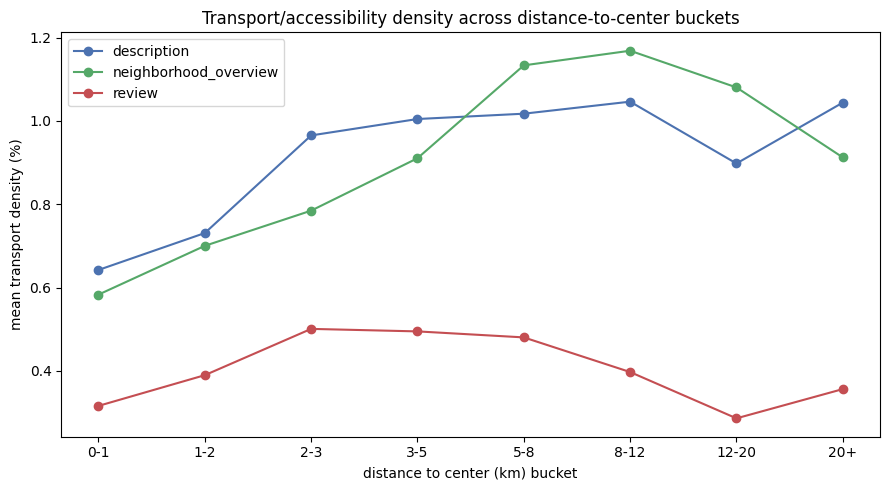

corr(distance_to_center_km, description_transport_density) = 0.053
corr(distance_to_center_km, neighborhood_overview_transport_density) = 0.067
corr(distance_to_center_km, review_transport_density) = -0.004


In [108]:
distance_bins = [0, 1, 2, 3, 5, 8, 12, 20, 100]
distance_bin_labels = ['0-1', '1-2', '2-3', '3-5', '5-8', '8-12', '12-20', '20+']
listings_clean['distance_bucket'] = pd.cut(
    listings_clean['distance_to_center_km'], bins=distance_bins, labels=distance_bin_labels, right=False
)

bucket_means_transport = listings_clean.groupby('distance_bucket', observed=True)[
    ['description_transport_density', 'neighborhood_overview_transport_density', 'review_transport_density']
].mean()
bucket_counts_transport = listings_clean.groupby('distance_bucket', observed=True)['id'].count()

print("bucket sizes:")
print(bucket_counts_transport)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(bucket_means_transport))
for field in transport_fields:
    col = f'{field}_transport_density'
    ax.plot(x, bucket_means_transport[col], marker='o', label=field, color=colors_transport[field])
ax.set_xticks(x)
ax.set_xticklabels(bucket_means_transport.index)
ax.set_xlabel('distance to center (km) bucket')
ax.set_ylabel('mean transport density (%)')
ax.set_title('Transport/accessibility density across distance-to-center buckets')
ax.legend()
plt.tight_layout()
plt.show()

# numeric correlation alongside the visual trend
for field in transport_fields:
    corr = listings_clean['distance_to_center_km'].corr(listings_clean[f'{field}_transport_density'])
    print(f"corr(distance_to_center_km, {field}_transport_density) = {corr:.3f}")

**Observations:**

The line chart reveals a real pattern that the correlation coefficients understate.
- `description` and `neighborhood_overview` transport density rises steadily with distance from the center. This makes sense as a distinct phenomenon: a listing next to the Colosseum has no need to reassure a guest about proximity, but a listing 10km out has a real concern to address, and "well connected"/"steps from the metro" framing is a plausible way hosts compensate for that distance rather than a statement about actual transit density.
- `review` behaves differently again, staying essentially flat across all buckets, which means guests mention transport about as often regardless of how far the listing is from the center, consistent with these mentions being more incidental and factual than persuasive.

The near-zero Pearson correlations don't contradict the visible trend so much as fail to capture it: over 80% of listings fall within 0-5km of the center, where the relationship is clearest and most consistent, while the sparse 8km+ tail flattens out and adds noise a linear correlation is sensitive to. Combined with substantial within-bucket spread, this is a case where the bucketed trend is more informative than the single summary statistic.

### 4.5 NLP Feature Checkpoint

Before moving to the heavier, model-based methods in the next notebook, this section takes stock of everything built in sections 4.1–4.4.3: a registry separating real feature candidates from scaffolding columns (diagnostic `_method`/`_tags` columns, never meant to be model inputs), an audit of zero-inflation and skew across every candidate, and light transformations, such as binary flags for severely zero-inflated variables, log1p versions for right-skewed ones.

#### 4.5.1 Feature Audit

In [141]:
LISTING_FIELDS = ['description', 'host_about', 'neighborhood_overview']
ALL_FIELDS = LISTING_FIELDS + ['review']

candidate_features = []
scaffolding_columns = []

# 4.2 missingness flags 
candidate_features += ['has_name', 'has_description', 'has_neighborhood_overview',
                        'has_host_about']

# 4.3.1 length & punctuation
for field in ALL_FIELDS:
    for metric in ['char_count', 'word_count', 'sentence_count', 'punct_density',
                   'exclaim_count', 'question_count']:
        candidate_features.append(f'{field}_{metric}')

# 4.3.2 readability
for field in ALL_FIELDS:
    candidate_features.append(f'{field}_readability')
for field in LISTING_FIELDS:
    scaffolding_columns.append(f'{field}_readability_method')

# 4.3.3 vocabulary richness
for field in ALL_FIELDS:
    candidate_features.append(f'{field}_mtld')
for field in LISTING_FIELDS:
    scaffolding_columns.append(f'{field}_vocab_method')

# 4.3.4 personalization
for field in ALL_FIELDS:
    for metric in ['self_ref_density', 'we_ref_density', 'direct_address_density']:
        candidate_features.append(f'{field}_{metric}')
for field in LISTING_FIELDS:
    scaffolding_columns.append(f'{field}_personalization_method')

# 4.4.1 landmark gazetteer
for field in LISTING_FIELDS:
    candidate_features.append(f'{field}_landmark_count')
    candidate_features.append(f'{field}_has_top5_landmark')
    scaffolding_columns.append(f'{field}_landmark_tags')

# 4.4.2 tone lexicons
tone_topics = ['luxury', 'family', 'budget', 'romantic', 'authenticity',
               'atmosphere_quiet', 'atmosphere_lively']
for field in ALL_FIELDS:
    for topic in tone_topics:
        candidate_features.append(f'{field}_{topic}_density')
for field in LISTING_FIELDS:
    for topic in tone_topics:
        scaffolding_columns.append(f'{field}_{topic}_method')

# 4.4.3 host professionalism + transport
candidate_features += ['host_about_professionalism_density', 'description_professionalism_density']
candidate_features += ['description_transport_density', 'neighborhood_overview_transport_density',
                        'review_transport_density']

scaffolding_columns += ['host_listings_bucket', 'distance_bucket']

missing_candidates = [c for c in candidate_features if c not in listings_clean.columns]
missing_scaffolding = [c for c in scaffolding_columns if c not in listings_clean.columns]
print(f"{len(candidate_features)} candidate features")
print(f"{len(scaffolding_columns)} scaffolding columns")
if missing_candidates:
    print("missing candidates:", missing_candidates)
if missing_scaffolding:
    print("missing scaffolding:", missing_scaffolding)

87 candidate features
35 scaffolding columns


In [142]:
scaffolding_columns

['description_readability_method',
 'host_about_readability_method',
 'neighborhood_overview_readability_method',
 'description_vocab_method',
 'host_about_vocab_method',
 'neighborhood_overview_vocab_method',
 'description_personalization_method',
 'host_about_personalization_method',
 'neighborhood_overview_personalization_method',
 'description_landmark_tags',
 'host_about_landmark_tags',
 'neighborhood_overview_landmark_tags',
 'description_luxury_method',
 'description_family_method',
 'description_budget_method',
 'description_romantic_method',
 'description_authenticity_method',
 'description_atmosphere_quiet_method',
 'description_atmosphere_lively_method',
 'host_about_luxury_method',
 'host_about_family_method',
 'host_about_budget_method',
 'host_about_romantic_method',
 'host_about_authenticity_method',
 'host_about_atmosphere_quiet_method',
 'host_about_atmosphere_lively_method',
 'neighborhood_overview_luxury_method',
 'neighborhood_overview_family_method',
 'neighborhood

In [117]:
from scipy.stats import skew as scipy_skew

def is_binary_column(series):
    """A column is already binary if every non-null value is 0 or 1 —
    neither log-transform nor binarization applies to it."""
    return set(series.dropna().unique()).issubset({0, 1})

ZERO_INFLATION_STRONG = 90    
ZERO_INFLATION_MODERATE = 75  

audit_rows = []
for col in candidate_features:
    if col not in listings_clean.columns:
        continue
    data = listings_clean[col].dropna()
    if len(data) == 0:
        audit_rows.append({'column': col, 'n': 0, 'pct_zero': np.nan, 'skew': np.nan, 'flag': 'EMPTY'})
        continue

    sk = round(scipy_skew(data), 2) if data.nunique() > 1 else 0
    pct_zero = round((data == 0).mean() * 100, 1)

    if is_binary_column(data):
        flag = 'leave as-is'
    elif pct_zero >= ZERO_INFLATION_STRONG:
        flag = 'zero_inflated (strong)'
    elif pct_zero >= ZERO_INFLATION_MODERATE:
        flag = 'zero_inflated (moderate)'
    elif abs(sk) > 1:
        flag = 'skewed'
    else:
        flag = 'leave as-is'

    audit_rows.append({'column': col, 'n': len(data), 'pct_zero': pct_zero, 'skew': sk, 'flag': flag})

feature_audit = pd.DataFrame(audit_rows)
pd.set_option('display.max_rows', None)
display(feature_audit.sort_values('pct_zero', ascending=False))
print(feature_audit['flag'].value_counts())

,column,n,pct_zero,skew,flag
83,description_professionalism_density,34854,99.8,29.37,zero_inflated (strong)
21,neighborhood_overview_question_count,16640,99.1,15.29,zero_inflated (strong)
9,description_question_count,34932,99.0,12.32,zero_inflated (strong)
51,host_about_has_top5_landmark,35818,98.8,8.81,leave as-is
50,host_about_landmark_count,35818,98.2,16.71,zero_inflated (strong)
15,host_about_question_count,16107,97.8,19.69,zero_inflated (strong)
64,host_about_romantic_density,15279,97.7,12.28,zero_inflated (strong)
71,neighborhood_overview_romantic_density,16442,96.9,17.09,zero_inflated (strong)
82,host_about_professionalism_density,15279,96.5,10.40,zero_inflated (strong)
66,host_about_atmosphere_quiet_density,15279,96.3,16.76,zero_inflated (strong)


flag
skewed                      45
zero_inflated (strong)      17
leave as-is                 16
zero_inflated (moderate)     9
Name: count, dtype: int64


**Observations:**

52% of candidate features fall into the `skewed` bucket, and another 30% are zero-inflated to some degree. Together, over 80% of what's been built across sections 4.1–4.4.3 carries a distribution shape that plain continuous treatment wouldn't handle well. Only 16 columns are left untouched.

`host_about` is disproportionately represented in the zero-inflated (strong) group. Nearly every tone lexicon density for this field lands there (`romantic`, `professionalism`, `atmosphere_quiet`, `budget`, `luxury`, `atmosphere_lively`), alongside `question_count` and `landmark_count`. This is consistent with what's already been established about this field throughout the project: lower topical relevance for these themes, heaviest right-skew of any field for raw length.

`romantic` is the only tone lexicon that's zero-inflated across every field it appears in strongly enough to flag: `host_about` and `neighborhood_overview` land in the strong bucket, `description` in the moderate one. This lines up directly with previous conclusion that `romantic` has the thinnest finalized lexicon and the weakest signal of the six tone topics.

`question_count` is zero-inflated in every field where it's flagged at all (`description`, `neighborhood_overview` strong; `review` moderate).

One entry in the `skewed` group needs a caveat before any transform is applied: `review_readability` has a *negative* skew (-1.08), the only one of the 45 flagged columns with skew below zero. This will need its own empirical check rather than being grouped in with the other 44.

#### 4.5.2 Zero-Inflated Features

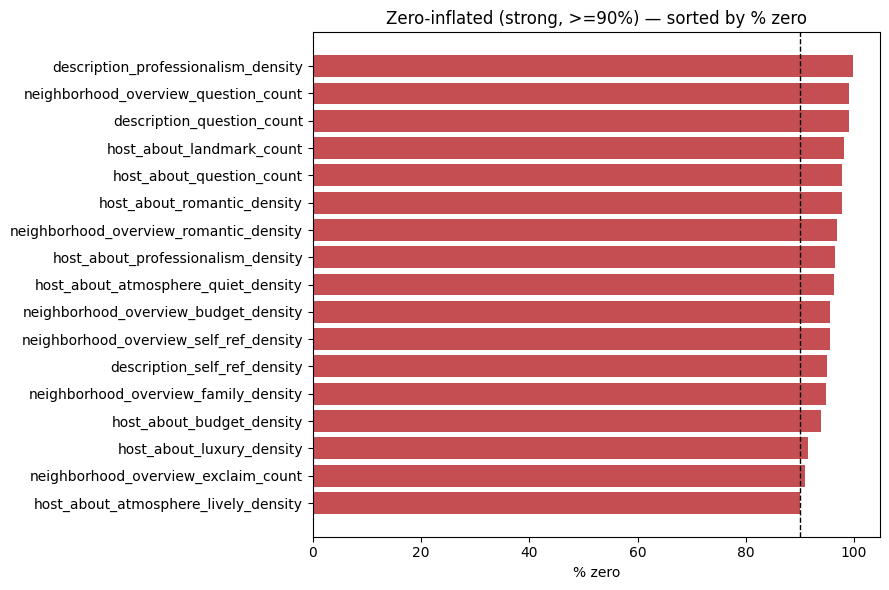

In [119]:
# visual confirmation for the "strong" group
zero_inflated_strong = feature_audit.loc[feature_audit['flag'] == 'zero_inflated (strong)', 'column'].tolist()
zero_inflated_moderate = feature_audit.loc[feature_audit['flag'] == 'zero_inflated (moderate)', 'column'].tolist()

strong_pct = feature_audit.set_index('column').loc[zero_inflated_strong, 'pct_zero'].sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(strong_pct.index, strong_pct.values, color='#c44e52')
ax.set_xlabel('% zero')
ax.set_title('Zero-inflated (strong, >=90%) — sorted by % zero')
ax.axvline(90, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

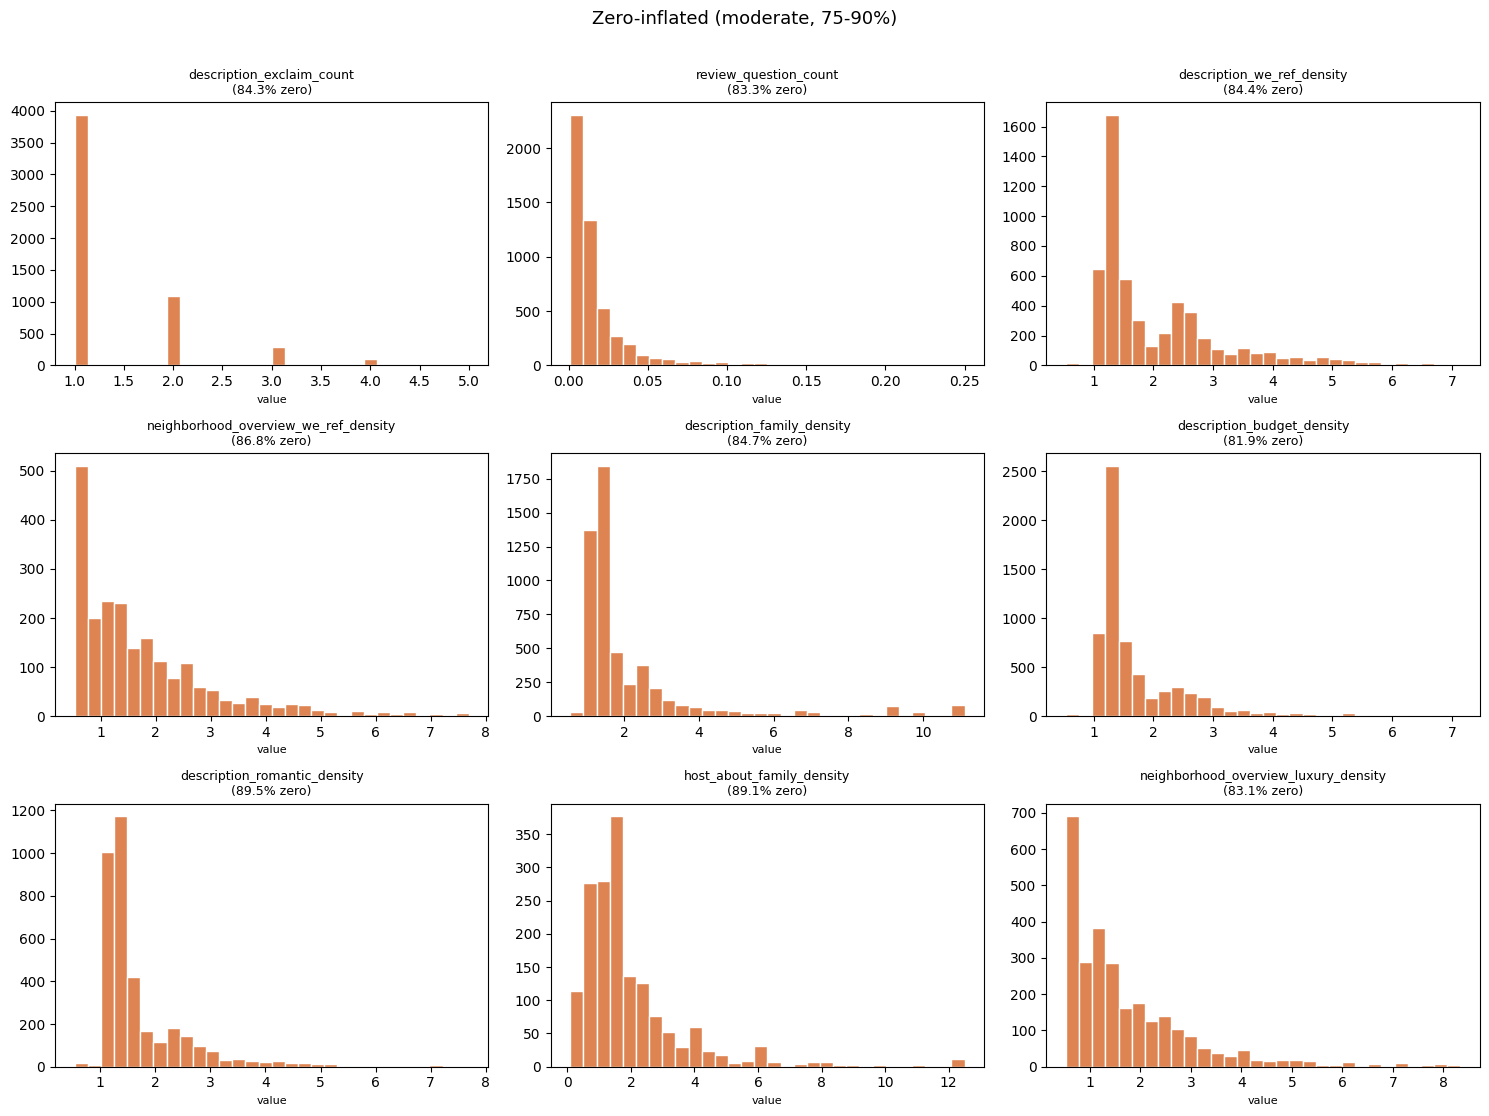

,0.25,0.50,0.75,0.90,0.95,0.99
description_exclaim_count,1.000,1.000,2.000,2.000,3.000,5.000
review_question_count,0.006,0.011,0.021,0.042,0.071,0.250
description_we_ref_density,1.266,1.538,2.564,3.774,4.819,7.143
neighborhood_overview_we_ref_density,0.813,1.370,2.280,3.695,4.762,7.692
description_family_density,1.250,1.408,2.353,4.000,7.143,11.111
description_budget_density,1.250,1.389,1.961,2.778,3.571,7.143
description_romantic_density,1.250,1.370,1.887,2.857,3.846,7.692
host_about_family_density,1.020,1.493,2.381,4.000,5.882,12.500
neighborhood_overview_luxury_density,0.787,1.333,2.326,3.509,4.762,8.391


In [122]:
# visualization of the "moderate" group
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, zero_inflated_moderate):
    data = listings_clean[col].dropna()
    nonzero = data[data > 0]
    upper = nonzero.quantile(0.99) if len(nonzero) else 0
    ax.hist(nonzero[nonzero <= upper], bins=30, color='#dd8452', edgecolor='white')
    ax.set_title(f'{col}\n({feature_audit.set_index("column").loc[col, "pct_zero"]}% zero)', fontsize=9)
    ax.set_xlabel('value', fontsize=8)

plt.suptitle('Zero-inflated (moderate, 75-90%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

quantile_table = pd.DataFrame({
    col: listings_clean.loc[listings_clean[col] > 0, col].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    for col in zero_inflated_moderate
}).T
display(quantile_table.round(3))

Four different treatments are applied, based on what the audit and the visual checks above show:

- **Strong zero-inflation (≥90% zero), 17 columns → binary flag (`has_X`).** At this level there's too little non-zero mass to support a finer split without risking near-empty categories, so presence/absence captures nearly all the separating signal the raw column has to offer.
- **Moderate zero-inflation (75-90% zero) with confirmed non-zero structure, 7 columns → 3-tier bin (`none` / `low` / `high`)**, split at each column's own non-zero median.
- **Small discrete counts, 1 column (`description_exclaim_count`) → `0 / 1 / 2+`.** A raw per-text integer count with almost no range once non-zero (values cluster at 1-3), so a coarse 3-level count bin fits better than either continuous treatment or the median-split scheme.
- **Weak/low-variance, 1 column (`review_question_count`) → left untouched.** Non-zero values are extremely compressed, consistent with question marks being rare across every text source in this corpus. Flagged as a candidate for removal at the full validation stage.

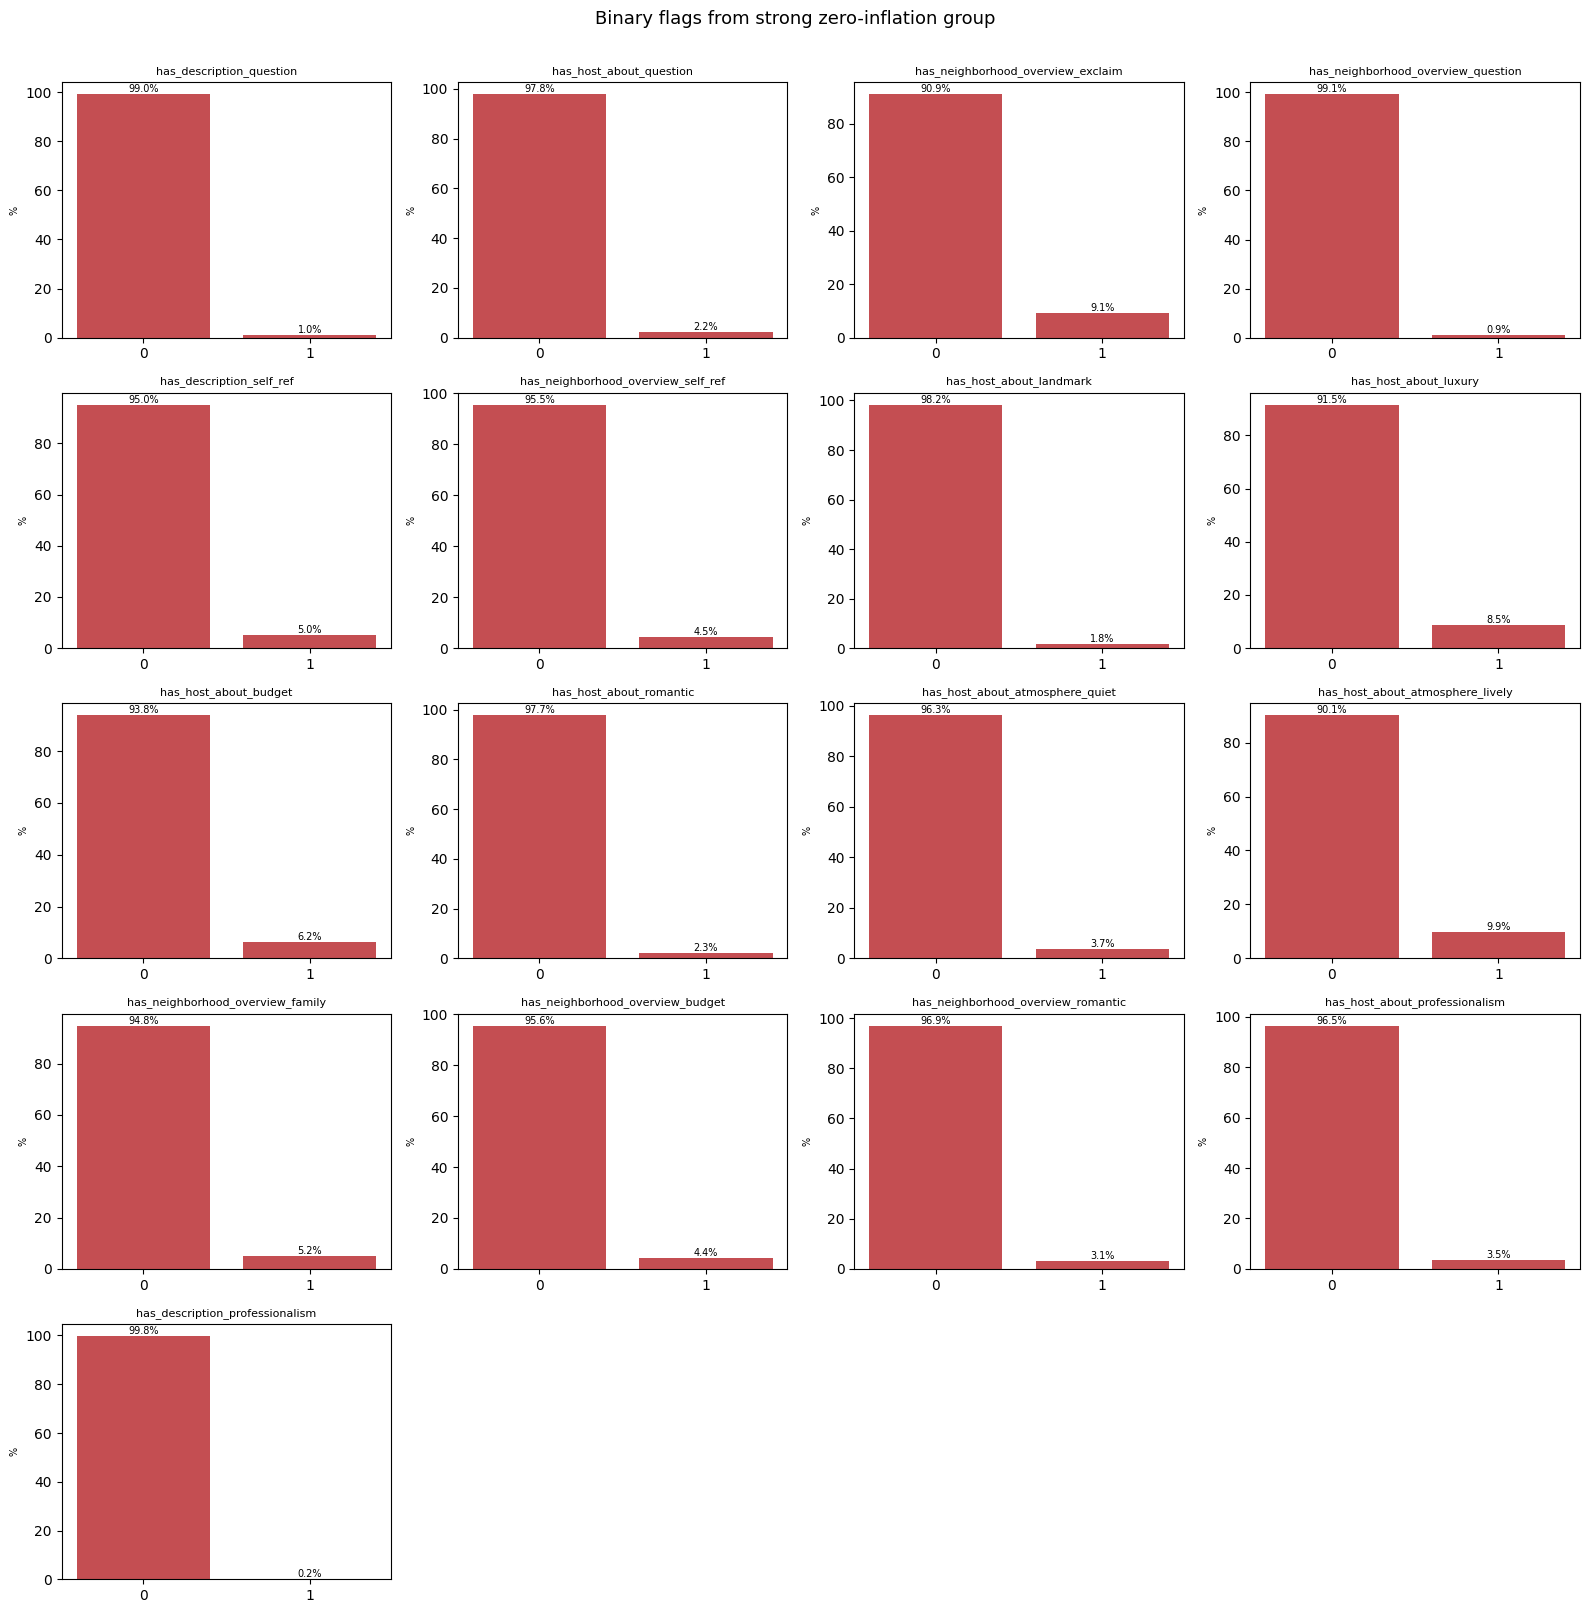

In [130]:
# strong group - binary flags
def to_flag_name(col):
    for suffix in ('_density', '_count'):
        if col.endswith(suffix):
            return f'has_{col[:-len(suffix)]}'
    return f'has_{col}'

for col in zero_inflated_strong:
    flag_name = to_flag_name(col)
    flag_series = (listings_clean[col] > 0).astype('Int64')
    flag_series[listings_clean[col].isna()] = pd.NA  # preserve unavailable
    listings_clean[flag_name] = flag_series

listings_clean = listings_clean.copy()

strong_flag_names = [to_flag_name(c) for c in zero_inflated_strong]

fig, axes = plt.subplots(5, 4, figsize=(16, 16))
axes = axes.flatten()

for ax, flag in zip(axes, strong_flag_names):
    pct = listings_clean[flag].value_counts(normalize=True, dropna=True).reindex([0, 1]).fillna(0).mul(100)
    ax.bar(['0', '1'], pct.values, color='#c44e52')
    ax.set_title(flag, fontsize=8)
    ax.set_ylabel('%', fontsize=7)
    for i, v in enumerate(pct.values):
        ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=7)

for ax in axes[len(strong_flag_names):]:
    ax.set_visible(False)

plt.suptitle('Binary flags from strong zero-inflation group', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

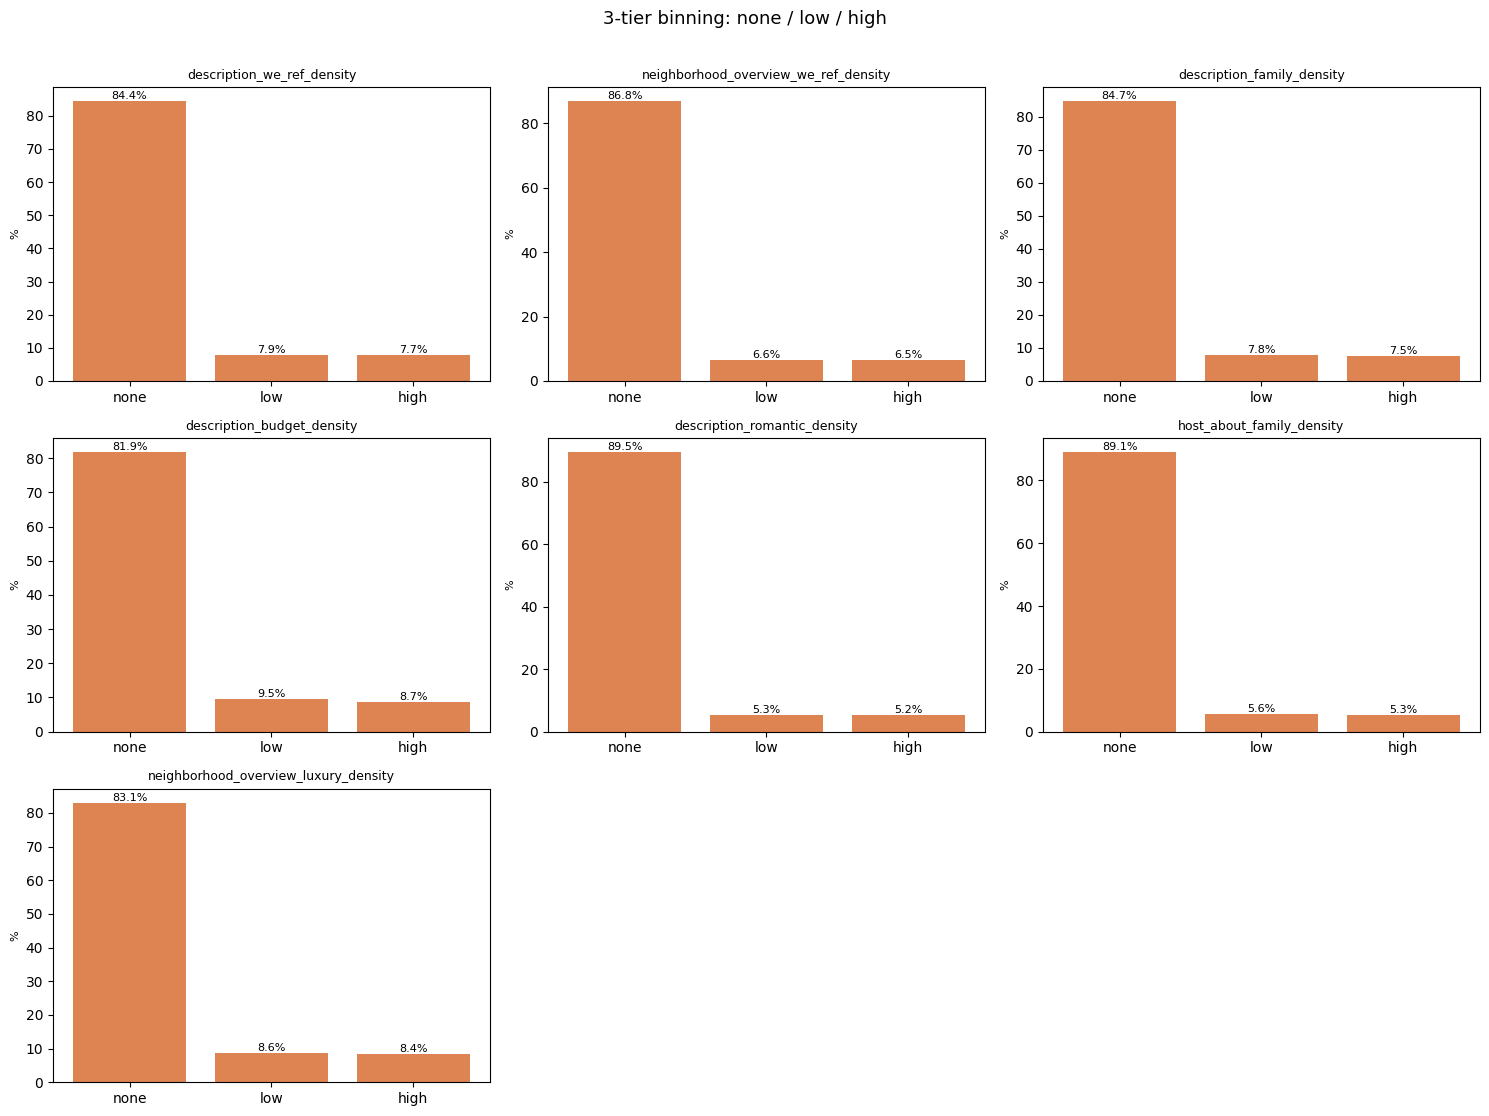

In [131]:
# moderate group - 3-tier binning at each column's own non-zero median
def bin_zero_inflated(series, labels=('none', 'low', 'high')):
    result = pd.Series(index=series.index, dtype='object')
    result[series == 0] = labels[0]
    nonzero = series[series > 0]
    if len(nonzero) > 0:
        median_nonzero = nonzero.median()
        result[(series > 0) & (series <= median_nonzero)] = labels[1]
        result[series > median_nonzero] = labels[2]
    return result

structured_moderate = [c for c in zero_inflated_moderate
                        if c not in ('description_exclaim_count', 'review_question_count')]

for col in structured_moderate:
    listings_clean[f'{col}_binned'] = bin_zero_inflated(listings_clean[col])

listings_clean = listings_clean.copy()

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, structured_moderate):
    pct = listings_clean[f'{col}_binned'].value_counts(normalize=True).reindex(['none', 'low', 'high']).mul(100)
    ax.bar(pct.index, pct.values, color='#dd8452')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('%', fontsize=8)
    for i, v in enumerate(pct.values):
        ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

for ax in axes[len(structured_moderate):]:
    ax.set_visible(False)

plt.suptitle('3-tier binning: none / low / high', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

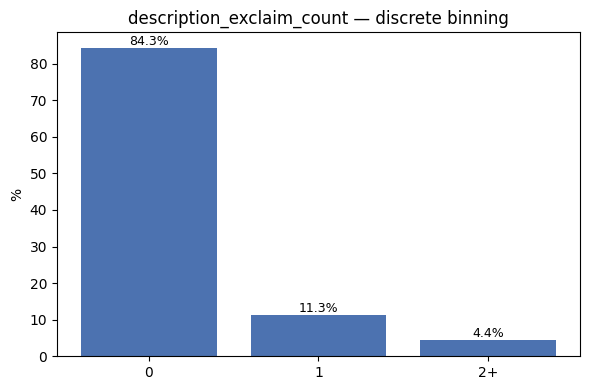

In [132]:
# small discrete count - 0/1/2+
def bin_discrete_count(series):
    return pd.cut(series, bins=[-0.5, 0.5, 1.5, np.inf], labels=['0', '1', '2+'])

listings_clean['description_exclaim_count_binned'] = bin_discrete_count(listings_clean['description_exclaim_count'])
listings_clean = listings_clean.copy()

fig, ax = plt.subplots(figsize=(6, 4))
pct = listings_clean['description_exclaim_count_binned'].value_counts(normalize=True).reindex(['0', '1', '2+']).mul(100)
ax.bar(pct.index, pct.values, color='#4c72b0')
ax.set_title('description_exclaim_count — discrete binning')
ax.set_ylabel('%')
for i, v in enumerate(pct.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Observations:**

None of the three transformations produced well-balanced categories, and this is expected rather than a surprise, as the zero-inflation was the whole reason these columns needed transforming in the first place, so of course a flag or bin built around that zero mass inherits it.

In the strong group, several binary flags end up heavily skewed, with barely more separating power than the raw density they replaced. The 3-tier bins in the moderate group fare a bit better structurally, but "low" and "high" are still each a small fraction next to "none", since the split only happens within the already-thin non-zero mass. `description_exclaim_count`'s discrete `0/1/2+` bin shows the same pattern.

None of this is treated as a reason to drop these features now, as that decision is deferred to the final NLP features validation stage, once redundancy checks and the full feature set are visible. For now, these are logged as low-confidence candidates: technically valid transformations, but with imbalance severe enough that whether they carry real separating signal for clustering remains an open question rather than something this checkpoint can settle.

#### 4.5.3 Skew Handling

In [136]:
STRONG_SKEW_THRESHOLD = 5

skewed_columns_all = feature_audit.loc[feature_audit['flag'] == 'skewed', 'column'].tolist()
skewed_audit = feature_audit.set_index('column').loc[skewed_columns_all, 'skew']

extreme_skew_cols = skewed_audit[skewed_audit.abs() > STRONG_SKEW_THRESHOLD].index.tolist()
moderate_skew_cols = skewed_audit[skewed_audit.abs() <= STRONG_SKEW_THRESHOLD].index.tolist()

print(f"{len(extreme_skew_cols)} strong-skew columns (|skew| > {STRONG_SKEW_THRESHOLD})")
print(f"{len(moderate_skew_cols)} moderate-skew columns (|skew| <= {STRONG_SKEW_THRESHOLD})")

15 strong-skew columns (|skew| > 5)
30 moderate-skew columns (|skew| <= 5)


In [137]:
def skew_before_after(cols):
    """Empirically check log1p's effect on skew, per column.
    Columns with min <= -1 are flagged rather than silently NaN'd out."""
    rows = []
    for col in cols:
        data = listings_clean[col].dropna()
        sk_before = round(scipy_skew(data), 2) if data.nunique() > 1 else 0
        if data.min() <= -1:
            rows.append({'column': col, 'skew_before': sk_before, 'skew_after': np.nan,
                         'improved': None, 'note': 'log1p undefined (min <= -1)'})
            continue
        log_data = np.log1p(data)
        sk_after = round(scipy_skew(log_data), 2) if log_data.nunique() > 1 else 0
        rows.append({
            'column': col, 'skew_before': sk_before, 'skew_after': sk_after,
            'improved': abs(sk_after) < abs(sk_before), 'note': ''
        })
    return pd.DataFrame(rows).set_index('column')

def plot_skew_dumbbell(check_df, title):
    """Dumbbell plot: one line per column connecting its skew before/after log1p,
    sorted by pre-transform severity. Columns with no after-value (log1p undefined) are excluded from the plot but stay in the table."""
    plot_data = check_df.dropna(subset=['skew_after']).sort_values('skew_before', key=abs, ascending=False)
    y_pos = range(len(plot_data))

    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_data) * 0.3)))
    ax.hlines(y=y_pos, xmin=plot_data['skew_before'], xmax=plot_data['skew_after'], color='grey', alpha=0.5)
    ax.scatter(plot_data['skew_before'], y_pos, color='#c44e52', label='before log1p', zorder=3)
    ax.scatter(plot_data['skew_after'], y_pos, color='#4c72b0', label='after log1p', zorder=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data.index, fontsize=8)
    ax.set_xlabel('skew')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

,skew_before,skew_after,improved,note
column,,,,
review_self_ref_density,4.77,0.79,True,
review_atmosphere_lively_density,4.71,1.01,True,
host_about_sentence_count,4.17,0.58,True,
neighborhood_overview_transport_density,3.76,1.31,True,
host_about_authenticity_density,3.66,1.23,True,
description_luxury_density,3.37,1.04,True,
review_exclaim_count,3.31,0.34,True,
host_about_exclaim_count,3.22,1.28,True,
neighborhood_overview_landmark_count,2.90,1.67,True,


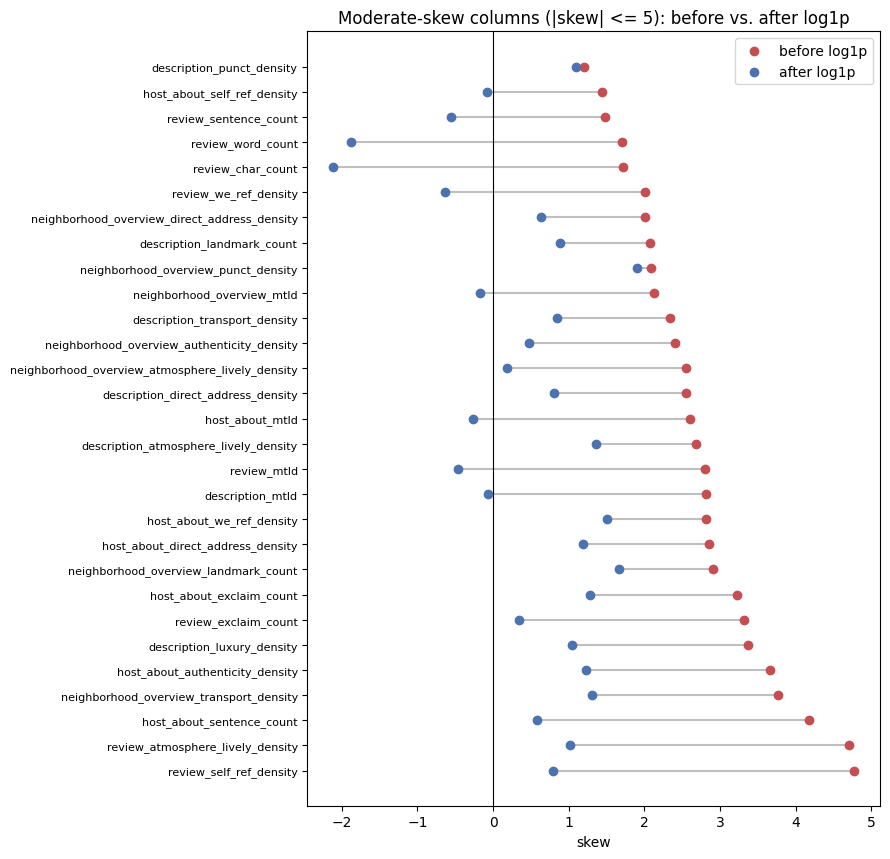

In [138]:
moderate_check = skew_before_after(moderate_skew_cols)
display(moderate_check.sort_values('skew_before', key=abs, ascending=False))
plot_skew_dumbbell(moderate_check, 'Moderate-skew columns (|skew| <= 5): before vs. after log1p')

,skew_before,skew_after,improved,note
column,,,,
review_romantic_density,43.06,7.06,True,
review_atmosphere_quiet_density,15.76,2.07,True,
review_luxury_density,15.62,4.97,True,
review_punct_density,13.00,9.62,True,
review_budget_density,9.51,1.94,True,
review_authenticity_density,8.72,1.54,True,
neighborhood_overview_atmosphere_quiet_density,8.70,1.96,True,
review_family_density,8.59,3.22,True,
review_direct_address_density,8.45,0.99,True,


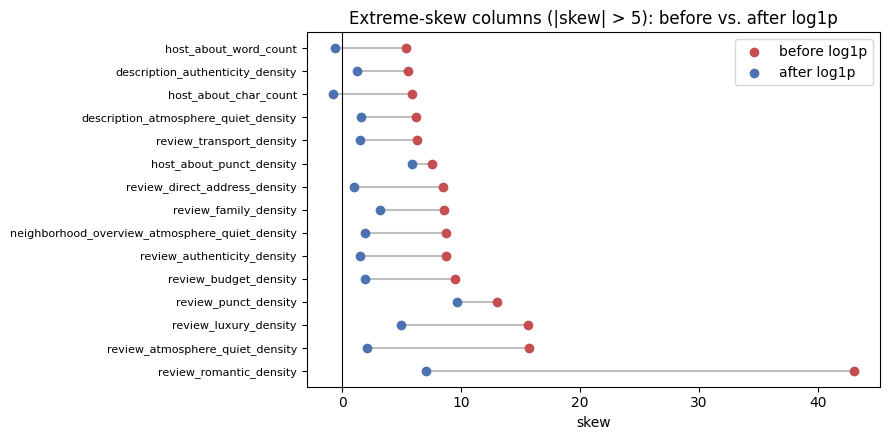

In [139]:
extreme_check = skew_before_after(extreme_skew_cols)
display(extreme_check.sort_values('skew_before', key=abs, ascending=False))
plot_skew_dumbbell(extreme_check, 'Extreme-skew columns (|skew| > 5): before vs. after log1p')

**Observations:**

Across both skew groups, `log1p` was checked empirically, and the outcome differed by group. Every extreme-skew column improved, often dramatically. The moderate group was more mixed: 26 of 30 improved meaningfully, but four were left untransformed:
- `review_readability` because negative values put it outside `log1p`'s valid domain
- `review_word_count`/`review_char_count` because the transform overshot into a worse left skew rather than fixing the right skew
- `neighborhood_overview_punct_density` because the improvement was too small to justify a separate version.

In [140]:
# log-transform
NO_TRANSFORM_MODERATE = [
    'review_readability',                    
    'review_word_count',                     
    'review_char_count',                    
    'neighborhood_overview_punct_density',  
]

log_transform_columns = [c for c in skewed_columns_all if c not in NO_TRANSFORM_MODERATE]

for col in log_transform_columns:
    listings_clean[f'{col}_log'] = np.log1p(listings_clean[col])

listings_clean = listings_clean.copy()

In [143]:
# save the extended datasets
listings_clean.to_csv(BASE_PATH / "data" / "processed" / "listings_extended.csv", index=False)
reviews_clean.to_csv(BASE_PATH / "data" / "processed" / "reviews_extended.csv", index=False)

### 4.6 NLP Feature Engineering Part 1 Conclusion

This section extended `listings_clean` with a broad set of text-derived candidate features, working through five stages:

- **Corpus setup**: review corpus capped at 30 per listing only for future heavier phases. Missingness flags and fastText language detection built the groundwork every later phase depends on for coverage and calibration.

- **Stylometric features**: length/punctuation counts, language-adapted Flesch readability (with a `proxy`/`unavailable` fallback where the formula's assumptions break down), MTLD vocabulary richness (chosen over TTR for its length-independence, empirically confirmed), and pronoun-based personalization densities (self/we/direct-address), each computed per text field (`description`, `host_about`, `neighborhood_overview`) and aggregated to listing level for reviews.

- **Domain lexicons**: a Wikipedia/Wikidata-sourced landmark gazetteer, cross-validated against `distance_to_center_km`. Six corpus-bootstrapped tone lexicons (luxury, family, budget, romantic, authenticity, atmosphere) built via PMI rather than guessed vocabulary. Host professionalism (via differential word frequency between multi- and single-listing hosts) and transport accessibility (hand-written phrases, prevalence-checked before use), both translated to five languages via a structured LLM call rather than by hand.

- **Feature checkpoint**: 87 candidate features registered separately from 33 scaffolding columns (`_method`/`_tags`, never meant as model inputs). An audit flagged over 80% of candidates as zero-inflated or skewed. Zero-inflation was resolved by degree: binary flags for the ≥90% zero group, 3-tier bins at each column's own non-zero median for the 75-90% group with confirmed non-zero structure, discrete `0/1/2+` binning for small integer counts, one column left untouched as too weak to transform. Skew was resolved via empirically checked `log1p`, applied to 41 of 45 flagged columns; four were excluded for stated, column-specific reasons (undefined domain, transform overshoot, negligible improvement) rather than a blanket rule.

Original, binned, and log-transformed versions of most features are all kept side by side, and no redundancy is resolved here, by design, as final keep/transform decisions, redundancy checks against tabular features and against each other, and the price-leak diagnostic are deferred to the full validation pass at the end of the next notebook, once sentiment, topic, and embedding features exist and the complete NLP feature set is visible at once.

## 5. Summary

This notebook built `listings_clean` into a candidate feature set for market segmentation clustering, in two parts:

- **Tabular feature engineering**: `property_type` reduced to 6 macro-groups; `distance_to_center_km`/`geo_sector` added as a continuous geographic signal; the review-score block collapsed into `review_quality_pc1` via PCA, the host-listings-count trio resolved by keeping `calculated_host_listings_count`. Domain-driven space-efficiency ratios, a booking-policy flag, availability ratios, and `review_engagement_score` added. Seven skewed variables log-transformed.

- **NLP feature engineering (Section 4)**: stylometric signals (length, readability, MTLD, personalization) computed across `description`, `host_about`, `neighborhood_overview`, and `review`. Nine domain lexicons built (a Wikipedia/Wikidata-sourced landmark gazetteer, six PMI-bootstrapped tone lexicons, host professionalism, and transport accessibility) largely without hand-picked vocabulary, translated to five languages via LLM. 87 candidate features registered, audited for zero-inflation and skew, and resolved via binary flags, tiered binning, and empirically checked log-transforms.

The resulting `listings_extended.csv`/`reviews_extended.csv` carry raw, binned, and log-transformed versions of most features side by side. Redundancy and final selection are left for final validation.